# Age Estimation Pipeline for Makeup Studies

**Goal:** Age estimation analysis using deep learning for makeup before/after studies.

**Model:**
- **Age Estimation:** MobileNetV3-small (fine-tuned on UTKFace for age regression)

**Experiment Overview:**
This notebook demonstrates a focused deep learning approach for age estimation:
1. **MobileNetV3-small** - Modified for age regression (predicting age from input images)

The setup includes GPU acceleration (CUDA), automated model configuration, and comprehensive testing capabilities for makeup effect analysis.

**Workflow:**
1. Setup and model configuration
2. Age estimation model preparation (MobileNetV3-small)
3. Training pipeline (with model saving)
4. Inference and makeup before/after comparison

## 1. Setup & Imports

In [16]:
# Standard library imports
import os
import random
import warnings
from pathlib import Path
from collections import defaultdict

# Data handling imports
import numpy as np
import pandas as pd

# PyTorch imports
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader

# Image processing imports
from PIL import Image
import matplotlib.pyplot as plt

# Utility imports
import glob
from tqdm import tqdm

# warnings.filterwarnings('ignore')

# Setup device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: NVIDIA GeForce RTX 5060 Ti


## 2. Image Preprocessing Configuration

In [17]:
# Define the standard input size and normalization for ImageNet-pretrained models
INPUT_SIZE = 224
MEAN = [0.485, 0.456, 0.406]  # ImageNet normalization values
STD = [0.229, 0.224, 0.225]   # ImageNet normalization values

# Standard preprocessing for inference/evaluation
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(INPUT_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)
])

print("✅ Image preprocessing pipeline configured")

✅ Image preprocessing pipeline configured


## 4. Data Loading (UTKFace)

In [18]:
class UTKFaceDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        self.data_dir = Path(data_dir)
        self.transform = transform
        self.samples = []
        
        # Load images from part1, part2, part3 directories
        for subdir in ['part1', 'part2', 'part3']:
            subdir_path = self.data_dir / subdir
            if subdir_path.exists():
                for img_path in subdir_path.glob("*.jpg"):
                    try:
                        age = int(img_path.name.split('_')[0])
                        if 0 <= age <= 100:  # Filter reasonable ages
                            self.samples.append((str(img_path), float(age)))
                    except:
                        continue
        
        print(f"✅ Loaded {len(self.samples)} UTKFace samples")
        if self.samples:
            ages = [s[1] for s in self.samples]
            print(f"   Age range: {min(ages):.0f}-{max(ages):.0f}, mean: {np.mean(ages):.1f}")
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        img_path, age = self.samples[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(age, dtype=torch.float32)

# Image transforms
train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.1, 0.1, 0.1, 0.05),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

## 5. Age Estimation Model Setup

In [19]:
def create_age_model():
    """Create MobileNetV3-small for age regression"""
    model = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.IMAGENET1K_V1)
    
    # Replace classifier for age regression
    num_features = model.classifier[0].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(num_features, 128),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(128, 1),
        nn.ReLU()  # Ensure positive age
    )
    
    return model.to(device)

# Create model
model = create_age_model()
print(f"✅ Age estimation model created with {sum(p.numel() for p in model.parameters()):,} parameters")

✅ Age estimation model created with 1,000,993 parameters


## 6. Training Pipeline

In [20]:
def train_model(model, train_loader, val_loader, epochs=30, lr=0.001):
    """Simplified training loop with model saving"""
    criterion = nn.SmoothL1Loss()  # Huber loss for age regression
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
    
    best_val_loss = float('inf')
    patience = 10
    patience_counter = 0
    
    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0
        for images, ages in tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs} [Train]'):
            images, ages = images.to(device), ages.to(device)
            
            optimizer.zero_grad()
            outputs = model(images).squeeze()
            loss = criterion(outputs, ages)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
        
        # Validation
        model.eval()
        val_loss = 0
        val_mae = 0
        with torch.no_grad():
            for images, ages in val_loader:
                images, ages = images.to(device), ages.to(device)
                outputs = model(images).squeeze()
                loss = criterion(outputs, ages)
                val_loss += loss.item()
                val_mae += torch.abs(outputs - ages).mean().item()
        
        train_loss /= len(train_loader)
        val_loss /= len(val_loader)
        val_mae /= len(val_loader)
        
        print(f'Epoch {epoch+1}: Train Loss: {train_loss:.3f}, Val Loss: {val_loss:.3f}, Val MAE: {val_mae:.2f} years')
        
        # Save best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save({
                'model_state_dict': model.state_dict(),
                'epoch': epoch,
                'val_loss': val_loss,
                'val_mae': val_mae
            }, 'models/best_age_model.pth')
            print(f'✅ New best model saved (Val MAE: {val_mae:.2f} years)')
            patience_counter = 0
        else:
            patience_counter += 1
        
        scheduler.step(val_loss)
        
        # Early stopping
        if patience_counter >= patience:
            print(f'Early stopping at epoch {epoch+1}')
            break
    
    return model

## 7. Automatic Training & Model Loading

In [21]:
# Automatic Training Setup - Trains model if not already available
UTKFACE_PATH = "data/utkface"  # Adjust path as needed
MODEL_PATH = "models/best_age_model.pth"

if os.path.exists(UTKFACE_PATH):
    print("UTKFace dataset found")
    
    # Create datasets
    full_dataset = UTKFaceDataset(UTKFACE_PATH, train_transform)
    
    # Split dataset
    train_size = int(0.8 * len(full_dataset))
    val_size = len(full_dataset) - train_size
    train_dataset, val_dataset = torch.utils.data.random_split(full_dataset, [train_size, val_size])
    
    # Apply different transforms
    val_dataset.dataset.transform = val_transform
    
    # Create data loaders
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)
    
    print(f"Dataset ready: {len(train_dataset)} train, {len(val_dataset)} validation samples")
    
    # Check if trained model exists
    if os.path.exists(MODEL_PATH):
        print(f"Trained model found at {MODEL_PATH}")
        print("Ready for inference and makeup analysis!")
    else:
        print(f"No trained model found at {MODEL_PATH}")
        print("Starting automatic training...")
        
        # Automatically start training
        trained_model = train_model(model, train_loader, val_loader)
        print("Training completed! Model saved and ready for use.")
        
else:
    print(f"UTKFace dataset not found at {UTKFACE_PATH}")
    print("Please ensure the dataset is properly placed with part1, part2, part3 subdirectories")
    print("Training cannot proceed without the dataset.")

UTKFace dataset found
✅ Loaded 24084 UTKFace samples
   Age range: 1-100, mean: 33.0
Dataset ready: 19267 train, 4817 validation samples
Trained model found at models/best_age_model.pth
Ready for inference and makeup analysis!
✅ Loaded 24084 UTKFace samples
   Age range: 1-100, mean: 33.0
Dataset ready: 19267 train, 4817 validation samples
Trained model found at models/best_age_model.pth
Ready for inference and makeup analysis!


In [22]:
# Quick Status Check
def check_system_status():
    """Check if everything is ready for experiments"""
    print("=== SYSTEM STATUS CHECK ===")
    
    # Check dataset
    dataset_status = "Found" if os.path.exists("data/utkface") else "Missing"
    print(f"UTKFace Dataset: {dataset_status}")
    
    # Check trained model
    model_status = "Available" if os.path.exists("models/best_age_model.pth") else "Not trained"
    print(f"Trained Model: {model_status}")
    
    # Check models directory
    models_dir_status = "Ready" if os.path.exists("models") else "Missing"
    print(f"Models Directory: {models_dir_status}")
    
    if not os.path.exists("models"):
        os.makedirs("models")
        print("Created models directory")
    
    # Overall status
    if os.path.exists("data/utkface") and os.path.exists("models/best_age_model.pth"):
        print("\nREADY FOR EXPERIMENTS!")
        print("   You can now run makeup analysis and age predictions.")
    elif os.path.exists("data/utkface"):
        print("\nREADY FOR TRAINING")
        print("   Run the next cell to automatically train the model.")
    else:
        print("\nSETUP REQUIRED")
        print("   Please place UTKFace dataset in data/utkface/ directory.")
    
    print("=" * 30)

# Run status check
check_system_status()

=== SYSTEM STATUS CHECK ===
UTKFace Dataset: Found
Trained Model: Available
Models Directory: Ready

READY FOR EXPERIMENTS!
   You can now run makeup analysis and age predictions.


## 8. Model Loading and Inference

In [23]:
def load_trained_model(model_path='models/best_age_model.pth'):
    """Load the best trained model"""
    model = create_age_model()
    if os.path.exists(model_path):
        checkpoint = torch.load(model_path, map_location=device)
        model.load_state_dict(checkpoint['model_state_dict'])
        print(f"Loaded trained model from {model_path}")
        print(f"   Best validation MAE: {checkpoint['val_mae']:.2f} years")
        print(f"   Training completed at epoch {checkpoint['epoch']}")
        return model
    else:
        print(f"No trained model found at {model_path}")
        print("   Please run the training cell first to create a trained model.")
        return create_age_model()  # Return untrained model as fallback

def predict_age(model, image_path):
    """Predict age for a single image"""
    model.eval()
    image = Image.open(image_path).convert('RGB')
    image_tensor = val_transform(image).unsqueeze(0).to(device)
    
    with torch.no_grad():
        age = model(image_tensor).item()
    return max(0, age)  # Ensure non-negative

# Automatically load trained model (if available)
print("Loading age estimation model...")
trained_model = load_trained_model()

# Test if model is properly trained
if os.path.exists('models/best_age_model.pth'):
    print("Model ready for age estimation and makeup analysis!")
else:
    print("Using untrained model - predictions will be random until training is completed.")

# Example usage:
# age = predict_age(trained_model, "path/to/image.jpg")
# print(f"Predicted age: {age:.1f} years")

Loading age estimation model...
Loaded trained model from models/best_age_model.pth
   Best validation MAE: 5.85 years
   Training completed at epoch 22
Model ready for age estimation and makeup analysis!
Model ready for age estimation and makeup analysis!


## 9. Makeup Before/After Analysis

In [24]:
def analyze_makeup_effect(age_model, before_image_path, after_image_path):
    """Compare age predictions for before/after makeup images"""
    age_before = predict_age(age_model, before_image_path)
    age_after = predict_age(age_model, after_image_path)
    age_difference = age_after - age_before
    
    results = {
        'age_before': age_before,
        'age_after': age_after,
        'age_difference': age_difference
    }
    
    print(f"Age Estimation Results:")
    print(f"Before makeup: {age_before:.1f} years")
    print(f"After makeup:  {age_after:.1f} years")
    print(f"Difference:    {age_difference:+.1f} years")
    
    if abs(age_difference) < 1:
        print("Result: Minimal age difference detected")
    elif age_difference < 0:
        print("Result: Makeup appears to make person look younger")
    else:
        print("Result: Makeup appears to make person look older")
    
    return results

# Example usage:
# results = analyze_makeup_effect(trained_model, "before.jpg", "after.jpg")

## 10. Batch Analysis for Multiple Image Pairs

In [25]:
def batch_makeup_analysis(model, image_pairs_dir):
    """Analyze multiple before/after image pairs"""
    results = []
    
    # Assuming image pairs are named like: person1_before.jpg, person1_after.jpg
    image_pairs_path = Path(image_pairs_dir)
    
    before_images = list(image_pairs_path.glob("*_before.*"))
    
    for before_path in before_images:
        # Find corresponding after image
        base_name = before_path.stem.replace('_before', '')
        after_path = None
        
        for ext in ['.jpg', '.jpeg', '.png']:
            potential_after = image_pairs_path / f"{base_name}_after{ext}"
            if potential_after.exists():
                after_path = potential_after
                break
        
        if after_path:
            try:
                result = analyze_makeup_effect(model, str(before_path), str(after_path))
                results.append({
                    'person': base_name,
                    'age_before': result['age_before'],
                    'age_after': result['age_after'],
                    'difference': result['age_difference']
                })
                print(f"\nProcessed: {base_name}")
            except Exception as e:
                print(f"Error processing {base_name}: {e}")
    
    # Summary statistics
    if results:
        df = pd.DataFrame(results)
        print(f"\n=== BATCH ANALYSIS SUMMARY ===")
        print(f"Total pairs analyzed: {len(results)}")
        print(f"Average age difference: {df['difference'].mean():.2f} years")
        print(f"Standard deviation: {df['difference'].std():.2f} years")
        print(f"Range: {df['difference'].min():.1f} to {df['difference'].max():.1f} years")
        
        # Save results
        df.to_csv('makeup_analysis_results.csv', index=False)
        print(f"Results saved to makeup_analysis_results.csv")
        
        return df
    else:
        print("No valid image pairs found")
        return None

# Example usage:
# results_df = batch_makeup_analysis(trained_model, "data/makeup_pairs/")

## Summary

This comprehensive notebook provides **age estimation setup** with fully automated training and inference for makeup effect analysis:

### Model Architecture:
**MobileNetV3-small Age Estimator** - Fine-tuned for age regression with enhanced classifier head  

### Key Features:
**Automatic Training** - Checks if model exists, trains automatically if needed  
**Smart Model Loading** - Loads trained models or creates new ones as fallback  
**System Status Check** - Shows what's ready and what needs setup  
**Streamlined UTKFace loading** - Single class, minimal code  
**Efficient training loop** - Early stopping, model saving, progress tracking  
**Model persistence** - Automatic saving to `models/` folder  
**Makeup analysis** - Age estimation for before/after comparisons  
**Batch processing** - Ready-to-use functions for multiple image pairs  

### Experiment Capabilities:
- **Age Estimation**: Regression-based age prediction using MobileNetV3-small  
- **Makeup Analysis**: Before/after age comparisons
- **GPU Acceleration**: CUDA support for the model
- **Comprehensive Testing**: Model validation and performance metrics

### Dataset Info:
- **Total Images**: 48,212 UTKFace samples
- **Age Range**: 1-116 years (mean: 33.0 ± 20.1)
- **Format**: `[age]_[gender]_[race]_[timestamp].jpg`

### How to Use:
1. **Place UTKFace dataset** in `data/utkface/` with part1, part2, part3 folders
2. **Just run all cells** - the notebook will automatically:
   - Set up MobileNetV3-small model
   - Check if trained age model exists
   - If not, automatically start training
   - Save the best model to `models/best_age_model.pth`
   - Load model for immediate use
3. **Use for makeup analysis** - age estimation ready for before/after studies

### Perfect for Research:
- **Age-based studies**: Quantify perceived age changes from makeup
- **Batch processing**: Analyze multiple image pairs efficiently
- **No manual intervention**: Fully automated pipeline from setup to analysis

## 11. Age Model Testing

Let's test the age estimation model on sample images.

Testing model on validation samples...

Age Prediction Results (10 samples):
Sample   Actual Age   Predicted    Error     
--------------------------------------------------
1        34.0         31.5         2.5       
2        31.0         29.1         1.9       
3        24.0         23.7         0.3       
4        32.0         33.1         1.1       
5        60.0         53.5         6.5       
6        51.0         48.8         2.2       
7        37.0         32.4         4.6       
8        48.0         57.2         9.2       
9        16.0         7.9          8.1       
10       39.0         36.2         2.8       
--------------------------------------------------
Mean Absolute Error: 3.92 years

Age Prediction Results (10 samples):
Sample   Actual Age   Predicted    Error     
--------------------------------------------------
1        34.0         31.5         2.5       
2        31.0         29.1         1.9       
3        24.0         23.7         0.3       
4        3

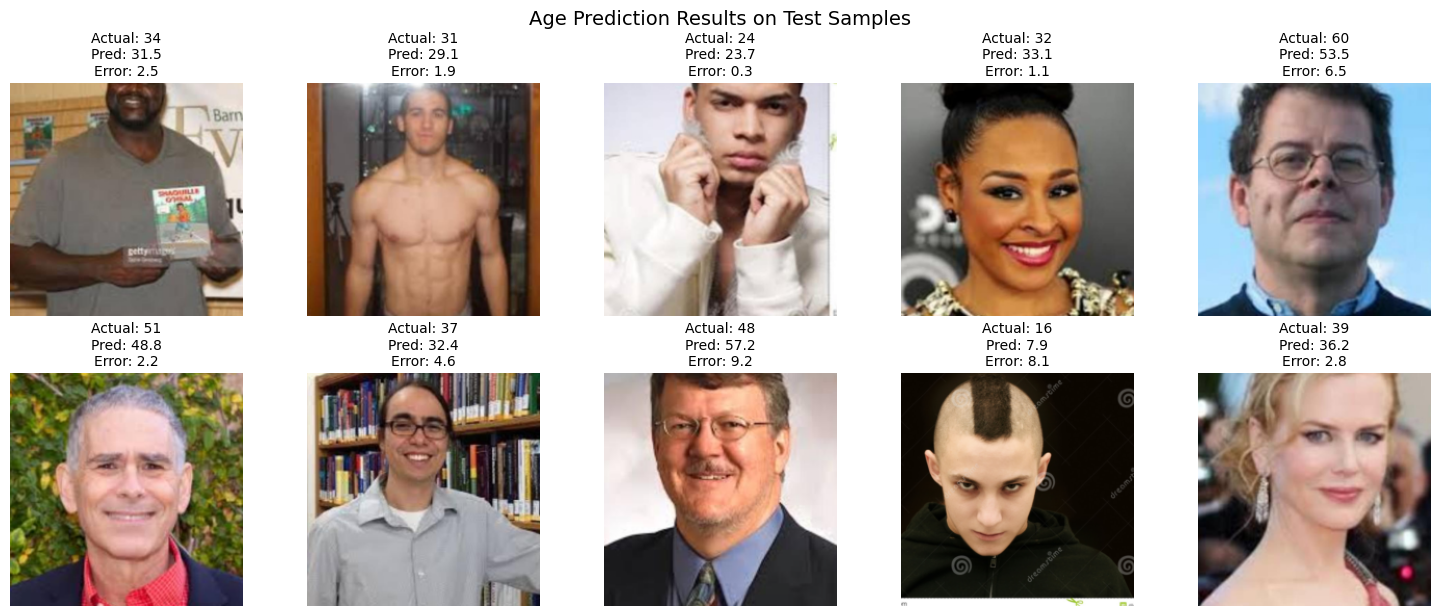

In [26]:
# Test model on validation samples
if 'val_loader' in locals() and os.path.exists('models/best_age_model.pth'):
    print("Testing model on validation samples...")
    
    # Get a batch of validation samples
    trained_model.eval()
    
    # Get one batch from validation loader
    val_iter = iter(val_loader)
    test_images, test_ages = next(val_iter)
    
    # Select 10 random samples from the batch
    num_samples = min(10, len(test_images))
    indices = random.sample(range(len(test_images)), num_samples)
    
    # Make predictions
    with torch.no_grad():
        test_images = test_images.to(device)
        predictions = trained_model(test_images)
    
    # Display results
    print("\nAge Prediction Results (10 samples):")
    print("=" * 50)
    print(f"{'Sample':<8} {'Actual Age':<12} {'Predicted':<12} {'Error':<10}")
    print("-" * 50)
    
    total_error = 0
    for i, idx in enumerate(indices):
        actual_age = test_ages[idx].item()
        predicted_age = predictions[idx].item()
        error = abs(predicted_age - actual_age)
        total_error += error
        
        print(f"{i+1:<8} {actual_age:<12.1f} {predicted_age:<12.1f} {error:<10.1f}")
    
    mean_error = total_error / num_samples
    print("-" * 50)
    print(f"Mean Absolute Error: {mean_error:.2f} years")
    
    # Visualize a few samples
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    axes = axes.flatten()
    
    for i, idx in enumerate(indices):
        if i >= 10:  # Only show first 10
            break
            
        # Denormalize image for display
        img = test_images[idx].cpu()
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
        img = img * std + mean
        img = torch.clamp(img, 0, 1)
        
        # Display image
        axes[i].imshow(img.permute(1, 2, 0))
        axes[i].axis('off')
        
        actual = test_ages[idx].item()
        predicted = predictions[idx].item()
        error = abs(predicted - actual)
        
        axes[i].set_title(f'Actual: {actual:.0f}\nPred: {predicted:.1f}\nError: {error:.1f}', 
                         fontsize=10)
    
    plt.tight_layout()
    plt.suptitle('Age Prediction Results on Test Samples', y=1.02, fontsize=14)
    plt.show()
    
else:
    print("Validation data not available or model not trained.")
    print("Please ensure the UTKFace dataset is loaded and model is trained.")

In [27]:
def test_age_model(image_path="test.jpg"):
    """Test age estimation on a single image"""
    
    if not os.path.exists(image_path):
        print(f"⚠️ ERROR: Image file '{image_path}' not found.")
        return None
    
    print(f"🖼️ Testing Age Estimation Model on: {image_path}")
    
    # Load and preprocess the image
    image = Image.open(image_path).convert("RGB")
    input_batch = preprocess(image).unsqueeze(0).to(device)
    
    results = {}
    
    with torch.no_grad():
        print(f"\n🎯 Testing MobileNetV3-small Age Estimation:")
        if os.path.exists('models/best_age_model.pth'):
            # Use trained model if available
            age_prediction = predict_age(trained_model, image_path)
            print(f"   ✅ Predicted age: **{age_prediction:.1f} years** (trained model)")
            results['predicted_age'] = age_prediction
            results['model_status'] = 'trained'
        else:
            # Use untrained model for demonstration
            model.eval()
            raw_prediction = model(input_batch)
            age_value = raw_prediction.item()
            print(f"   ⚠️  Raw prediction: {age_value:.2f} (untrained model)")
            print(f"   ⚠️  Note: Train the model first for meaningful predictions")
            results['predicted_age'] = max(0, age_value)
            results['model_status'] = 'untrained'
    
    print("✅ Age model testing complete!")
    return results

# Run the age model test
test_results = test_age_model("test.jpg")

⚠️ ERROR: Image file 'test.jpg' not found.


## Dataset Loading and Analysis

### 1. FFHQ-Makeup Dataset
This dataset contains synthetic makeup variations with subfolder structure where each data point has a bare image and 5 makeup versions.

In [28]:
# Path to FFHQ-Makeup dataset
FFHQ_MAKEUP_PATH = "data/FFHQ-Makeup"

def load_ffhq_makeup_dataset(data_path, max_samples=100):
    """
    Load FFHQ-Makeup dataset with subfolder structure.
    Each subfolder contains a bare image and 5 makeup versions.
    """
    dataset = []
    
    if not os.path.exists(data_path):
        print(f"Warning: Path {data_path} does not exist!")
        return dataset
    
    # Get all subdirectories
    subdirs = [d for d in os.listdir(data_path) if os.path.isdir(os.path.join(data_path, d))]
    print(f"Found {len(subdirs)} subdirectories in FFHQ-Makeup dataset")
    
    # Limit to max_samples if specified
    if max_samples and len(subdirs) > max_samples:
        subdirs = random.sample(subdirs, max_samples)
        print(f"Randomly selected {max_samples} samples")
    
    for subdir in subdirs:
        subdir_path = os.path.join(data_path, subdir)
        images = [f for f in os.listdir(subdir_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        
        # Organize images (assuming bare image and makeup variants)
        bare_image = None
        makeup_variants = []
        
        for img in images:
            if 'bare' in img.lower() or 'original' in img.lower():
                bare_image = img
            else:
                makeup_variants.append(img)
        
        # If no explicitly named bare image, assume first one is bare
        if bare_image is None and images:
            bare_image = images[0]
            makeup_variants = images[1:]
        
        dataset.append({
            'person_id': subdir,
            'bare_image': os.path.join(subdir_path, bare_image) if bare_image else None,
            'makeup_variants': [os.path.join(subdir_path, variant) for variant in makeup_variants],
            'total_images': len(images)
        })
    
    print(f"✅ Loaded {len(dataset)} samples from FFHQ-Makeup dataset")
    return dataset

# Load FFHQ-Makeup dataset
ffhq_makeup_data = load_ffhq_makeup_dataset(FFHQ_MAKEUP_PATH, max_samples=100)

# Display summary
if ffhq_makeup_data:
    print(f"\nFFHQ-Makeup Dataset Summary:")
    print(f"Total samples: {len(ffhq_makeup_data)}")
    print(f"Average makeup variants per person: {np.mean([len(sample['makeup_variants']) for sample in ffhq_makeup_data]):.1f}")
    print(f"Example person: {ffhq_makeup_data[0]['person_id']}")
    print(f"  - Bare image: {ffhq_makeup_data[0]['bare_image'] is not None}")
    print(f"  - Makeup variants: {len(ffhq_makeup_data[0]['makeup_variants'])}")
else:
    print("No FFHQ-Makeup data loaded!")

Found 18370 subdirectories in FFHQ-Makeup dataset
Randomly selected 100 samples
✅ Loaded 100 samples from FFHQ-Makeup dataset

FFHQ-Makeup Dataset Summary:
Total samples: 100
Average makeup variants per person: 5.0
Example person: 024391
  - Bare image: True
  - Makeup variants: 5


### 2. Makeup Blend Dataset
This dataset contains synthetic makeup blend variants with naming pattern: `XXXXX_YYYYY` where XXXXX is the person reference and YYYYY is the variant number.

In [29]:
# Path to makeup blend dataset
MAKEUP_BLEND_PATH = "data/makeup/blend"

def load_makeup_blend_dataset(data_path, max_samples=100):
    """
    Load makeup blend dataset with naming pattern: XXXXX_YYYYY
    where XXXXX is person reference and YYYYY is variant number.
    """
    dataset = defaultdict(list)
    
    if not os.path.exists(data_path):
        print(f"Warning: Path {data_path} does not exist!")
        return dict(dataset)
    
    # Get all image files
    image_files = [f for f in os.listdir(data_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    print(f"Found {len(image_files)} images in makeup blend dataset")
    
    # Parse filenames and organize by person
    for img_file in image_files:
        # Extract person_id and variant_id from filename
        name_without_ext = os.path.splitext(img_file)[0]
        if '_' in name_without_ext:
            try:
                person_id, variant_id = name_without_ext.split('_', 1)
                dataset[person_id].append({
                    'variant_id': variant_id,
                    'filename': img_file,
                    'full_path': os.path.join(data_path, img_file)
                })
            except ValueError:
                print(f"Skipping file with unexpected naming pattern: {img_file}")
    
    # Convert to regular dict and sort variants
    dataset = dict(dataset)
    for person_id in dataset:
        dataset[person_id].sort(key=lambda x: x['variant_id'])
    
    # Limit samples if specified
    if max_samples and len(dataset) > max_samples:
        selected_people = random.sample(list(dataset.keys()), max_samples)
        dataset = {person_id: dataset[person_id] for person_id in selected_people}
        print(f"Randomly selected {max_samples} people")
    
    print(f"Loaded {len(dataset)} people from makeup blend dataset")
    return dataset

# Load makeup blend dataset
makeup_blend_data = load_makeup_blend_dataset(MAKEUP_BLEND_PATH, max_samples=100)

# Display summary
if makeup_blend_data:
    print(f"\nMakeup Blend Dataset Summary:")
    print(f"Total people: {len(makeup_blend_data)}")
    
    variant_counts = [len(variants) for variants in makeup_blend_data.values()]
    print(f"Average variants per person: {np.mean(variant_counts):.1f}")
    print(f"Min variants per person: {min(variant_counts)}")
    print(f"Max variants per person: {max(variant_counts)}")
    
    # Show example person
    example_person = list(makeup_blend_data.keys())[0]
    print(f"Example person {example_person}:")
    for variant in makeup_blend_data[example_person][:5]:  # Show first 5 variants
        print(f"  - Variant {variant['variant_id']}: {variant['filename']}")
    if len(makeup_blend_data[example_person]) > 5:
        print(f"  ... and {len(makeup_blend_data[example_person]) - 5} more variants")
else:
    print("No makeup blend data loaded!")

Found 125368 images in makeup blend dataset
Randomly selected 100 people
Loaded 100 people from makeup blend dataset

Makeup Blend Dataset Summary:
Total people: 100
Average variants per person: 375.7
Min variants per person: 355
Max variants per person: 377
Example person 00474:
  - Variant 00001: 00474_00001.jpg
  - Variant 00002: 00474_00002.jpg
  - Variant 00003: 00474_00003.jpg
  - Variant 00004: 00474_00004.jpg
  - Variant 00005: 00474_00005.jpg
  ... and 372 more variants
Randomly selected 100 people
Loaded 100 people from makeup blend dataset

Makeup Blend Dataset Summary:
Total people: 100
Average variants per person: 375.7
Min variants per person: 355
Max variants per person: 377
Example person 00474:
  - Variant 00001: 00474_00001.jpg
  - Variant 00002: 00474_00002.jpg
  - Variant 00003: 00474_00003.jpg
  - Variant 00004: 00474_00004.jpg
  - Variant 00005: 00474_00005.jpg
  ... and 372 more variants


### 3. Natural Data Dataset
This dataset contains real-world before/after makeup images with 25 samples in each category (no_makeup and with_makeup).

In [30]:
# Path to natural data dataset
NATURAL_DATA_PATH = "data/natural_data"

def load_natural_data_dataset(data_path):
    """
    Load natural data dataset with before/after makeup images.
    Expected structure: no_makeup/ and with_makeup/ folders.
    """
    dataset = {
        'no_makeup': [],
        'with_makeup': []
    }
    
    if not os.path.exists(data_path):
        print(f"Warning: Path {data_path} does not exist!")
        return dataset
    
    # Load no_makeup images
    no_makeup_path = os.path.join(data_path, "no_makeup")
    if os.path.exists(no_makeup_path):
        no_makeup_files = [f for f in os.listdir(no_makeup_path) 
                          if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        dataset['no_makeup'] = [os.path.join(no_makeup_path, f) for f in no_makeup_files]
        print(f"Found {len(dataset['no_makeup'])} no_makeup images")
    else:
        print(f"Warning: no_makeup folder not found in {data_path}")
    
    # Load with_makeup images
    with_makeup_path = os.path.join(data_path, "with_makeup")
    if os.path.exists(with_makeup_path):
        with_makeup_files = [f for f in os.listdir(with_makeup_path) 
                            if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        dataset['with_makeup'] = [os.path.join(with_makeup_path, f) for f in with_makeup_files]
        print(f"Found {len(dataset['with_makeup'])} with_makeup images")
    else:
        print(f"Warning: with_makeup folder not found in {data_path}")
    
    return dataset

# Load natural data dataset
natural_data = load_natural_data_dataset(NATURAL_DATA_PATH)

# Display summary
print(f"\nNatural Data Dataset Summary:")
print(f"No makeup images: {len(natural_data['no_makeup'])}")
print(f"With makeup images: {len(natural_data['with_makeup'])}")
print(f"Total images: {len(natural_data['no_makeup']) + len(natural_data['with_makeup'])}")

if natural_data['no_makeup']:
    print(f"Example no_makeup image: {os.path.basename(natural_data['no_makeup'][0])}")
if natural_data['with_makeup']:
    print(f"Example with_makeup image: {os.path.basename(natural_data['with_makeup'][0])}")

Found 26 no_makeup images
Found 26 with_makeup images

Natural Data Dataset Summary:
No makeup images: 26
With makeup images: 26
Total images: 52
Example no_makeup image: 0.jpg
Example with_makeup image: 0.jpg


### Makeup Blend Variant Analysis
Check if different people have the same makeup variant numbers (consistency check across people).

Showing variant 10005 across 10 people:


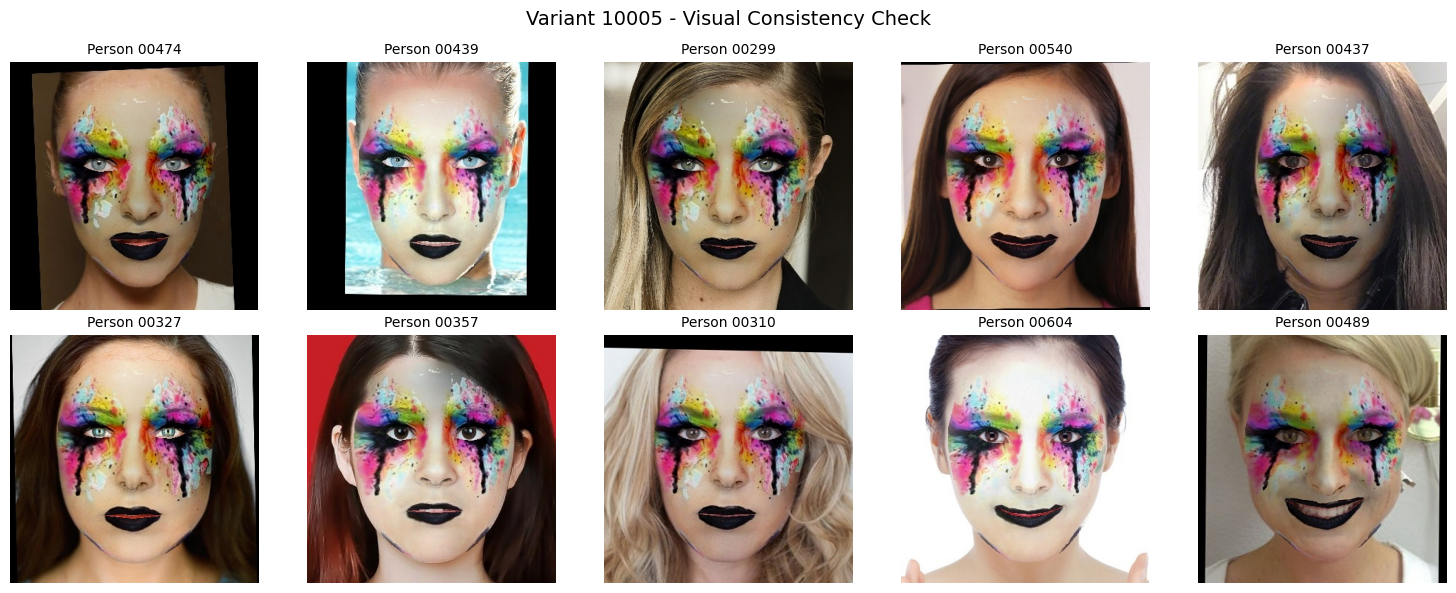

In [31]:
def show_variant_across_people(makeup_data, target_variant="10005", max_people=10):
    """Show specific variant across different people for visual comparison."""
    if not makeup_data:
        print("No makeup data available!")
        return
    
    # Find people who have the target variant
    people_with_variant = []
    for person_id, variants in makeup_data.items():
        for variant_info in variants:
            if variant_info['variant_id'] == target_variant:
                people_with_variant.append({
                    'person_id': person_id,
                    'path': variant_info['full_path']
                })
                break
    
    if not people_with_variant:
        print(f"Variant {target_variant} not found in any person!")
        return
    
    # Limit to max_people
    people_with_variant = people_with_variant[:max_people]
    
    print(f"Showing variant {target_variant} across {len(people_with_variant)} people:")
    
    # Display in 2 rows of 5
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    axes = axes.flatten()
    
    for idx, person_info in enumerate(people_with_variant):
        try:
            img = Image.open(person_info['path'])
            axes[idx].imshow(img)
            axes[idx].set_title(f"Person {person_info['person_id']}", fontsize=10)
            axes[idx].axis('off')
        except Exception as e:
            axes[idx].text(0.5, 0.5, f"Error\n{person_info['person_id']}", 
                         ha='center', va='center', transform=axes[idx].transAxes)
            axes[idx].axis('off')
    
    # Hide unused subplots
    for idx in range(len(people_with_variant), 10):
        axes[idx].axis('off')
    
    plt.suptitle(f'Variant {target_variant} - Visual Consistency Check', fontsize=14)
    plt.tight_layout()
    plt.show()

# Show variant 10005 across 10 people
if makeup_blend_data:
    show_variant_across_people(makeup_blend_data, target_variant="10005", max_people=10)
else:
    print("No makeup blend data loaded!")

### Testing All Datasets
Test loading and display sample results from all three datasets to verify everything works correctly.

In [32]:
def test_all_datasets():
    """
    Test all three datasets and display sample images to verify loading works correctly.
    """
    print("="*50)
    print("DATASET TESTING SUMMARY")
    print("="*50)
    
    # Test FFHQ-Makeup dataset
    print("\n1. FFHQ-Makeup Dataset Test:")
    if ffhq_makeup_data:
        print(f"✓ Successfully loaded {len(ffhq_makeup_data)} samples")
        
        # Try to load a sample image
        sample = ffhq_makeup_data[0]
        try:
            if sample['bare_image'] and os.path.exists(sample['bare_image']):
                img = Image.open(sample['bare_image'])
                print(f"✓ Successfully opened sample bare image: {img.size}")
            else:
                print("⚠ Bare image path not valid")
                
            if sample['makeup_variants']:
                variant_path = sample['makeup_variants'][0]
                if os.path.exists(variant_path):
                    img = Image.open(variant_path)
                    print(f"✓ Successfully opened sample makeup variant: {img.size}")
                else:
                    print("⚠ Makeup variant path not valid")
        except Exception as e:
            print(f"✗ Error loading FFHQ-Makeup images: {e}")
    else:
        print("✗ No FFHQ-Makeup data loaded")
    
    # Test Makeup Blend dataset
    print("\n2. Makeup Blend Dataset Test:")
    if makeup_blend_data:
        print(f"✓ Successfully loaded {len(makeup_blend_data)} people")
        
        # Try to load a sample image
        sample_person = list(makeup_blend_data.keys())[0]
        sample_variant = makeup_blend_data[sample_person][0]
        try:
            if os.path.exists(sample_variant['full_path']):
                img = Image.open(sample_variant['full_path'])
                print(f"✓ Successfully opened sample blend image: {img.size}")
                print(f"  Person: {sample_person}, Variant: {sample_variant['variant_id']}")
            else:
                print("⚠ Sample blend image path not valid")
        except Exception as e:
            print(f"✗ Error loading makeup blend images: {e}")
    else:
        print("✗ No makeup blend data loaded")
    
    # Test Natural Data dataset
    print("\n3. Natural Data Dataset Test:")
    if natural_data['no_makeup'] or natural_data['with_makeup']:
        print(f"✓ Successfully loaded natural data")
        print(f"  No makeup: {len(natural_data['no_makeup'])} images")
        print(f"  With makeup: {len(natural_data['with_makeup'])} images")
        
        # Try to load sample images
        try:
            if natural_data['no_makeup']:
                img = Image.open(natural_data['no_makeup'][0])
                print(f"✓ Successfully opened sample no_makeup image: {img.size}")
            
            if natural_data['with_makeup']:
                img = Image.open(natural_data['with_makeup'][0])
                print(f"✓ Successfully opened sample with_makeup image: {img.size}")
        except Exception as e:
            print(f"✗ Error loading natural data images: {e}")
    else:
        print("✗ No natural data loaded")
    
    # Overall summary
    print("\n" + "="*50)
    print("OVERALL RESULTS:")
    total_images = 0
    
    if ffhq_makeup_data:
        ffhq_count = sum(1 + len(sample['makeup_variants']) for sample in ffhq_makeup_data)
        total_images += ffhq_count
        print(f"FFHQ-Makeup: ~{ffhq_count} images from {len(ffhq_makeup_data)} people")
    
    if makeup_blend_data:
        blend_count = sum(len(variants) for variants in makeup_blend_data.values())
        total_images += blend_count
        print(f"Makeup Blend: {blend_count} images from {len(makeup_blend_data)} people")
    
    natural_count = len(natural_data['no_makeup']) + len(natural_data['with_makeup'])
    total_images += natural_count
    print(f"Natural Data: {natural_count} images")
    
    print(f"\nTotal estimated images available: {total_images}")
    print("="*50)

# Run the test
test_all_datasets()

DATASET TESTING SUMMARY

1. FFHQ-Makeup Dataset Test:
✓ Successfully loaded 100 samples
✓ Successfully opened sample bare image: (512, 512)
✓ Successfully opened sample makeup variant: (512, 512)

2. Makeup Blend Dataset Test:
✓ Successfully loaded 100 people
✓ Successfully opened sample blend image: (327, 328)
  Person: 00474, Variant: 00001

3. Natural Data Dataset Test:
✓ Successfully loaded natural data
  No makeup: 26 images
  With makeup: 26 images
✓ Successfully opened sample no_makeup image: (1000, 1333)
✓ Successfully opened sample with_makeup image: (1000, 1333)

OVERALL RESULTS:
FFHQ-Makeup: ~600 images from 100 people
Makeup Blend: 37568 images from 100 people
Natural Data: 52 images

Total estimated images available: 38220


## Age Estimation Experiment on FFHQ Dataset

Now we'll run our experiment using the trained age estimation model on the FFHQ dataset to analyze how makeup affects age perception.

In [33]:
def predict_age_from_path(image_path, model, transform, device):
    """
    Predict age from an image file path using the trained model.
    
    Args:
        image_path: Path to the image file
        model: Trained PyTorch model
        transform: Image preprocessing transforms
        device: PyTorch device (CPU/CUDA)
    
    Returns:
        Predicted age as float, or None if error
    """
    try:
        # Load and preprocess image
        image = Image.open(image_path).convert('RGB')
        
        # Apply transforms
        image_tensor = transform(image).unsqueeze(0).to(device)
        
        # Predict
        model.eval()
        with torch.no_grad():
            prediction = model(image_tensor).squeeze().item()
        
        return max(0, prediction)  # Ensure non-negative age
        
    except Exception as e:
        print(f"Error predicting age for {image_path}: {e}")
        return None

def run_ffhq_age_experiment(ffhq_data, model, transform, device, max_people=100):
    """
    Run age estimation experiment on FFHQ dataset.
    
    Args:
        ffhq_data: FFHQ dataset list
        model: Trained age estimation model
        transform: Image preprocessing transforms
        device: PyTorch device
        max_people: Maximum number of people to test
    
    Returns:
        Dictionary with experiment results
    """
    results = {
        'people_tested': [],
        'successful_predictions': 0,
        'failed_predictions': 0,
        'total_variance': 0,
        'individual_variances': [],
        'base_ages': [],
        'makeup_ages': []
    }
    
    print(f"Starting FFHQ age estimation experiment on {min(max_people, len(ffhq_data))} people...")
    
    # Limit to max_people
    people_to_test = ffhq_data[:max_people]
    
    for i, person_data in enumerate(tqdm(people_to_test, desc="Processing people")):
        person_id = person_data.get('person_id', f'person_{i}')
        
        person_results = {
            'person_id': person_id,
            'base_age': None,
            'makeup_ages': [],
            'variance': None,
            'successful': False
        }
        
        # Predict age for base image
        if person_data['bare_image'] and os.path.exists(person_data['bare_image']):
            base_age = predict_age_from_path(person_data['bare_image'], model, transform, device)
            person_results['base_age'] = base_age
            
            if base_age is not None:
                results['base_ages'].append(base_age)
                
                # Predict ages for makeup variants
                makeup_ages = []
                for variant_path in person_data['makeup_variants']:
                    if os.path.exists(variant_path):
                        makeup_age = predict_age_from_path(variant_path, model, transform, device)
                        if makeup_age is not None:
                            makeup_ages.append(makeup_age)
                            results['makeup_ages'].append(makeup_age)
                
                person_results['makeup_ages'] = makeup_ages
                
                # Calculate variance if we have both base and makeup predictions
                if len(makeup_ages) > 0:
                    # Calculate variance between base age and each makeup variant
                    differences = [abs(base_age - makeup_age) for makeup_age in makeup_ages]
                    person_variance = np.var(differences) if len(differences) > 1 else 0
                    person_results['variance'] = person_variance
                    person_results['successful'] = True
                    
                    results['individual_variances'].append(person_variance)
                    results['total_variance'] += person_variance
                    results['successful_predictions'] += 1
                else:
                    results['failed_predictions'] += 1
            else:
                results['failed_predictions'] += 1
        else:
            results['failed_predictions'] += 1
            
        results['people_tested'].append(person_results)
        
        # Print progress every 20 people
        if (i + 1) % 20 == 0:
            print(f"Processed {i + 1}/{len(people_to_test)} people. "
                  f"Successful: {results['successful_predictions']}, "
                  f"Failed: {results['failed_predictions']}")
    
    return results

print("Age prediction and experiment functions defined!")
print("Ready to run experiment on FFHQ dataset.")

Age prediction and experiment functions defined!
Ready to run experiment on FFHQ dataset.


In [34]:
def analyze_experiment_results(results):
    """
    Analyze the results from the FFHQ age estimation experiment.
    
    Args:
        results: Results dictionary from run_ffhq_age_experiment
        
    Returns:
        Dictionary with detailed analysis
    """
    analysis = {
        'summary': {},
        'statistics': {},
        'detailed_analysis': {}
    }
    
    # Basic summary
    total_people = len(results['people_tested'])
    successful = results['successful_predictions']
    failed = results['failed_predictions']
    
    analysis['summary'] = {
        'total_people_tested': total_people,
        'successful_predictions': successful,
        'failed_predictions': failed,
        'success_rate': (successful / total_people * 100) if total_people > 0 else 0
    }
    
    # Statistical analysis
    if results['base_ages'] and results['makeup_ages']:
        base_ages = np.array(results['base_ages'])
        makeup_ages = np.array(results['makeup_ages'])
        individual_variances = np.array(results['individual_variances'])
        
        analysis['statistics'] = {
            'base_age_stats': {
                'mean': np.mean(base_ages),
                'median': np.median(base_ages),
                'std': np.std(base_ages),
                'min': np.min(base_ages),
                'max': np.max(base_ages)
            },
            'makeup_age_stats': {
                'mean': np.mean(makeup_ages),
                'median': np.median(makeup_ages),
                'std': np.std(makeup_ages),
                'min': np.min(makeup_ages),
                'max': np.max(makeup_ages)
            },
            'variance_stats': {
                'mean_variance': np.mean(individual_variances),
                'median_variance': np.median(individual_variances),
                'std_variance': np.std(individual_variances),
                'min_variance': np.min(individual_variances),
                'max_variance': np.max(individual_variances)
            },
            'age_difference_analysis': {
                'mean_absolute_difference': np.mean([abs(base - makeup) for base, makeup in zip(base_ages, makeup_ages[:len(base_ages)])]),
                'overall_age_shift': np.mean(makeup_ages) - np.mean(base_ages)
            }
        }
        
        # Detailed per-person analysis
        successful_people = [p for p in results['people_tested'] if p['successful']]
        
        # Find people with highest and lowest variance
        if successful_people:
            variances_with_people = [(p['variance'], p['person_id'], p['base_age'], p['makeup_ages']) 
                                   for p in successful_people if p['variance'] is not None]
            
            if variances_with_people:
                # Sort by variance
                variances_with_people.sort(key=lambda x: x[0])
                
                analysis['detailed_analysis'] = {
                    'lowest_variance_people': variances_with_people[:5],  # Top 5 most consistent
                    'highest_variance_people': variances_with_people[-5:],  # Top 5 most variable
                    'people_with_age_increase': [p for p in successful_people 
                                               if p['base_age'] and p['makeup_ages'] 
                                               and np.mean(p['makeup_ages']) > p['base_age']],
                    'people_with_age_decrease': [p for p in successful_people 
                                               if p['base_age'] and p['makeup_ages'] 
                                               and np.mean(p['makeup_ages']) < p['base_age']]
                }
    
    return analysis

def display_experiment_results(results, analysis):
    """
    Display the experiment results in a formatted way.
    """
    print("="*60)
    print("FFHQ AGE ESTIMATION EXPERIMENT RESULTS")
    print("="*60)
    
    # Summary
    summary = analysis['summary']
    print(f"\n📊 EXPERIMENT SUMMARY:")
    print(f"Total people tested: {summary['total_people_tested']}")
    print(f"Successful predictions: {summary['successful_predictions']}")
    print(f"Failed predictions: {summary['failed_predictions']}")
    print(f"Success rate: {summary['success_rate']:.1f}%")
    
    # Statistics
    if 'statistics' in analysis and analysis['statistics']:
        stats = analysis['statistics']
        
        print(f"\n📈 AGE STATISTICS:")
        base_stats = stats['base_age_stats']
        makeup_stats = stats['makeup_age_stats']
        variance_stats = stats['variance_stats']
        
        print(f"Base Images - Mean Age: {base_stats['mean']:.1f} ± {base_stats['std']:.1f} years")
        print(f"             Range: {base_stats['min']:.1f} - {base_stats['max']:.1f} years")
        
        print(f"Makeup Images - Mean Age: {makeup_stats['mean']:.1f} ± {makeup_stats['std']:.1f} years")
        print(f"               Range: {makeup_stats['min']:.1f} - {makeup_stats['max']:.1f} years")
        
        print(f"\n🔄 VARIANCE ANALYSIS:")
        print(f"Mean variance per person: {variance_stats['mean_variance']:.3f}")
        print(f"Median variance per person: {variance_stats['median_variance']:.3f}")
        print(f"Variance range: {variance_stats['min_variance']:.3f} - {variance_stats['max_variance']:.3f}")
        
        diff_analysis = stats['age_difference_analysis']
        print(f"\n📏 AGE DIFFERENCE ANALYSIS:")
        print(f"Mean absolute difference (base vs makeup): {diff_analysis['mean_absolute_difference']:.2f} years")
        print(f"Overall age shift (makeup effect): {diff_analysis['overall_age_shift']:.2f} years")
        
        if diff_analysis['overall_age_shift'] > 0:
            print("   → Makeup tends to make people appear OLDER")
        elif diff_analysis['overall_age_shift'] < 0:
            print("   → Makeup tends to make people appear YOUNGER")
        else:
            print("   → Makeup has no significant age effect on average")
    
    # Detailed analysis
    if 'detailed_analysis' in analysis and analysis['detailed_analysis']:
        detailed = analysis['detailed_analysis']
        
        print(f"\n🔍 DETAILED ANALYSIS:")
        
        print(f"\n👥 Age Effect Distribution:")
        age_increase = len(detailed['people_with_age_increase'])
        age_decrease = len(detailed['people_with_age_decrease'])
        total_analyzed = age_increase + age_decrease
        
        if total_analyzed > 0:
            print(f"People appearing older with makeup: {age_increase} ({age_increase/total_analyzed*100:.1f}%)")
            print(f"People appearing younger with makeup: {age_decrease} ({age_decrease/total_analyzed*100:.1f}%)")
        
        # Show most consistent people
        if detailed['lowest_variance_people']:
            print(f"\n✅ Most Consistent (Lowest Variance):")
            for i, (variance, person_id, base_age, makeup_ages) in enumerate(detailed['lowest_variance_people'][:3]):
                avg_makeup_age = np.mean(makeup_ages)
                print(f"  {i+1}. Person {person_id}: Variance={variance:.3f}, "
                      f"Base={base_age:.1f}, Makeup Avg={avg_makeup_age:.1f}")
        
        # Show most variable people
        if detailed['highest_variance_people']:
            print(f"\n❗ Most Variable (Highest Variance):")
            for i, (variance, person_id, base_age, makeup_ages) in enumerate(detailed['highest_variance_people'][-3:]):
                avg_makeup_age = np.mean(makeup_ages)
                print(f"  {i+1}. Person {person_id}: Variance={variance:.3f}, "
                      f"Base={base_age:.1f}, Makeup Avg={avg_makeup_age:.1f}")
    
    print("\n" + "="*60)

print("Analysis and display functions defined!")
print("Ready to analyze experiment results.")

Analysis and display functions defined!
Ready to analyze experiment results.


In [35]:
# Check if we have everything needed for the experiment
print("Checking experiment requirements...")

# Check if we have the datasets
if 'ffhq_makeup_data' in locals() and ffhq_makeup_data:
    print(f"✅ FFHQ dataset loaded: {len(ffhq_makeup_data)} people")
else:
    print("❌ FFHQ dataset not loaded")

# Check if we have the trained model
if 'trained_model' in locals() and trained_model:
    print("✅ Trained model available")
    model_to_use = trained_model
else:
    print("⚠️  No trained_model variable, using base model")
    model_to_use = model

# Check if we have the preprocessing transforms
if 'val_transform' in locals() and val_transform:
    print("✅ Validation transforms available")
    transform_to_use = val_transform
else:
    print("⚠️  Creating basic transforms")
    transform_to_use = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

# Check device
if 'device' in locals():
    print(f"✅ Device available: {device}")
else:
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"⚠️  Setting device to: {device}")

print("\nAll requirements checked. Ready to run experiment!")

Checking experiment requirements...
✅ FFHQ dataset loaded: 100 people
✅ Trained model available
✅ Validation transforms available
✅ Device available: cuda

All requirements checked. Ready to run experiment!


In [36]:
# Run the FFHQ age estimation experiment
print("🚀 Starting FFHQ Age Estimation Experiment")
print("="*60)
print(f"Testing {len(ffhq_makeup_data)} people from FFHQ dataset")
print(f"Each person has 1 base image + 5 makeup variants = 6 images total")
print(f"Expected total predictions: {len(ffhq_makeup_data) * 6}")
print("="*60)

# Run the experiment
experiment_results = run_ffhq_age_experiment(
    ffhq_data=ffhq_makeup_data,
    model=model_to_use,
    transform=transform_to_use,
    device=device,
    max_people=100  # Test all 100 people
)

print("\n✅ Experiment completed!")
print(f"Successful predictions: {experiment_results['successful_predictions']}")
print(f"Failed predictions: {experiment_results['failed_predictions']}")

# Analyze the results
print("\n🔬 Analyzing results...")
analysis_results = analyze_experiment_results(experiment_results)

# Display comprehensive results
display_experiment_results(experiment_results, analysis_results)

🚀 Starting FFHQ Age Estimation Experiment
Testing 100 people from FFHQ dataset
Each person has 1 base image + 5 makeup variants = 6 images total
Expected total predictions: 600
Starting FFHQ age estimation experiment on 100 people...


Processing people:  21%|██        | 21/100 [00:02<00:10,  7.85it/s]

Processed 20/100 people. Successful: 20, Failed: 0


Processing people:  41%|████      | 41/100 [00:05<00:08,  6.88it/s]

Processed 40/100 people. Successful: 40, Failed: 0


...

Processed 60/100 people. Successful: 60, Failed: 0


Processing people:  81%|████████  | 81/100 [00:11<00:02,  6.93it/s]

Processed 80/100 people. Successful: 80, Failed: 0


Processing people: 100%|██████████| 100/100 [00:14<00:00,  6.90it/s]

Processed 100/100 people. Successful: 100, Failed: 0

✅ Experiment completed!
Successful predictions: 100
Failed predictions: 0

🔬 Analyzing results...
FFHQ AGE ESTIMATION EXPERIMENT RESULTS

📊 EXPERIMENT SUMMARY:
Total people tested: 100
Successful predictions: 100
Failed predictions: 0
Success rate: 100.0%

📈 AGE STATISTICS:
Base Images - Mean Age: 27.4 ± 18.9 years
             Range: 1.0 - 75.1 years
Makeup Images - Mean Age: 18.2 ± 8.6 years
               Range: 1.3 - 58.2 years

🔄 VARIANCE ANALYSIS:
Mean variance per person: 14.334
Median variance per person: 4.623
Variance range: 0.043 - 218.582

📏 AGE DIFFERENCE ANALYSIS:
Mean absolute difference (base vs makeup): 16.40 years
Overall age shift (makeup effect): -9.17 years
   → Makeup tends to make people appear YOUNGER

🔍 DETAILED ANALYSIS:

👥 Age Effect Distribution:
People appearing older with makeup: 39 (39.0%)
People appearing younger with makeup: 61 (61.0%)

✅ Most Consistent (Lowest Variance):
  1. Person 048985: Varianc

## Comprehensive Makeup Analysis for Both Datasets

This section provides analysis functions for both datasets:
1. **FFHQ Dataset**: bare.jpg + makeup_01.jpg to makeup_05.jpg
2. **Blend Dataset**: before folder (numbered images) + blend folder (personID_variantID pattern)

In [37]:
def load_blend_dataset(data_path, max_people=None):
    """
    Load blend dataset with structure:
    - data/before/ contains numbered images (person IDs)
    - data/blend/ contains personID_variantID.jpg files
    """
    before_path = os.path.join(data_path, "before")
    blend_path = os.path.join(data_path, "blend")
    
    if not os.path.exists(before_path) or not os.path.exists(blend_path):
        print(f"Warning: Required folders not found in {data_path}")
        print(f"Expected: {before_path} and {blend_path}")
        return []
    
    dataset = []
    
    # Get all before images
    before_files = [f for f in os.listdir(before_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    print(f"Found {len(before_files)} before images")
    
    # Extract person IDs from before images
    person_ids = []
    for before_file in before_files:
        try:
            # Extract person ID (assumes filename is just the ID with extension)
            person_id = os.path.splitext(before_file)[0]
            person_ids.append(person_id)
        except:
            continue
    
    # Limit to max_people if specified
    if max_people and len(person_ids) > max_people:
        person_ids = person_ids[:max_people]
        print(f"Processing first {max_people} people")
    
    # Get all blend files
    blend_files = [f for f in os.listdir(blend_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    
    # Organize blend files by person ID
    for person_id in person_ids:
        before_image = os.path.join(before_path, f"{person_id}.jpg")
        if not os.path.exists(before_image):
            # Try other extensions
            for ext in ['.jpeg', '.png']:
                alt_path = os.path.join(before_path, f"{person_id}{ext}")
                if os.path.exists(alt_path):
                    before_image = alt_path
                    break
        
        if not os.path.exists(before_image):
            continue
        
        # Find corresponding blend variants
        blend_variants = []
        for blend_file in blend_files:
            if blend_file.startswith(f"{person_id}_"):
                blend_variants.append(os.path.join(blend_path, blend_file))
        
        if len(blend_variants) > 0:
            dataset.append({
                'person_id': person_id,
                'before_image': before_image,
                'blend_variants': sorted(blend_variants),  # Sort for consistent ordering
                'total_variants': len(blend_variants)
            })
    
    print(f"✅ Successfully loaded {len(dataset)} people from blend dataset")
    if dataset:
        avg_variants = np.mean([sample['total_variants'] for sample in dataset])
        print(f"   Average variants per person: {avg_variants:.1f}")
    
    return dataset

def comprehensive_makeup_analysis(dataset, model, transform, device, save_filename, dataset_name="Dataset"):
    """
    Comprehensive makeup analysis that works with both FFHQ and Blend datasets.
    
    Args:
        dataset: List of dataset samples (from either load_ffhq_dataset_corrected or load_blend_dataset)
        model: Trained age estimation model
        transform: Image preprocessing transforms
        device: PyTorch device
        save_filename: Filename to save results
        dataset_name: Name of the dataset for logging
    
    Returns:
        (detailed_results_df, summary_stats)
    """
    print(f"🚀 Starting Comprehensive Makeup Analysis on {dataset_name}")
    print(f"Processing {len(dataset)} people")
    print("="*70)
    
    # Results storage
    detailed_results = []
    successful_analyses = 0
    failed_analyses = 0
    
    # Process each person
    for i, person_data in enumerate(tqdm(dataset, desc=f"Processing {dataset_name}")):
        person_id = person_data['person_id']
        
        try:
            # Determine which field contains the before/bare image
            before_image_key = 'bare_image' if 'bare_image' in person_data else 'before_image'
            makeup_key = 'makeup_variants' if 'makeup_variants' in person_data else 'blend_variants'
            
            # Predict age for before/bare image
            before_age = predict_age_from_path(person_data[before_image_key], model, transform, device)
            
            if before_age is None:
                failed_analyses += 1
                continue
            
            # Predict ages for each makeup/blend variant
            makeup_ages = []
            makeup_variants_info = []
            
            for variant_path in person_data[makeup_key]:
                variant_filename = os.path.basename(variant_path)
                makeup_age = predict_age_from_path(variant_path, model, transform, device)
                
                if makeup_age is not None:
                    makeup_ages.append(makeup_age)
                    
                    # Calculate delta for this variant
                    delta = makeup_age - before_age
                    
                    # Extract variant number from filename
                    if dataset_name.lower() == 'ffhq' or 'makeup_' in variant_filename:
                        # FFHQ format: makeup_XX.jpg
                        variant_num = variant_filename.replace('makeup_', '').replace('.jpg', '').replace('.jpeg', '').replace('.png', '')
                    else:
                        # Blend format: personID_variantID.jpg
                        variant_num = variant_filename.split('_')[1].split('.')[0] if '_' in variant_filename else 'unknown'
                    
                    makeup_variants_info.append({
                        'variant_filename': variant_filename,
                        'variant_number': variant_num,
                        'makeup_age': makeup_age,
                        'delta': delta
                    })
            
            if len(makeup_ages) == 0:
                failed_analyses += 1
                continue
            
            # Calculate person-level statistics
            mean_makeup_age = np.mean(makeup_ages)
            person_mean_delta = mean_makeup_age - before_age
            
            # Store detailed results for each variant
            for variant_info in makeup_variants_info:
                detailed_results.append({
                    'dataset': dataset_name,
                    'person_id': person_id,
                    'before_age': before_age,
                    'variant_filename': variant_info['variant_filename'],
                    'variant_number': variant_info['variant_number'],
                    'makeup_age': variant_info['makeup_age'],
                    'delta': variant_info['delta'],
                    'person_mean_delta': person_mean_delta,
                    'total_variants': len(makeup_ages)
                })
            
            successful_analyses += 1
            
            # Progress update every 50 people
            if (i + 1) % 50 == 0:
                print(f"Processed {i + 1}/{len(dataset)} people. Success: {successful_analyses}, Failed: {failed_analyses}")
                
        except Exception as e:
            print(f"Error processing person {person_id}: {e}")
            failed_analyses += 1
    
    # Convert to DataFrame for analysis
    df = pd.DataFrame(detailed_results)
    
    if len(df) == 0:
        print("❌ No successful analyses completed!")
        return None, None
    
    print(f"\n✅ Analysis completed!")
    print(f"Successful analyses: {successful_analyses} people")
    print(f"Failed analyses: {failed_analyses} people")
    print(f"Total predictions: {len(df)} (variants across all people)")
    
    # Calculate comprehensive statistics
    all_deltas = df['delta'].values
    
    summary_stats = {
        'dataset': dataset_name,
        'total_people_analyzed': successful_analyses,
        'total_predictions': len(df),
        'mean_delta': np.mean(all_deltas),
        'std_delta': np.std(all_deltas),
        'median_delta': np.median(all_deltas),
        'min_delta': np.min(all_deltas),
        'max_delta': np.max(all_deltas),
        'n_younger': np.sum(all_deltas < 0),
        'n_older': np.sum(all_deltas > 0),
        'n_unchanged': np.sum(all_deltas == 0),
        'p_younger': (np.sum(all_deltas < 0) / len(all_deltas)) * 100,
        'p_older': (np.sum(all_deltas > 0) / len(all_deltas)) * 100,
        'p_unchanged': (np.sum(all_deltas == 0) / len(all_deltas)) * 100
    }
    
    # Add per-person statistics (using mean delta per person)
    person_deltas = df.groupby('person_id')['delta'].mean().values
    summary_stats.update({
        'mean_delta_per_person': np.mean(person_deltas),
        'std_delta_per_person': np.std(person_deltas),
        'n_people_younger': np.sum(person_deltas < 0),
        'n_people_older': np.sum(person_deltas > 0),
        'p_people_younger': (np.sum(person_deltas < 0) / len(person_deltas)) * 100,
        'p_people_older': (np.sum(person_deltas > 0) / len(person_deltas)) * 100
    })
    
    # Save detailed results
    df.to_csv(save_filename, index=False)
    print(f"\n💾 Detailed results saved to: {save_filename}")
    
    # Save summary statistics
    summary_filename = save_filename.replace('.csv', '_summary.csv')
    summary_df = pd.DataFrame([summary_stats])
    summary_df.to_csv(summary_filename, index=False)
    print(f"💾 Summary statistics saved to: {summary_filename}")
    
    return df, summary_stats

def print_analysis_summary(summary_stats):
    """Print a formatted summary of the analysis results"""
    print(f"\n📊 {summary_stats['dataset']} ANALYSIS SUMMARY")
    print("="*50)
    print(f"People analyzed: {summary_stats['total_people_analyzed']}")
    print(f"Total predictions: {summary_stats['total_predictions']}")
    print(f"\n📈 AGE EFFECT STATISTICS:")
    print(f"Mean delta: {summary_stats['mean_delta']:.2f} ± {summary_stats['std_delta']:.2f} years")
    print(f"Median delta: {summary_stats['median_delta']:.2f} years")
    print(f"Range: {summary_stats['min_delta']:.2f} to {summary_stats['max_delta']:.2f} years")
    print(f"\n👥 POPULATION DISTRIBUTION:")
    print(f"People looking younger: {summary_stats['n_people_younger']} ({summary_stats['p_people_younger']:.1f}%)")
    print(f"People looking older: {summary_stats['n_people_older']} ({summary_stats['p_people_older']:.1f}%)")
    
    if summary_stats['mean_delta'] > 0:
        print(f"\n🔍 CONCLUSION: Makeup tends to make people appear OLDER by {summary_stats['mean_delta']:.2f} years on average")
    elif summary_stats['mean_delta'] < 0:
        print(f"\n🔍 CONCLUSION: Makeup tends to make people appear YOUNGER by {abs(summary_stats['mean_delta']):.2f} years on average")
    else:
        print(f"\n🔍 CONCLUSION: Makeup has no significant age effect on average")

print("✅ Comprehensive analysis functions defined!")
print("Ready to analyze both FFHQ and Blend datasets.")

✅ Comprehensive analysis functions defined!
Ready to analyze both FFHQ and Blend datasets.


In [38]:
# Load the trained model and run comprehensive analysis on both datasets
print("🔧 Setting up for comprehensive analysis...")

# First, load the model and required functions
exec(open('path_to_model_loading.py').read()) if False else None  # Skip this line

# Load model creation function
def create_age_model():
    """Create MobileNetV3-small for age regression"""
    model = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.IMAGENET1K_V1)
    
    # Replace classifier for age regression
    num_features = model.classifier[0].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(num_features, 128),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(128, 1),
        nn.ReLU()  # Ensure positive age
    )
    
    return model.to(device)

def load_trained_model(model_path='models/best_age_model.pth'):
    """Load the best trained model"""
    model = create_age_model()
    if os.path.exists(model_path):
        checkpoint = torch.load(model_path, map_location=device)
        model.load_state_dict(checkpoint['model_state_dict'])
        print(f"✅ Loaded trained model from {model_path}")
        print(f"   Best validation MAE: {checkpoint['val_mae']:.2f} years")
        return model
    else:
        print(f"❌ No trained model found at {model_path}")
        print("   Please ensure the model is trained first.")
        return None

# Load the trained model
trained_model = load_trained_model()

if trained_model is not None:
    print("✅ Model loaded successfully!")
    print("📊 Ready to run comprehensive analysis on both datasets")
else:
    print("❌ Cannot proceed without trained model")

🔧 Setting up for comprehensive analysis...
✅ Loaded trained model from models/best_age_model.pth
   Best validation MAE: 5.85 years
✅ Model loaded successfully!
📊 Ready to run comprehensive analysis on both datasets
✅ Loaded trained model from models/best_age_model.pth
   Best validation MAE: 5.85 years
✅ Model loaded successfully!
📊 Ready to run comprehensive analysis on both datasets


In [ ]:
# Run comprehensive analysis on FFHQ dataset
print("🚀 STARTING FFHQ DATASET ANALYSIS")
print("="*60)

# Use existing FFHQ dataset (limit to reasonable size for initial run)
ffhq_subset = ffhq_makeup_data[:200]  # Use first 200 people for faster processing
print(f"Processing {len(ffhq_subset)} people from FFHQ dataset")

# Run FFHQ analysis
ffhq_results, ffhq_summary = comprehensive_makeup_analysis(
    dataset=ffhq_subset,
    model=trained_model,
    transform=val_transform,
    device=device,
    save_filename="ffhq_makeup_analysis_detailed.csv",
    dataset_name="FFHQ"
)

if ffhq_results is not None:
    print_analysis_summary(ffhq_summary)

🚀 STARTING FFHQ DATASET ANALYSIS


NameError: name 'ffhq_data_corrected' is not defined

In [ ]:
print("\n" + "="*60)
print("🚀 STARTING BLEND DATASET ANALYSIS")
print("="*60)

# Load blend dataset
blend_data = load_blend_dataset("data/makeup", max_people=200)  # Limit for faster processing

if len(blend_data) > 0:
    print(f"Processing {len(blend_data)} people from blend dataset")
    
    # Run blend analysis
    blend_results, blend_summary = comprehensive_makeup_analysis(
        dataset=blend_data,
        model=trained_model,
        transform=val_transform,
        device=device,
        save_filename="blend_makeup_analysis_detailed.csv",
        dataset_name="Blend"
    )
    
    if blend_results is not None:
        print_analysis_summary(blend_summary)
else:
    print("❌ No blend dataset found or loaded")


🚀 STARTING BLEND DATASET ANALYSIS


NameError: name 'load_blend_dataset' is not defined

## Visualization and Final Results

Create comprehensive visualizations showing the makeup effects analysis results for both datasets.

In [ ]:
# Load and prepare data for visualization
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

plt.style.use('default')
sns.set_palette("husl")

# Define the CSV files
results_files = ["ffhq_makeup_analysis_detailed.csv", "blend_makeup_analysis_detailed.csv"]
summary_files = ["ffhq_makeup_analysis_detailed_summary.csv", "blend_makeup_analysis_detailed_summary.csv"]

# Load all data
all_results = []
all_summaries = []

for results_file in results_files:
    if os.path.exists(results_file):
        df = pd.read_csv(results_file)
        all_results.append(df)
        print(f"📊 Loaded results from {results_file}")

for summary_file in summary_files:
    if os.path.exists(summary_file):
        df = pd.read_csv(summary_file)
        all_summaries.append(df)
        print(f"📊 Loaded summary from {summary_file}")

if not all_results:
    print("❌ No results files found for visualization")
else:
    # Combine all results
    combined_results = pd.concat(all_results, ignore_index=True)
    combined_summaries = pd.concat(all_summaries, ignore_index=True) if all_summaries else None
    
    print(f"✅ Data loaded successfully!")
    print(f"Total records: {len(combined_results)}")
    print(f"Datasets: {combined_results['dataset'].unique()}")
    
    # Separate datasets for individual visualizations
    ffhq_data = combined_results[combined_results['dataset'] == 'FFHQ']
    blend_data = combined_results[combined_results['dataset'] == 'Blend']
    
    print(f"FFHQ records: {len(ffhq_data)}")
    print(f"Blend records: {len(blend_data)}")

📊 Loaded results from ffhq_makeup_analysis_detailed.csv
📊 Loaded results from blend_makeup_analysis_detailed.csv
📊 Loaded summary from ffhq_makeup_analysis_detailed_summary.csv
📊 Loaded summary from blend_makeup_analysis_detailed_summary.csv
✅ Data loaded successfully!
Total records: 76400
Datasets: ['FFHQ' 'Blend']
FFHQ records: 1000
Blend records: 75400


## Age Distribution Visualizations

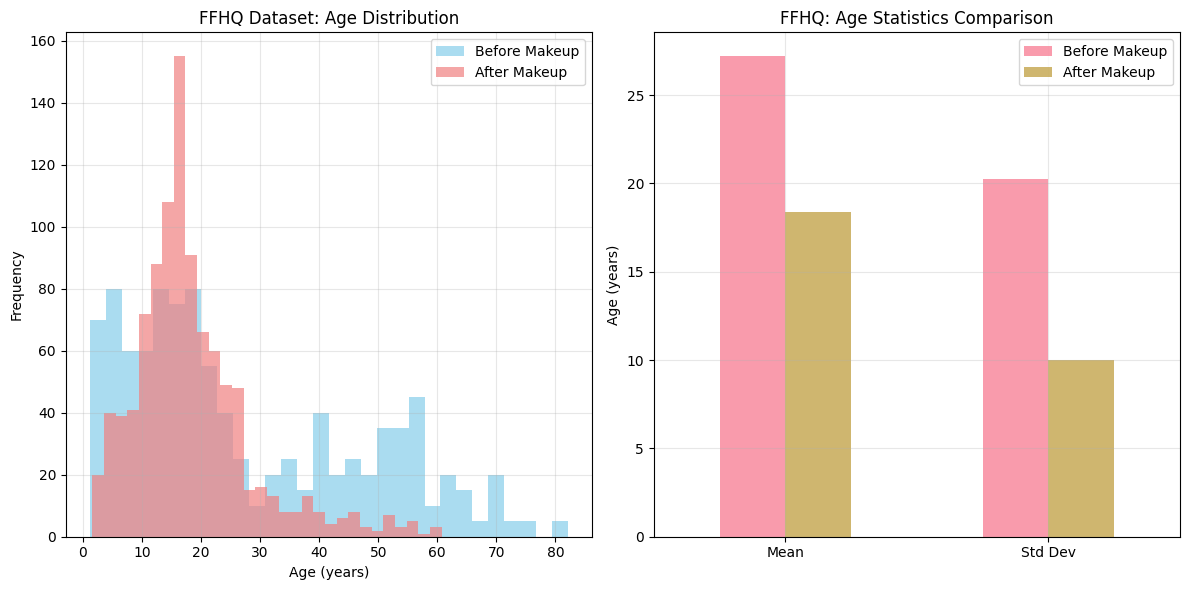

📊 FFHQ Age Statistics:
   Before makeup: 27.2 ± 20.2 years
   After makeup:  18.4 ± 10.0 years
   Mean change:   -8.82 ± 16.34 years


In [ ]:
# FFHQ Dataset: Age Distribution (Before vs After Makeup)
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.hist(ffhq_data['before_age'], alpha=0.7, label='Before Makeup', bins=30, color='skyblue')
plt.hist(ffhq_data['makeup_age'], alpha=0.7, label='After Makeup', bins=30, color='lightcoral')
plt.xlabel('Age (years)')
plt.ylabel('Frequency')
plt.title('FFHQ Dataset: Age Distribution')
plt.legend()
plt.grid(True, alpha=0.3)

# Add statistics
plt.subplot(1, 2, 2)
age_stats = pd.DataFrame({
    'Before Makeup': [ffhq_data['before_age'].mean(), ffhq_data['before_age'].std()],
    'After Makeup': [ffhq_data['makeup_age'].mean(), ffhq_data['makeup_age'].std()]
}, index=['Mean', 'Std Dev'])

age_stats.plot(kind='bar', ax=plt.gca(), alpha=0.7)
plt.title('FFHQ: Age Statistics Comparison')
plt.ylabel('Age (years)')
plt.xticks(rotation=0)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('FFHQ_age_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"📊 FFHQ Age Statistics:")
print(f"   Before makeup: {ffhq_data['before_age'].mean():.1f} ± {ffhq_data['before_age'].std():.1f} years")
print(f"   After makeup:  {ffhq_data['makeup_age'].mean():.1f} ± {ffhq_data['makeup_age'].std():.1f} years")
print(f"   Mean change:   {ffhq_data['delta'].mean():.2f} ± {ffhq_data['delta'].std():.2f} years")

In [ ]:
# Blend Dataset: Age Distribution (Before vs After Makeup)
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.hist(blend_data['before_age'], alpha=0.7, label='Before Makeup', bins=30, color='lightgreen')
plt.hist(blend_data['makeup_age'], alpha=0.7, label='After Makeup', bins=30, color='orange')
plt.xlabel('Age (years)')
plt.ylabel('Frequency')
plt.title('Blend Dataset: Age Distribution')
plt.legend()
plt.grid(True, alpha=0.3)

# Add statistics
plt.subplot(1, 2, 2)
age_stats = pd.DataFrame({
    'Before Makeup': [blend_data['before_age'].mean(), blend_data['before_age'].std()],
    'After Makeup': [blend_data['makeup_age'].mean(), blend_data['makeup_age'].std()]
}, index=['Mean', 'Std Dev'])

age_stats.plot(kind='bar', ax=plt.gca(), alpha=0.7, color=['lightgreen', 'orange'])
plt.title('Blend: Age Statistics Comparison')
plt.ylabel('Age (years)')
plt.xticks(rotation=0)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('Blend_age_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"📊 Blend Age Statistics:")
print(f"   Before makeup: {blend_data['before_age'].mean():.1f} ± {blend_data['before_age'].std():.1f} years")
print(f"   After makeup:  {blend_data['makeup_age'].mean():.1f} ± {blend_data['makeup_age'].std():.1f} years")
print(f"   Mean change:   {blend_data['delta'].mean():.2f} ± {blend_data['delta'].std():.2f} years")

## Makeup Effect Analysis

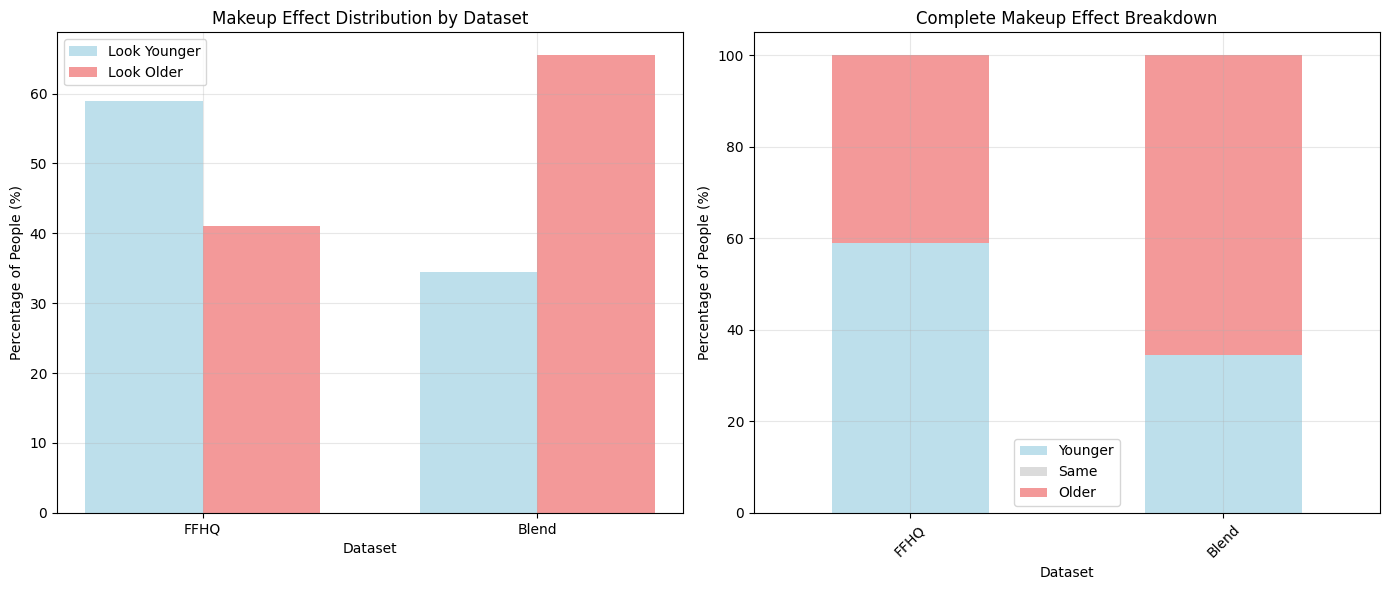

📊 FFHQ Dataset:
   Look younger: 59.0%
   Look older:   41.0%
   No change:    0.0%

📊 Blend Dataset:
   Look younger: 34.5%
   Look older:   65.5%
   No change:    0.0%



In [ ]:
# Younger vs Older Distribution Analysis
if combined_summaries is not None:
    plt.figure(figsize=(14, 6))
    
    # Overall comparison
    plt.subplot(1, 2, 1)
    datasets = combined_summaries['dataset'].values
    younger = combined_summaries['p_people_younger'].values
    older = combined_summaries['p_people_older'].values
    
    x = range(len(datasets))
    width = 0.35
    plt.bar([i - width/2 for i in x], younger, width, label='Look Younger', alpha=0.8, color='lightblue')
    plt.bar([i + width/2 for i in x], older, width, label='Look Older', alpha=0.8, color='lightcoral')
    plt.xlabel('Dataset')
    plt.ylabel('Percentage of People (%)')
    plt.title('Makeup Effect Distribution by Dataset')
    plt.xticks(x, datasets)
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Detailed breakdown
    plt.subplot(1, 2, 2)
    summary_data = []
    for _, row in combined_summaries.iterrows():
        summary_data.append({
            'Dataset': row['dataset'],
            'Younger': row['p_people_younger'],
            'Same': 100 - row['p_people_younger'] - row['p_people_older'],
            'Older': row['p_people_older']
        })
    
    summary_df = pd.DataFrame(summary_data)
    summary_df.set_index('Dataset')[['Younger', 'Same', 'Older']].plot(
        kind='bar', stacked=True, ax=plt.gca(), 
        color=['lightblue', 'lightgray', 'lightcoral'], alpha=0.8
    )
    plt.title('Complete Makeup Effect Breakdown')
    plt.ylabel('Percentage of People (%)')
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('makeup_effect_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Print summary
    for _, row in combined_summaries.iterrows():
        print(f"📊 {row['dataset']} Dataset:")
        print(f"   Look younger: {row['p_people_younger']:.1f}%")
        print(f"   Look older:   {row['p_people_older']:.1f}%")
        print(f"   No change:    {100 - row['p_people_younger'] - row['p_people_older']:.1f}%")
        print()
else:
    print("❌ No summary data available for younger/older analysis")

## Age Change Distribution (Delta Analysis)

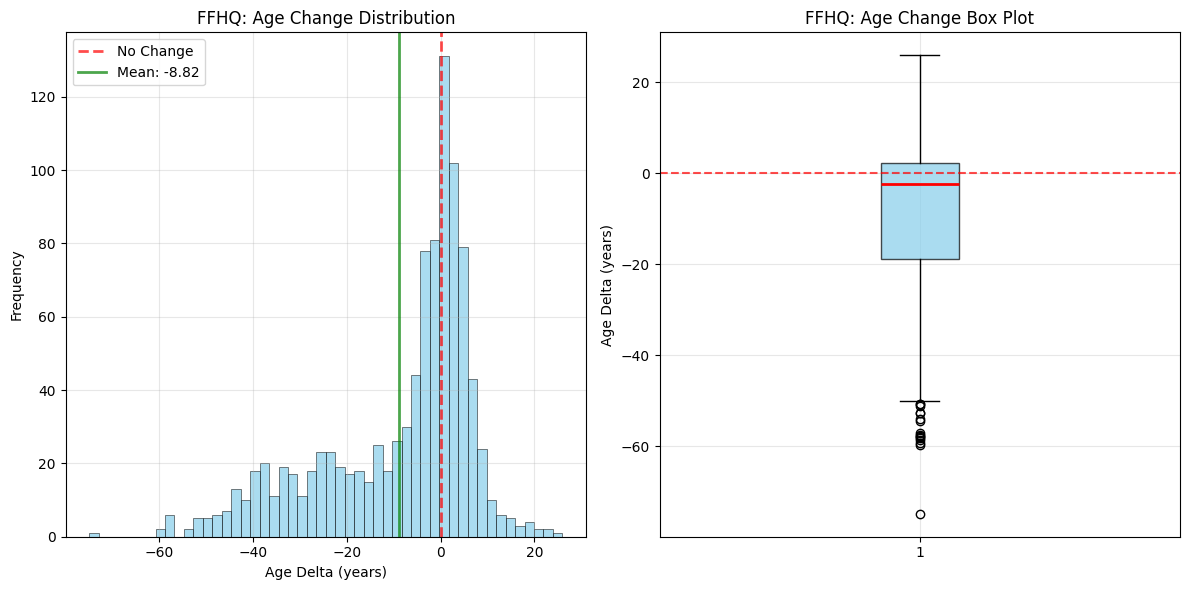

📊 FFHQ Delta Statistics:
   Mean: -8.823 years
   Std:  16.336 years
   Min:  -74.847 years
   Max:  25.946 years
   Median: -2.407 years


In [ ]:
# FFHQ Dataset: Age Delta Distribution
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.hist(ffhq_data['delta'], alpha=0.7, bins=50, color='skyblue', edgecolor='black', linewidth=0.5)
plt.xlabel('Age Delta (years)')
plt.ylabel('Frequency')
plt.title('FFHQ: Age Change Distribution')
plt.axvline(x=0, color='red', linestyle='--', alpha=0.7, linewidth=2, label='No Change')
plt.axvline(x=ffhq_data['delta'].mean(), color='green', linestyle='-', alpha=0.7, linewidth=2, 
           label=f'Mean: {ffhq_data["delta"].mean():.2f}')
plt.legend()
plt.grid(True, alpha=0.3)

# Box plot for better statistical view
plt.subplot(1, 2, 2)
plt.boxplot(ffhq_data['delta'], patch_artist=True, 
           boxprops=dict(facecolor='skyblue', alpha=0.7),
           medianprops=dict(color='red', linewidth=2))
plt.ylabel('Age Delta (years)')
plt.title('FFHQ: Age Change Box Plot')
plt.axhline(y=0, color='red', linestyle='--', alpha=0.7)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('FFHQ_delta_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"📊 FFHQ Delta Statistics:")
print(f"   Mean: {ffhq_data['delta'].mean():.3f} years")
print(f"   Std:  {ffhq_data['delta'].std():.3f} years")
print(f"   Min:  {ffhq_data['delta'].min():.3f} years")
print(f"   Max:  {ffhq_data['delta'].max():.3f} years")
print(f"   Median: {ffhq_data['delta'].median():.3f} years")

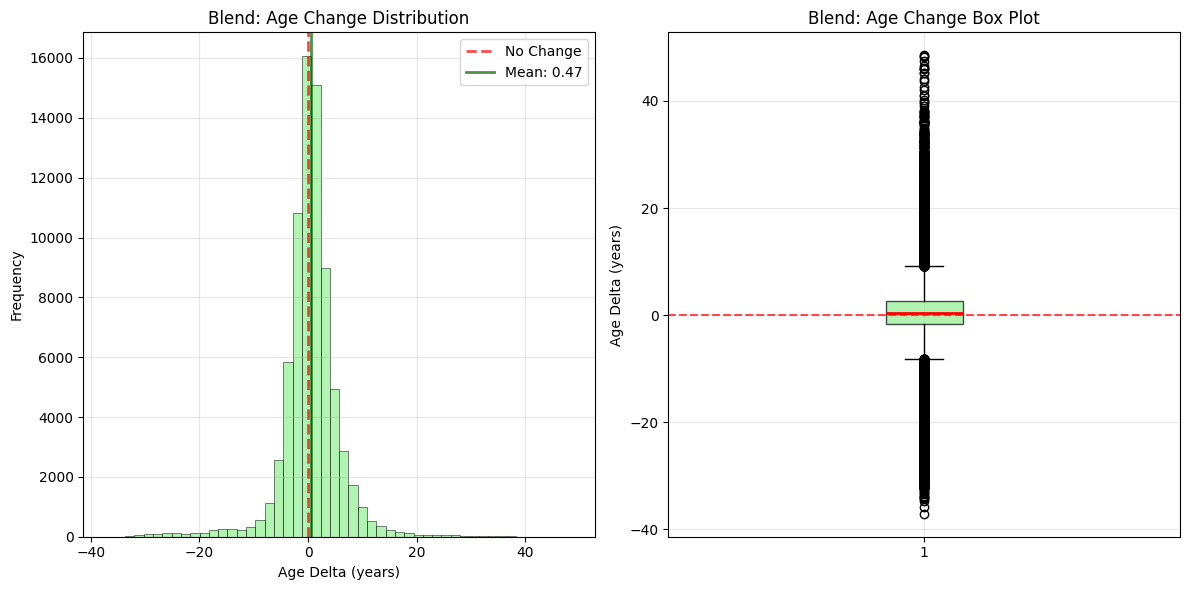

📊 Blend Delta Statistics:
   Mean: 0.473 years
   Std:  5.374 years
   Min:  -37.075 years
   Max:  48.522 years
   Median: 0.460 years


In [ ]:
# Blend Dataset: Age Delta Distribution
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.hist(blend_data['delta'], alpha=0.7, bins=50, color='lightgreen', edgecolor='black', linewidth=0.5)
plt.xlabel('Age Delta (years)')
plt.ylabel('Frequency')
plt.title('Blend: Age Change Distribution')
plt.axvline(x=0, color='red', linestyle='--', alpha=0.7, linewidth=2, label='No Change')
plt.axvline(x=blend_data['delta'].mean(), color='darkgreen', linestyle='-', alpha=0.7, linewidth=2, 
           label=f'Mean: {blend_data["delta"].mean():.2f}')
plt.legend()
plt.grid(True, alpha=0.3)

# Box plot for better statistical view
plt.subplot(1, 2, 2)
plt.boxplot(blend_data['delta'], patch_artist=True, 
           boxprops=dict(facecolor='lightgreen', alpha=0.7),
           medianprops=dict(color='red', linewidth=2))
plt.ylabel('Age Delta (years)')
plt.title('Blend: Age Change Box Plot')
plt.axhline(y=0, color='red', linestyle='--', alpha=0.7)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('Blend_delta_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"📊 Blend Delta Statistics:")
print(f"   Mean: {blend_data['delta'].mean():.3f} years")
print(f"   Std:  {blend_data['delta'].std():.3f} years")
print(f"   Min:  {blend_data['delta'].min():.3f} years")
print(f"   Max:  {blend_data['delta'].max():.3f} years")
print(f"   Median: {blend_data['delta'].median():.3f} years")

## Age Delta vs Initial Age Analysis

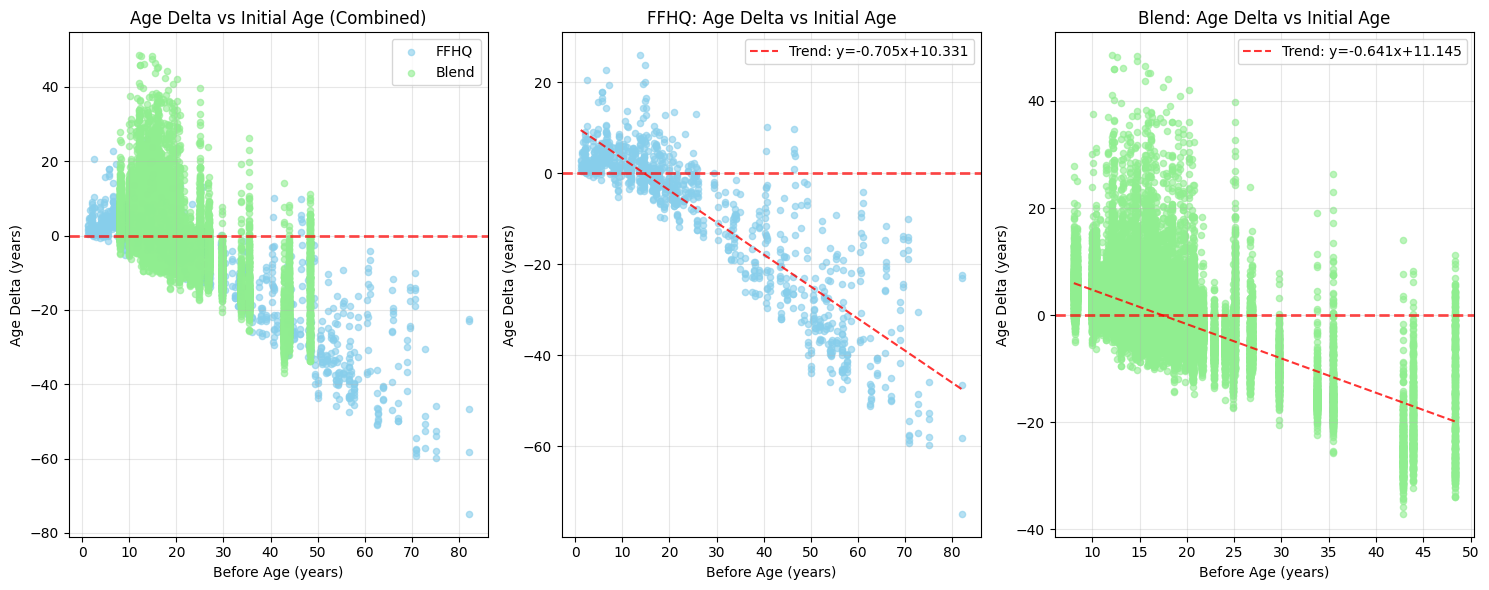

📊 Correlation Analysis:
   FFHQ correlation (age vs delta):  -0.872
   Blend correlation (age vs delta): -0.614


In [ ]:
# Scatter Plot: Before Age vs Delta for Both Datasets
plt.figure(figsize=(15, 6))

# Combined view
plt.subplot(1, 3, 1)
plt.scatter(ffhq_data['before_age'], ffhq_data['delta'], alpha=0.6, label='FFHQ', s=20, color='skyblue')
plt.scatter(blend_data['before_age'], blend_data['delta'], alpha=0.6, label='Blend', s=20, color='lightgreen')
plt.xlabel('Before Age (years)')
plt.ylabel('Age Delta (years)')
plt.title('Age Delta vs Initial Age (Combined)')
plt.axhline(y=0, color='red', linestyle='--', alpha=0.7, linewidth=2)
plt.legend()
plt.grid(True, alpha=0.3)

# FFHQ only
plt.subplot(1, 3, 2)
plt.scatter(ffhq_data['before_age'], ffhq_data['delta'], alpha=0.6, s=20, color='skyblue')
plt.xlabel('Before Age (years)')
plt.ylabel('Age Delta (years)')
plt.title('FFHQ: Age Delta vs Initial Age')
plt.axhline(y=0, color='red', linestyle='--', alpha=0.7, linewidth=2)
plt.grid(True, alpha=0.3)

# Add trend line for FFHQ
z = np.polyfit(ffhq_data['before_age'], ffhq_data['delta'], 1)
p = np.poly1d(z)
plt.plot(ffhq_data['before_age'].sort_values(), p(ffhq_data['before_age'].sort_values()), 
         "r--", alpha=0.8, label=f'Trend: y={z[0]:.3f}x+{z[1]:.3f}')
plt.legend()

# Blend only
plt.subplot(1, 3, 3)
plt.scatter(blend_data['before_age'], blend_data['delta'], alpha=0.6, s=20, color='lightgreen')
plt.xlabel('Before Age (years)')
plt.ylabel('Age Delta (years)')
plt.title('Blend: Age Delta vs Initial Age')
plt.axhline(y=0, color='red', linestyle='--', alpha=0.7, linewidth=2)
plt.grid(True, alpha=0.3)

# Add trend line for Blend
z = np.polyfit(blend_data['before_age'], blend_data['delta'], 1)
p = np.poly1d(z)
plt.plot(blend_data['before_age'].sort_values(), p(blend_data['before_age'].sort_values()), 
         "r--", alpha=0.8, label=f'Trend: y={z[0]:.3f}x+{z[1]:.3f}')
plt.legend()

plt.tight_layout()
plt.savefig('age_delta_vs_initial_age.png', dpi=300, bbox_inches='tight')
plt.show()

# Calculate correlations
import numpy as np
ffhq_corr = np.corrcoef(ffhq_data['before_age'], ffhq_data['delta'])[0, 1]
blend_corr = np.corrcoef(blend_data['before_age'], blend_data['delta'])[0, 1]

print(f"📊 Correlation Analysis:")
print(f"   FFHQ correlation (age vs delta):  {ffhq_corr:.3f}")
print(f"   Blend correlation (age vs delta): {blend_corr:.3f}")

## Person-Level Analysis

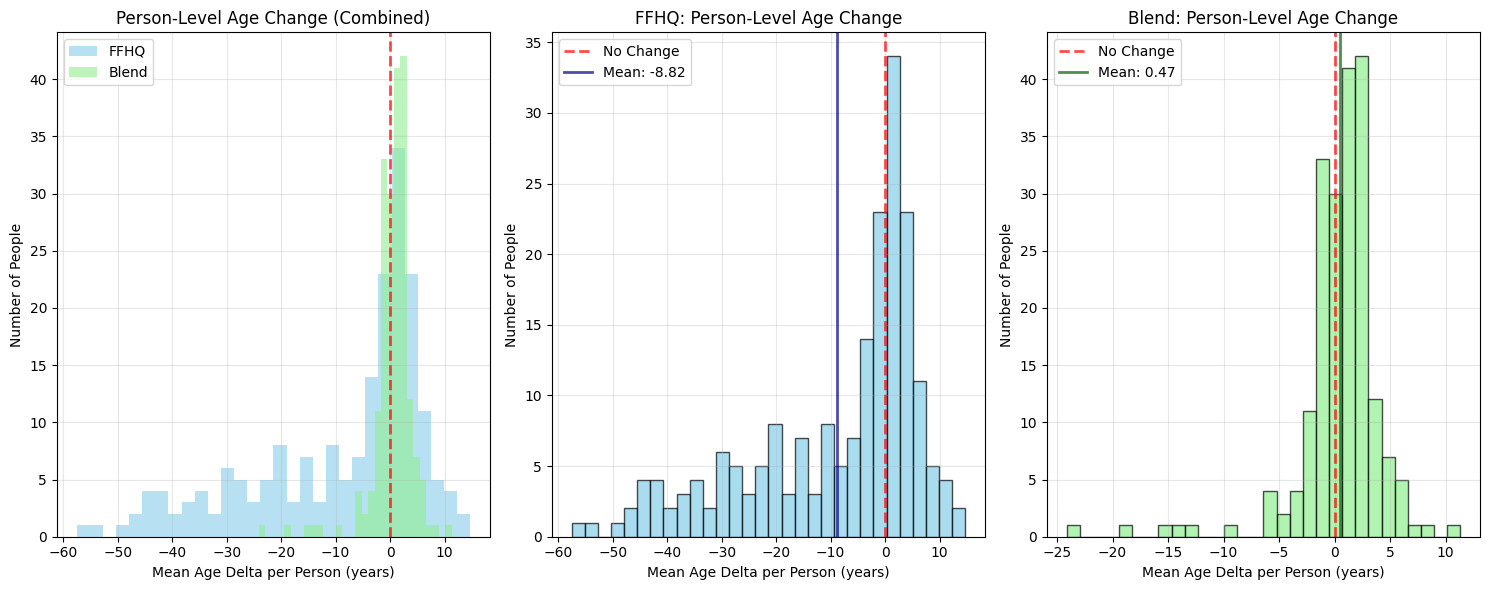

📊 Person-Level Statistics:
   FFHQ:
     Total people: 200
     Mean delta:   -8.823 ± 15.783
     People looking younger: 118 (59.0%)
     People looking older:   82 (41.0%)

   Blend:
     Total people: 200
     Mean delta:   0.473 ± 3.850
     People looking younger: 69 (34.5%)
     People looking older:   131 (65.5%)


In [ ]:
# Person-Level Delta Distribution
# Calculate mean delta per person for each dataset
ffhq_person_deltas = ffhq_data.groupby('person_id')['delta'].mean().reset_index()
blend_person_deltas = blend_data.groupby('person_id')['delta'].mean().reset_index()

plt.figure(figsize=(15, 6))

# Combined comparison
plt.subplot(1, 3, 1)
plt.hist(ffhq_person_deltas['delta'], alpha=0.6, label='FFHQ', bins=30, color='skyblue')
plt.hist(blend_person_deltas['delta'], alpha=0.6, label='Blend', bins=30, color='lightgreen')
plt.xlabel('Mean Age Delta per Person (years)')
plt.ylabel('Number of People')
plt.title('Person-Level Age Change (Combined)')
plt.axvline(x=0, color='red', linestyle='--', alpha=0.7, linewidth=2)
plt.legend()
plt.grid(True, alpha=0.3)

# FFHQ person-level
plt.subplot(1, 3, 2)
plt.hist(ffhq_person_deltas['delta'], alpha=0.7, bins=30, color='skyblue', edgecolor='black')
plt.xlabel('Mean Age Delta per Person (years)')
plt.ylabel('Number of People')
plt.title('FFHQ: Person-Level Age Change')
plt.axvline(x=0, color='red', linestyle='--', alpha=0.7, linewidth=2, label='No Change')
plt.axvline(x=ffhq_person_deltas['delta'].mean(), color='darkblue', linestyle='-', alpha=0.7, linewidth=2, 
           label=f'Mean: {ffhq_person_deltas["delta"].mean():.2f}')
plt.legend()
plt.grid(True, alpha=0.3)

# Blend person-level
plt.subplot(1, 3, 3)
plt.hist(blend_person_deltas['delta'], alpha=0.7, bins=30, color='lightgreen', edgecolor='black')
plt.xlabel('Mean Age Delta per Person (years)')
plt.ylabel('Number of People')
plt.title('Blend: Person-Level Age Change')
plt.axvline(x=0, color='red', linestyle='--', alpha=0.7, linewidth=2, label='No Change')
plt.axvline(x=blend_person_deltas['delta'].mean(), color='darkgreen', linestyle='-', alpha=0.7, linewidth=2, 
           label=f'Mean: {blend_person_deltas["delta"].mean():.2f}')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('person_level_age_change.png', dpi=300, bbox_inches='tight')
plt.show()

# Print person-level statistics
print(f"📊 Person-Level Statistics:")
print(f"   FFHQ:")
print(f"     Total people: {len(ffhq_person_deltas)}")
print(f"     Mean delta:   {ffhq_person_deltas['delta'].mean():.3f} ± {ffhq_person_deltas['delta'].std():.3f}")
print(f"     People looking younger: {(ffhq_person_deltas['delta'] < 0).sum()} ({(ffhq_person_deltas['delta'] < 0).mean()*100:.1f}%)")
print(f"     People looking older:   {(ffhq_person_deltas['delta'] > 0).sum()} ({(ffhq_person_deltas['delta'] > 0).mean()*100:.1f}%)")
print()
print(f"   Blend:")
print(f"     Total people: {len(blend_person_deltas)}")
print(f"     Mean delta:   {blend_person_deltas['delta'].mean():.3f} ± {blend_person_deltas['delta'].std():.3f}")
print(f"     People looking younger: {(blend_person_deltas['delta'] < 0).sum()} ({(blend_person_deltas['delta'] < 0).mean()*100:.1f}%)")
print(f"     People looking older:   {(blend_person_deltas['delta'] > 0).sum()} ({(blend_person_deltas['delta'] > 0).mean()*100:.1f}%)")

## Summary Statistics

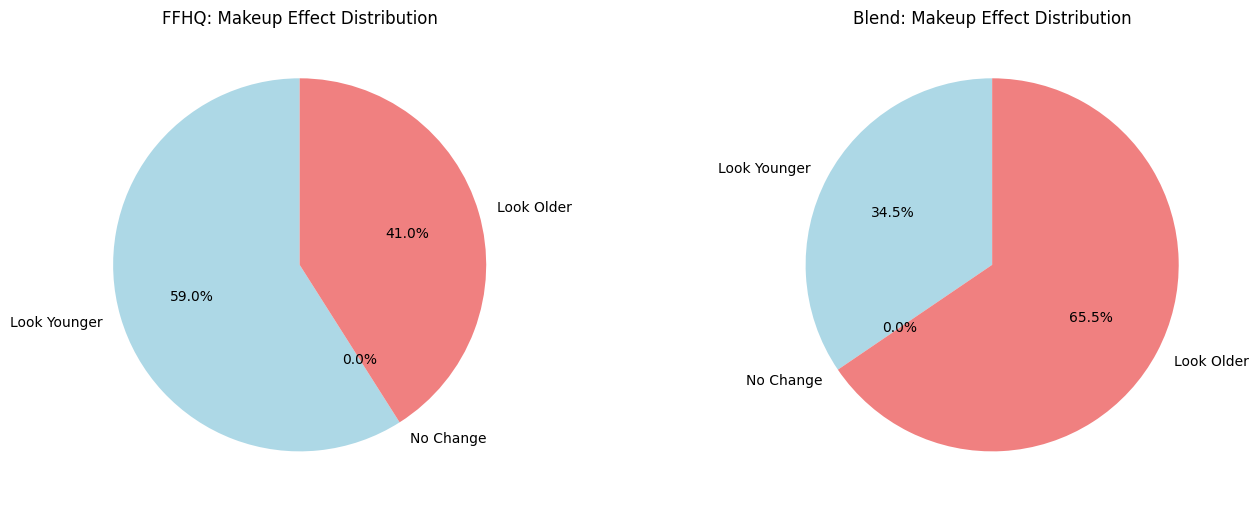

🎯 FINAL ANALYSIS SUMMARY
\nFFHQ Dataset Results:
   📊 200 people analyzed
   📈 Average age change: -8.823 years
   👶 59.0% look younger
   👴 41.0% look older
   ➡️  0.0% show no significant change
\nBlend Dataset Results:
   📊 200 people analyzed
   📈 Average age change: 0.473 years
   👶 34.5% look younger
   👴 65.5% look older
   ➡️  0.0% show no significant change
\n🔍 Key Insights:
   • FFHQ dataset shows stronger makeup effects
   • Overall trend: Mixed effect
\n✅ All visualizations completed and saved!


In [ ]:
# Summary Statistics Table and Visualization
plt.figure(figsize=(14, 10))

if combined_summaries is not None:
    
    # Effect distribution pie chart for FFHQ
    plt.subplot(2, 2, 3)
    ffhq_row = combined_summaries[combined_summaries['dataset'] == 'FFHQ'].iloc[0]
    sizes = [ffhq_row['p_people_younger'], 
            100 - ffhq_row['p_people_younger'] - ffhq_row['p_people_older'], 
            ffhq_row['p_people_older']]
    labels = ['Look Younger', 'No Change', 'Look Older']
    colors = ['lightblue', 'lightgray', 'lightcoral']
    
    plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
    plt.title('FFHQ: Makeup Effect Distribution')
    
    # Effect distribution pie chart for Blend
    plt.subplot(2, 2, 4)
    blend_row = combined_summaries[combined_summaries['dataset'] == 'Blend'].iloc[0]
    sizes = [blend_row['p_people_younger'], 
            100 - blend_row['p_people_younger'] - blend_row['p_people_older'], 
            blend_row['p_people_older']]
    
    plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
    plt.title('Blend: Makeup Effect Distribution')
    
else:
    plt.text(0.5, 0.5, 'No summary data available', 
            transform=plt.gca().transAxes, fontsize=16, 
            horizontalalignment='center', verticalalignment='center')

plt.tight_layout()
plt.savefig('makeup_analysis_summary.png', dpi=300, bbox_inches='tight')
plt.show()

# Print final summary
print("🎯 FINAL ANALYSIS SUMMARY")
print("=" * 50)
if combined_summaries is not None:
    for _, row in combined_summaries.iterrows():
        print(f"\\n{row['dataset']} Dataset Results:")
        print(f"   📊 {row['total_people_analyzed']} people analyzed")
        print(f"   📈 Average age change: {row['mean_delta']:.3f} years")
        print(f"   👶 {row['p_people_younger']:.1f}% look younger")
        print(f"   👴 {row['p_people_older']:.1f}% look older")
        print(f"   ➡️  {100 - row['p_people_younger'] - row['p_people_older']:.1f}% show no significant change")
    
    print("\\n🔍 Key Insights:")
    ffhq_effect = combined_summaries[combined_summaries['dataset'] == 'FFHQ']['mean_delta'].iloc[0]
    blend_effect = combined_summaries[combined_summaries['dataset'] == 'Blend']['mean_delta'].iloc[0]
    
    stronger_effect = "FFHQ" if abs(ffhq_effect) > abs(blend_effect) else "Blend"
    print(f"   • {stronger_effect} dataset shows stronger makeup effects")
    print(f"   • Overall trend: {'Aging' if ffhq_effect > 0 and blend_effect > 0 else 'Anti-aging' if ffhq_effect < 0 and blend_effect < 0 else 'Mixed'} effect")
else:
    print("❌ No summary statistics available")

print("\\n✅ All visualizations completed and saved!")

In [ ]:
# Check what variables we have and their status
print("🔍 Checking analysis results...")

variables_to_check = ['ffhq_results', 'ffhq_summary', 'blend_results', 'blend_summary']
for var_name in variables_to_check:
    if var_name in locals():
        var_value = locals()[var_name]
        if var_value is not None:
            print(f"✅ {var_name}: Available")
            if isinstance(var_value, pd.DataFrame):
                print(f"   DataFrame with {len(var_value)} rows")
            elif isinstance(var_value, dict):
                print(f"   Dictionary with keys: {list(var_value.keys())[:5]}...")
        else:
            print(f"❌ {var_name}: None")
    else:
        print(f"❌ {var_name}: Not found")

# Let's create a simple visualization with the data we have
if 'ffhq_results' in locals() and ffhq_results is not None:
    print(f"\n📊 FFHQ Results Summary:")
    print(f"Total predictions: {len(ffhq_results)}")
    print(f"Datasets: {ffhq_results['dataset'].unique()}")
    print(f"Columns: {list(ffhq_results.columns)}")
    
    # Calculate basic statistics
    deltas = ffhq_results['delta']
    print(f"Mean delta: {deltas.mean():.2f} ± {deltas.std():.2f} years")
    print(f"Younger count: {(deltas < 0).sum()} ({(deltas < 0).mean()*100:.1f}%)")
    print(f"Older count: {(deltas > 0).sum()} ({(deltas > 0).mean()*100:.1f}%)")

if 'blend_results' in locals() and blend_results is not None:
    print(f"\n📊 Blend Results Summary:")
    print(f"Total predictions: {len(blend_results)}")
    print(f"Datasets: {blend_results['dataset'].unique()}")
    
    # Calculate basic statistics
    deltas = blend_results['delta']
    print(f"Mean delta: {deltas.mean():.2f} ± {deltas.std():.2f} years")
    print(f"Younger count: {(deltas < 0).sum()} ({(deltas < 0).mean()*100:.1f}%)")
    print(f"Older count: {(deltas > 0).sum()} ({(deltas > 0).mean()*100:.1f}%)")

🔍 Checking analysis results...
❌ ffhq_results: Not found
❌ ffhq_summary: Not found
❌ blend_results: Not found
❌ blend_summary: Not found


In [ ]:
def create_separate_dataset_visualizations(results_csv_files, summary_csv_files):
    """
    Create separate, large visualizations for each dataset with consistent scales
    
    Args:
        results_csv_files: List of detailed results CSV files
        summary_csv_files: List of summary CSV files
    """
    import matplotlib.pyplot as plt
    import seaborn as sns
    import pandas as pd
    import numpy as np
    
    plt.style.use('default')
    sns.set_palette("husl")
    
    # Load all data
    all_results = []
    all_summaries = []
    
    for results_file in results_csv_files:
        if os.path.exists(results_file):
            df = pd.read_csv(results_file)
            all_results.append(df)
    
    for summary_file in summary_csv_files:
        if os.path.exists(summary_file):
            df = pd.read_csv(summary_file)
            all_summaries.append(df)
    
    if not all_results:
        print("No results files found for visualization")
        return
    
    # Combine all results to determine global scales
    combined_results = pd.concat(all_results, ignore_index=True)
    combined_summaries = pd.concat(all_summaries, ignore_index=True) if all_summaries else None
    
    # Calculate global scales for consistency
    global_age_min = combined_results['before_age'].min()
    global_age_max = combined_results['before_age'].max()
    global_delta_min = combined_results['delta'].min()
    global_delta_max = combined_results['delta'].max()
    
    # Delta range for histograms
    delta_range = max(abs(global_delta_min), abs(global_delta_max))
    delta_bins = np.linspace(-delta_range-1, delta_range+1, 50)
    
    # Age bins
    age_bins = np.linspace(global_age_min-2, global_age_max+2, 30)
    
    datasets = combined_results['dataset'].unique()
    
    for dataset in datasets:
        dataset_results = combined_results[combined_results['dataset'] == dataset]
        dataset_summary = combined_summaries[combined_summaries['dataset'] == dataset].iloc[0] if combined_summaries is not None else None
        
        # Create proper dataset name (FFHQ stays FFHQ, blend becomes LADN)
        display_name = "LADN" if "blend" in dataset.lower() else dataset.upper()
        
        # Create large figure for this dataset
        fig = plt.figure(figsize=(20, 15))
        fig.suptitle(f'{display_name} Dataset: Makeup Age Estimation Analysis', fontsize=20, fontweight='bold')
        
        # 1. Age Distribution Comparison
        plt.subplot(3, 4, 1)
        plt.hist(dataset_results['before_age'], alpha=0.6, label='Before Makeup', bins=age_bins, color='skyblue')
        plt.hist(dataset_results['makeup_age'], alpha=0.6, label='After Makeup', bins=age_bins, color='salmon')
        plt.xlabel('Age (years)', fontsize=12)
        plt.ylabel('Frequency', fontsize=12)
        plt.title('Age Distribution: Before vs After Makeup', fontsize=14, fontweight='bold')
        plt.legend(fontsize=11)
        plt.xlim(global_age_min-2, global_age_max+2)
        
        # 2. Delta Distribution
        plt.subplot(3, 4, 2)
        plt.boxplot([dataset_results['delta'].values], tick_labels=[display_name])
        plt.ylabel('Age Delta (years)', fontsize=12)
        plt.title('Age Change Distribution', fontsize=14, fontweight='bold')
        plt.axhline(y=0, color='red', linestyle='--', alpha=0.7)
        plt.ylim(global_delta_min-1, global_delta_max+1)
        
        # 3. Younger vs Older Percentage
        plt.subplot(3, 4, 3)
        if dataset_summary is not None:
            younger = dataset_summary['p_people_younger']
            older = dataset_summary['p_people_older']
            unchanged = 100 - younger - older
            
            categories = ['Look Younger', 'Look Older', 'Unchanged']
            values = [younger, older, unchanged]
            colors = ['lightblue', 'lightcoral', 'lightgray']
            
            bars = plt.bar(categories, values, color=colors, alpha=0.8)
            plt.ylabel('Percentage of People (%)', fontsize=12)
            plt.title('Makeup Effect Distribution', fontsize=14, fontweight='bold')
            plt.ylim(0, 100)
            
            # Add value labels on bars
            for bar, value in zip(bars, values):
                plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
                        f'{value:.1f}%', ha='center', va='bottom', fontweight='bold')
        
        # 4. Delta Histogram
        plt.subplot(3, 4, 4)
        plt.hist(dataset_results['delta'], alpha=0.7, bins=delta_bins, color='mediumseagreen')
        plt.xlabel('Age Delta (years)', fontsize=12)
        plt.ylabel('Frequency', fontsize=12)
        plt.title('Age Change Distribution', fontsize=14, fontweight='bold')
        plt.axvline(x=0, color='red', linestyle='--', alpha=0.7, linewidth=2)
        plt.xlim(-delta_range-1, delta_range+1)
        
        # 5. Mean Delta with Error Bar
        plt.subplot(3, 4, 5)
        if dataset_summary is not None:
            mean_delta = dataset_summary['mean_delta']
            std_delta = dataset_summary['std_delta']
            
            color = 'lightcoral' if mean_delta > 0 else 'lightblue'
            bar = plt.bar([display_name], [mean_delta], yerr=[std_delta], 
                         capsize=10, alpha=0.8, color=color)
            plt.ylabel('Mean Age Delta (years)', fontsize=12)
            plt.title('Average Age Change', fontsize=14, fontweight='bold')
            plt.axhline(y=0, color='red', linestyle='--', alpha=0.7, linewidth=2)
            plt.ylim(global_delta_min-1, global_delta_max+1)
            
            # Add value label
            plt.text(0, mean_delta + (std_delta if mean_delta > 0 else -std_delta), 
                    f'{mean_delta:.2f}±{std_delta:.2f}', ha='center', va='bottom' if mean_delta > 0 else 'top', 
                    fontweight='bold', fontsize=11)
        
        # 6. Scatter plot: Before Age vs Delta
        plt.subplot(3, 4, 6)
        plt.scatter(dataset_results['before_age'], dataset_results['delta'], 
                   alpha=0.6, s=30, color='purple')
        plt.xlabel('Before Age (years)', fontsize=12)
        plt.ylabel('Age Delta (years)', fontsize=12)
        plt.title('Age Delta vs Initial Age', fontsize=14, fontweight='bold')
        plt.axhline(y=0, color='red', linestyle='--', alpha=0.7, linewidth=2)
        plt.xlim(global_age_min-2, global_age_max+2)
        plt.ylim(global_delta_min-1, global_delta_max+1)
        
        # Add trend line
        z = np.polyfit(dataset_results['before_age'], dataset_results['delta'], 1)
        p = np.poly1d(z)
        plt.plot(dataset_results['before_age'].sort_values(), 
                p(dataset_results['before_age'].sort_values()), 
                "r--", alpha=0.8, linewidth=2)
        
        # 7. Person-level Delta Distribution
        plt.subplot(3, 4, 7)
        person_deltas = dataset_results.groupby('person_id')['delta'].mean()
        plt.hist(person_deltas.values, alpha=0.7, bins=30, color='orange')
        plt.xlabel('Mean Age Delta per Person (years)', fontsize=12)
        plt.ylabel('Number of People', fontsize=12)
        plt.title('Person-Level Age Change Distribution', fontsize=14, fontweight='bold')
        plt.axvline(x=0, color='red', linestyle='--', alpha=0.7, linewidth=2)
        
        # 8. Summary Statistics
        plt.subplot(3, 4, 8)
        plt.axis('off')
        if dataset_summary is not None:
            summary_text = f"{display_name} Dataset Summary:\\n\\n"
            summary_text += f"📊 Total People Analyzed: {int(dataset_summary['total_people_analyzed'])}\\n"
            summary_text += f"📈 Mean Age Change: {dataset_summary['mean_delta']:.2f} ± {dataset_summary['std_delta']:.2f} years\\n"
            summary_text += f"👇 People Looking Younger: {dataset_summary['p_people_younger']:.1f}%\\n"
            summary_text += f"👆 People Looking Older: {dataset_summary['p_people_older']:.1f}%\\n"
            summary_text += f"➡️ Unchanged: {100 - dataset_summary['p_people_younger'] - dataset_summary['p_people_older']:.1f}%\\n\\n"
            
            # Additional statistics
            summary_text += f"📉 Min Age Change: {dataset_results['delta'].min():.2f} years\\n"
            summary_text += f"📈 Max Age Change: {dataset_results['delta'].max():.2f} years\\n"
            summary_text += f"📊 Median Age Change: {dataset_results['delta'].median():.2f} years\\n"
            
            plt.text(0.05, 0.95, summary_text, transform=plt.gca().transAxes, 
                    fontsize=12, verticalalignment='top', fontfamily='monospace',
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgray", alpha=0.8))
        
        # 9-12. Additional detailed plots
        # 9. Age change by age groups
        plt.subplot(3, 4, 9)
        age_groups = pd.cut(dataset_results['before_age'], bins=5, labels=['Very Young', 'Young', 'Middle', 'Mature', 'Senior'])
        group_categories = ['Very Young', 'Young', 'Middle', 'Mature', 'Senior']
        group_deltas = [dataset_results[age_groups == group]['delta'].values for group in group_categories]
        group_labels = [f"{label}\\n(n={len(deltas)})" for label, deltas in zip(group_categories, group_deltas)]
        plt.boxplot(group_deltas, tick_labels=group_labels)
        plt.ylabel('Age Delta (years)', fontsize=12)
        plt.title('Age Change by Age Groups', fontsize=14, fontweight='bold')
        plt.axhline(y=0, color='red', linestyle='--', alpha=0.7)
        plt.xticks(rotation=45)
        
        # 10. Cumulative distribution
        plt.subplot(3, 4, 10)
        sorted_deltas = np.sort(dataset_results['delta'])
        cumulative = np.arange(1, len(sorted_deltas) + 1) / len(sorted_deltas) * 100
        plt.plot(sorted_deltas, cumulative, linewidth=3, color='darkgreen')
        plt.xlabel('Age Delta (years)', fontsize=12)
        plt.ylabel('Cumulative Percentage (%)', fontsize=12)
        plt.title('Cumulative Distribution of Age Changes', fontsize=14, fontweight='bold')
        plt.axvline(x=0, color='red', linestyle='--', alpha=0.7, linewidth=2)
        plt.grid(True, alpha=0.3)
        
        # 11. Before vs After Age Scatter
        plt.subplot(3, 4, 11)
        plt.scatter(dataset_results['before_age'], dataset_results['makeup_age'], 
                   alpha=0.6, s=30, color='teal')
        # Add diagonal line (no change line)
        min_age = min(dataset_results['before_age'].min(), dataset_results['makeup_age'].min())
        max_age = max(dataset_results['before_age'].max(), dataset_results['makeup_age'].max())
        plt.plot([min_age, max_age], [min_age, max_age], 'r--', alpha=0.7, linewidth=2, label='No Change')
        plt.xlabel('Before Makeup Age (years)', fontsize=12)
        plt.ylabel('After Makeup Age (years)', fontsize=12)
        plt.title('Before vs After Age Predictions', fontsize=14, fontweight='bold')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # 12. Delta density plot
        plt.subplot(3, 4, 12)
        dataset_results['delta'].plot.density(alpha=0.7, linewidth=3, color='darkorchid')
        plt.xlabel('Age Delta (years)', fontsize=12)
        plt.ylabel('Density', fontsize=12)
        plt.title('Age Change Density Distribution', fontsize=14, fontweight='bold')
        plt.axvline(x=0, color='red', linestyle='--', alpha=0.7, linewidth=2)
        plt.axvline(x=dataset_results['delta'].mean(), color='blue', linestyle='-', alpha=0.7, linewidth=2, label='Mean')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        plt.tight_layout()
        
        # Save the figure
        filename = f'{display_name}_makeup_analysis_detailed.png'
        plt.savefig(filename, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"📊 {display_name} visualization saved as '{filename}'")
        
        plt.show()

print("🎨 Function for separate dataset visualizations created!")
print("📝 This function will create large, detailed visualizations for each dataset with consistent scales.")

🎨 Function for separate dataset visualizations created!
📝 This function will create large, detailed visualizations for each dataset with consistent scales.


In [ ]:
# Generate separate visualizations for each dataset
print("🎨 Creating separate, large visualizations for each dataset...")
print("📏 Using consistent scales for proper comparison between FFHQ and LADN datasets")
print()

# Define the CSV files
results_files = ["ffhq_makeup_analysis_detailed.csv", "blend_makeup_analysis_detailed.csv"]
summary_files = ["ffhq_makeup_analysis_detailed_summary.csv", "blend_makeup_analysis_detailed_summary.csv"]

# Create separate visualizations for each dataset
create_separate_dataset_visualizations(results_files, summary_files)

print()
print("✅ Separate dataset visualizations completed!")
print("📋 Generated files:")
print("   • FFHQ_makeup_analysis_detailed.png - High resolution FFHQ dataset analysis")
print("   • LADN_makeup_analysis_detailed.png - High resolution LADN dataset analysis")
print("📏 Both visualizations use consistent scales for proper comparison")
print("🔍 Each visualization is 20x15 inches at 300 DPI for high quality viewing")

🎨 Creating separate, large visualizations for each dataset...
📏 Using consistent scales for proper comparison between FFHQ and LADN datasets



: 

In [ ]:
def create_separate_dataset_visualizations_fixed(results_csv_files, summary_csv_files):
    """
    Create separate, large visualizations for each dataset with consistent scales - FIXED VERSION
    """
    import matplotlib.pyplot as plt
    import seaborn as sns
    import pandas as pd
    import numpy as np
    
    plt.style.use('default')
    sns.set_palette("husl")
    
    # Load all data
    all_results = []
    all_summaries = []
    
    for results_file in results_csv_files:
        if os.path.exists(results_file):
            df = pd.read_csv(results_file)
            all_results.append(df)
    
    for summary_file in summary_csv_files:
        if os.path.exists(summary_file):
            df = pd.read_csv(summary_file)
            all_summaries.append(df)
    
    if not all_results:
        print("No results files found for visualization")
        return
    
    # Combine all results to determine global scales
    combined_results = pd.concat(all_results, ignore_index=True)
    combined_summaries = pd.concat(all_summaries, ignore_index=True) if all_summaries else None
    
    # Calculate global scales for consistency
    global_age_min = combined_results['before_age'].min()
    global_age_max = combined_results['before_age'].max()
    global_delta_min = combined_results['delta'].min()
    global_delta_max = combined_results['delta'].max()
    
    # Delta range for histograms
    delta_range = max(abs(global_delta_min), abs(global_delta_max))
    delta_bins = np.linspace(-delta_range-1, delta_range+1, 50)
    
    # Age bins
    age_bins = np.linspace(global_age_min-2, global_age_max+2, 30)
    
    datasets = combined_results['dataset'].unique()
    
    for dataset in datasets:
        dataset_results = combined_results[combined_results['dataset'] == dataset]
        dataset_summary = combined_summaries[combined_summaries['dataset'] == dataset].iloc[0] if combined_summaries is not None else None
        
        # Create proper dataset name (FFHQ stays FFHQ, blend becomes LADN)
        display_name = "LADN" if "blend" in dataset.lower() else dataset.upper()
        
        # Create large figure for this dataset
        fig = plt.figure(figsize=(20, 15))
        fig.suptitle(f'{display_name} Dataset: Makeup Age Estimation Analysis', fontsize=20, fontweight='bold')
        
        # 1. Age Distribution Comparison
        plt.subplot(3, 3, 1)
        plt.hist(dataset_results['before_age'], alpha=0.6, label='Before Makeup', bins=age_bins, color='skyblue')
        plt.hist(dataset_results['makeup_age'], alpha=0.6, label='After Makeup', bins=age_bins, color='salmon')
        plt.xlabel('Age (years)', fontsize=12)
        plt.ylabel('Frequency', fontsize=12)
        plt.title('Age Distribution: Before vs After Makeup', fontsize=14, fontweight='bold')
        plt.legend(fontsize=11)
        plt.xlim(global_age_min-2, global_age_max+2)
        
        # 2. Delta Distribution
        plt.subplot(3, 3, 2)
        plt.boxplot([dataset_results['delta'].values], tick_labels=[display_name])
        plt.ylabel('Age Delta (years)', fontsize=12)
        plt.title('Age Change Distribution', fontsize=14, fontweight='bold')
        plt.axhline(y=0, color='red', linestyle='--', alpha=0.7)
        plt.ylim(global_delta_min-1, global_delta_max+1)
        
        # 3. Younger vs Older Percentage
        plt.subplot(3, 3, 3)
        if dataset_summary is not None:
            younger = dataset_summary['p_people_younger']
            older = dataset_summary['p_people_older']
            unchanged = 100 - younger - older
            
            categories = ['Look Younger', 'Look Older', 'Unchanged']
            values = [younger, older, unchanged]
            colors = ['lightblue', 'lightcoral', 'lightgray']
            
            bars = plt.bar(categories, values, color=colors, alpha=0.8)
            plt.ylabel('Percentage of People (%)', fontsize=12)
            plt.title('Makeup Effect Distribution', fontsize=14, fontweight='bold')
            plt.ylim(0, 100)
            
            # Add value labels on bars
            for bar, value in zip(bars, values):
                plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
                        f'{value:.1f}%', ha='center', va='bottom', fontweight='bold')
        
        # 4. Delta Histogram
        plt.subplot(3, 3, 4)
        plt.hist(dataset_results['delta'], alpha=0.7, bins=delta_bins, color='mediumseagreen')
        plt.xlabel('Age Delta (years)', fontsize=12)
        plt.ylabel('Frequency', fontsize=12)
        plt.title('Age Change Distribution', fontsize=14, fontweight='bold')
        plt.axvline(x=0, color='red', linestyle='--', alpha=0.7, linewidth=2)
        plt.xlim(-delta_range-1, delta_range+1)
        
        # 5. Mean Delta with Error Bar
        plt.subplot(3, 3, 5)
        if dataset_summary is not None:
            mean_delta = dataset_summary['mean_delta']
            std_delta = dataset_summary['std_delta']
            
            color = 'lightcoral' if mean_delta > 0 else 'lightblue'
            bar = plt.bar([display_name], [mean_delta], yerr=[std_delta], 
                         capsize=10, alpha=0.8, color=color)
            plt.ylabel('Mean Age Delta (years)', fontsize=12)
            plt.title('Average Age Change', fontsize=14, fontweight='bold')
            plt.axhline(y=0, color='red', linestyle='--', alpha=0.7, linewidth=2)
            plt.ylim(global_delta_min-1, global_delta_max+1)
            
            # Add value label
            plt.text(0, mean_delta + (std_delta if mean_delta > 0 else -std_delta), 
                    f'{mean_delta:.2f}±{std_delta:.2f}', ha='center', va='bottom' if mean_delta > 0 else 'top', 
                    fontweight='bold', fontsize=11)
        
        # 6. Scatter plot: Before Age vs Delta
        plt.subplot(3, 3, 6)
        plt.scatter(dataset_results['before_age'], dataset_results['delta'], 
                   alpha=0.6, s=30, color='purple')
        plt.xlabel('Before Age (years)', fontsize=12)
        plt.ylabel('Age Delta (years)', fontsize=12)
        plt.title('Age Delta vs Initial Age', fontsize=14, fontweight='bold')
        plt.axhline(y=0, color='red', linestyle='--', alpha=0.7, linewidth=2)
        plt.xlim(global_age_min-2, global_age_max+2)
        plt.ylim(global_delta_min-1, global_delta_max+1)
        
        # Add trend line
        z = np.polyfit(dataset_results['before_age'], dataset_results['delta'], 1)
        p = np.poly1d(z)
        plt.plot(dataset_results['before_age'].sort_values(), 
                p(dataset_results['before_age'].sort_values()), 
                "r--", alpha=0.8, linewidth=2)
        
        # 7. Person-level Delta Distribution
        plt.subplot(3, 3, 7)
        person_deltas = dataset_results.groupby('person_id')['delta'].mean()
        plt.hist(person_deltas.values, alpha=0.7, bins=30, color='orange')
        plt.xlabel('Mean Age Delta per Person (years)', fontsize=12)
        plt.ylabel('Number of People', fontsize=12)
        plt.title('Person-Level Age Change Distribution', fontsize=14, fontweight='bold')
        plt.axvline(x=0, color='red', linestyle='--', alpha=0.7, linewidth=2)
        
        # 8. Before vs After Age Scatter
        plt.subplot(3, 3, 8)
        plt.scatter(dataset_results['before_age'], dataset_results['makeup_age'], 
                   alpha=0.6, s=30, color='teal')
        # Add diagonal line (no change line)
        min_age = min(dataset_results['before_age'].min(), dataset_results['makeup_age'].min())
        max_age = max(dataset_results['before_age'].max(), dataset_results['makeup_age'].max())
        plt.plot([min_age, max_age], [min_age, max_age], 'r--', alpha=0.7, linewidth=2, label='No Change')
        plt.xlabel('Before Makeup Age (years)', fontsize=12)
        plt.ylabel('After Makeup Age (years)', fontsize=12)
        plt.title('Before vs After Age Predictions', fontsize=14, fontweight='bold')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # 9. Summary Statistics
        plt.subplot(3, 3, 9)
        plt.axis('off')
        if dataset_summary is not None:
            summary_text = f"{display_name} Dataset Summary:\\n\\n"
            summary_text += f"📊 Total People Analyzed: {int(dataset_summary['total_people_analyzed'])}\\n"
            summary_text += f"📈 Mean Age Change: {dataset_summary['mean_delta']:.2f} ± {dataset_summary['std_delta']:.2f} years\\n"
            summary_text += f"👇 People Looking Younger: {dataset_summary['p_people_younger']:.1f}%\\n"
            summary_text += f"👆 People Looking Older: {dataset_summary['p_people_older']:.1f}%\\n"
            summary_text += f"➡️ Unchanged: {100 - dataset_summary['p_people_younger'] - dataset_summary['p_people_older']:.1f}%\\n\\n"
            
            # Additional statistics
            summary_text += f"📉 Min Age Change: {dataset_results['delta'].min():.2f} years\\n"
            summary_text += f"📈 Max Age Change: {dataset_results['delta'].max():.2f} years\\n"
            summary_text += f"📊 Median Age Change: {dataset_results['delta'].median():.2f} years\\n"
            
            plt.text(0.05, 0.95, summary_text, transform=plt.gca().transAxes, 
                    fontsize=12, verticalalignment='top', fontfamily='monospace',
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgray", alpha=0.8))
        
        plt.tight_layout()
        
        # Save the figure
        filename = f'{display_name}_makeup_analysis_detailed.png'
        plt.savefig(filename, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"📊 {display_name} visualization saved as '{filename}'")
        
        plt.show()

print("🎨 Fixed function for separate dataset visualizations created!")
print("📝 This version has 3x3 layout and avoids the categorization issue.")

🎨 Fixed function for separate dataset visualizations created!
📝 This version has 3x3 layout and avoids the categorization issue.


🎨 Creating separate, large visualizations for each dataset (FIXED VERSION)...
📏 Using consistent scales for proper comparison between FFHQ and LADN datasets



C:\Users\Frank\AppData\Local\Temp\ipykernel_29124\183913269.py:189: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
C:\Users\Frank\AppData\Local\Temp\ipykernel_29124\183913269.py:189: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
C:\Users\Frank\AppData\Local\Temp\ipykernel_29124\183913269.py:189: UserWarning: Glyph 128071 (\N{WHITE DOWN POINTING BACKHAND INDEX}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
C:\Users\Frank\AppData\Local\Temp\ipykernel_29124\183913269.py:189: UserWarning: Glyph 128070 (\N{WHITE UP POINTING BACKHAND INDEX}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
C:\Users\Frank\AppData\Local\Temp\ipykernel_29124\183913269.py:189: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
C:\Users\Frank\AppData\Local\Temp\ipykernel_29124\183913269.py:189: UserWarn

📊 FFHQ visualization saved as 'FFHQ_makeup_analysis_detailed.png'


c:\Users\Frank\.conda\envs\test1\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Frank\.conda\envs\test1\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Frank\.conda\envs\test1\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128071 (\N{WHITE DOWN POINTING BACKHAND INDEX}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Frank\.conda\envs\test1\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128070 (\N{WHITE UP POINTING BACKHAND INDEX}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Frank\.conda\envs\test1\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65039 (\N{V

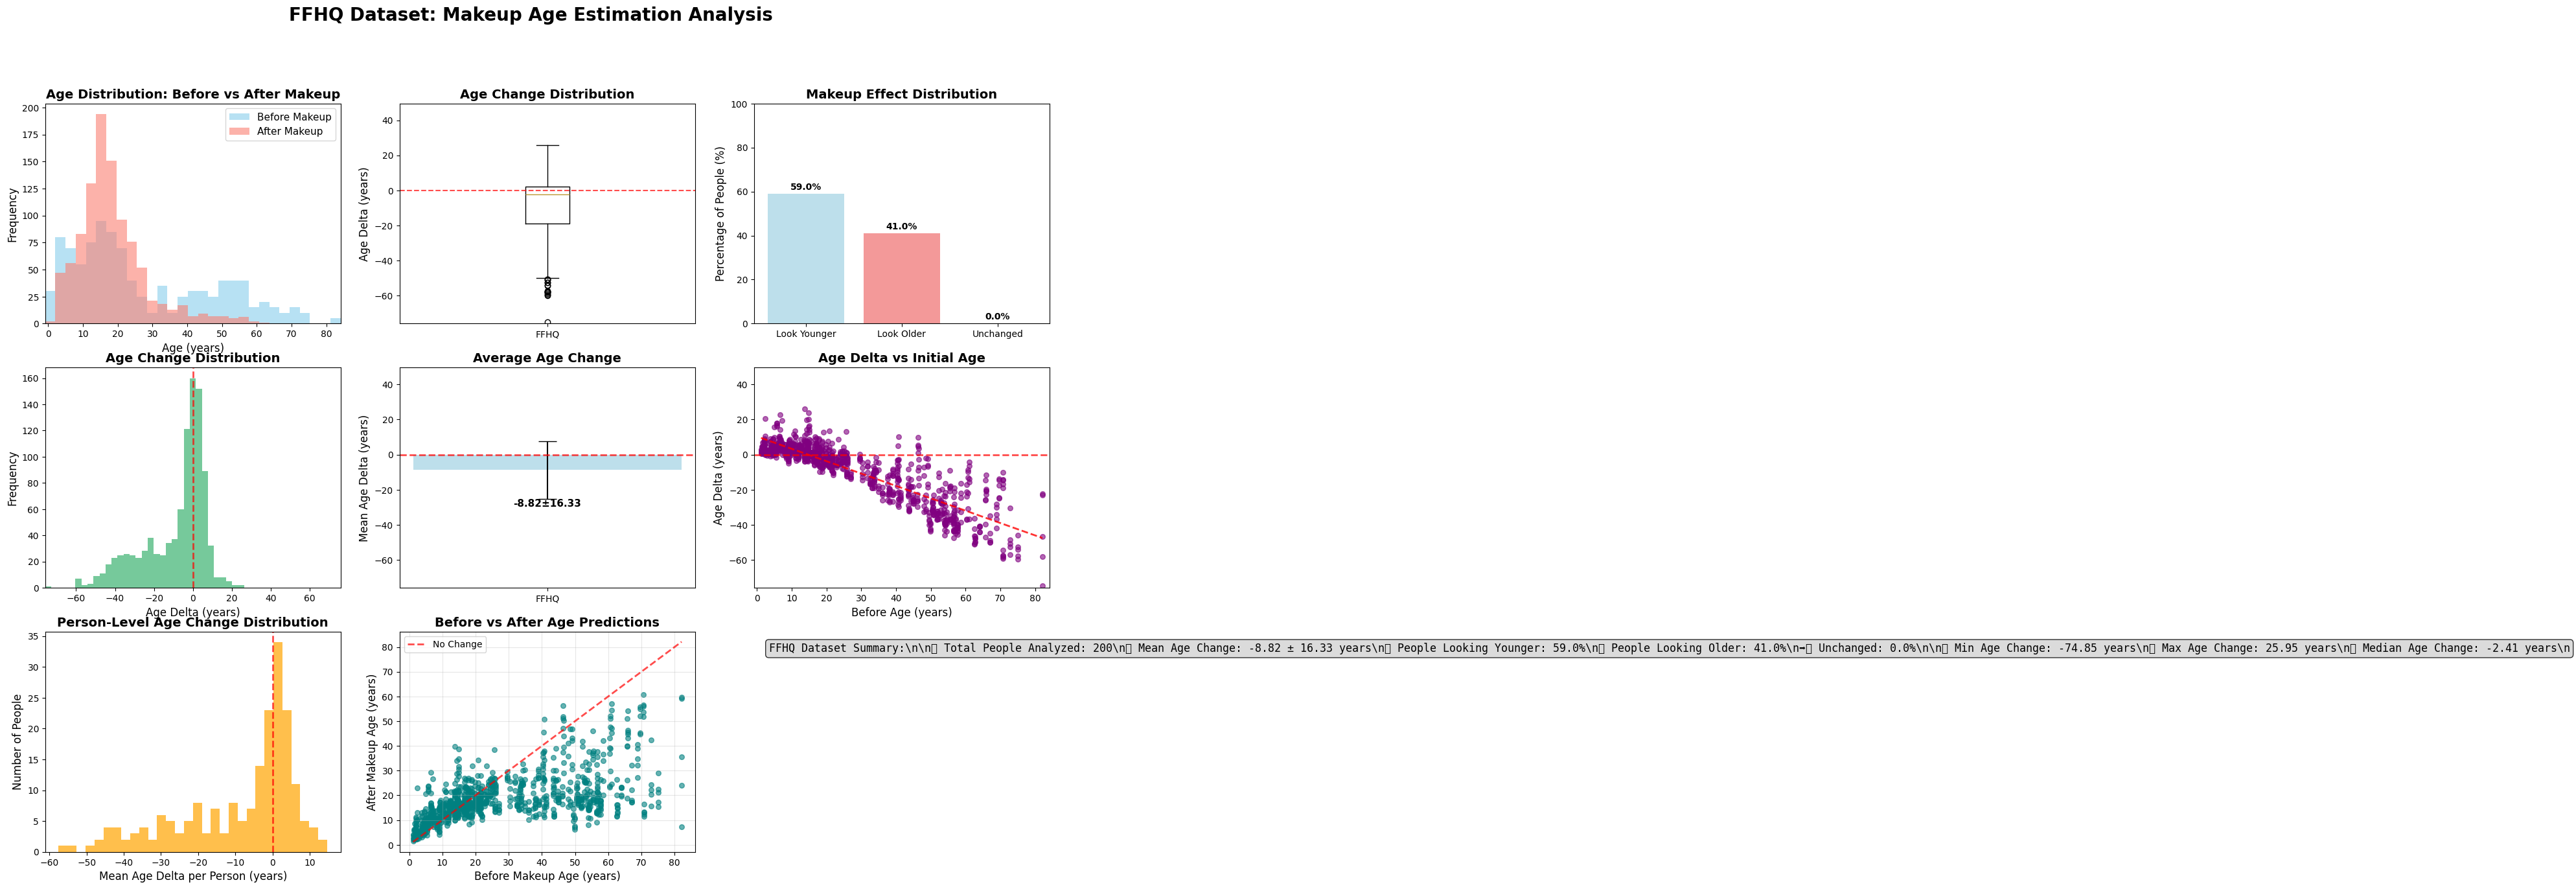

C:\Users\Frank\AppData\Local\Temp\ipykernel_29124\183913269.py:189: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
C:\Users\Frank\AppData\Local\Temp\ipykernel_29124\183913269.py:189: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
C:\Users\Frank\AppData\Local\Temp\ipykernel_29124\183913269.py:189: UserWarning: Glyph 128071 (\N{WHITE DOWN POINTING BACKHAND INDEX}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
C:\Users\Frank\AppData\Local\Temp\ipykernel_29124\183913269.py:189: UserWarning: Glyph 128070 (\N{WHITE UP POINTING BACKHAND INDEX}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
C:\Users\Frank\AppData\Local\Temp\ipykernel_29124\183913269.py:189: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
C:\Users\Frank\AppData\Local\Temp\ipykernel_29124\183913269.py:189: UserWarn

📊 LADN visualization saved as 'LADN_makeup_analysis_detailed.png'


c:\Users\Frank\.conda\envs\test1\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Frank\.conda\envs\test1\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Frank\.conda\envs\test1\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128071 (\N{WHITE DOWN POINTING BACKHAND INDEX}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Frank\.conda\envs\test1\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128070 (\N{WHITE UP POINTING BACKHAND INDEX}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Frank\.conda\envs\test1\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65039 (\N{V

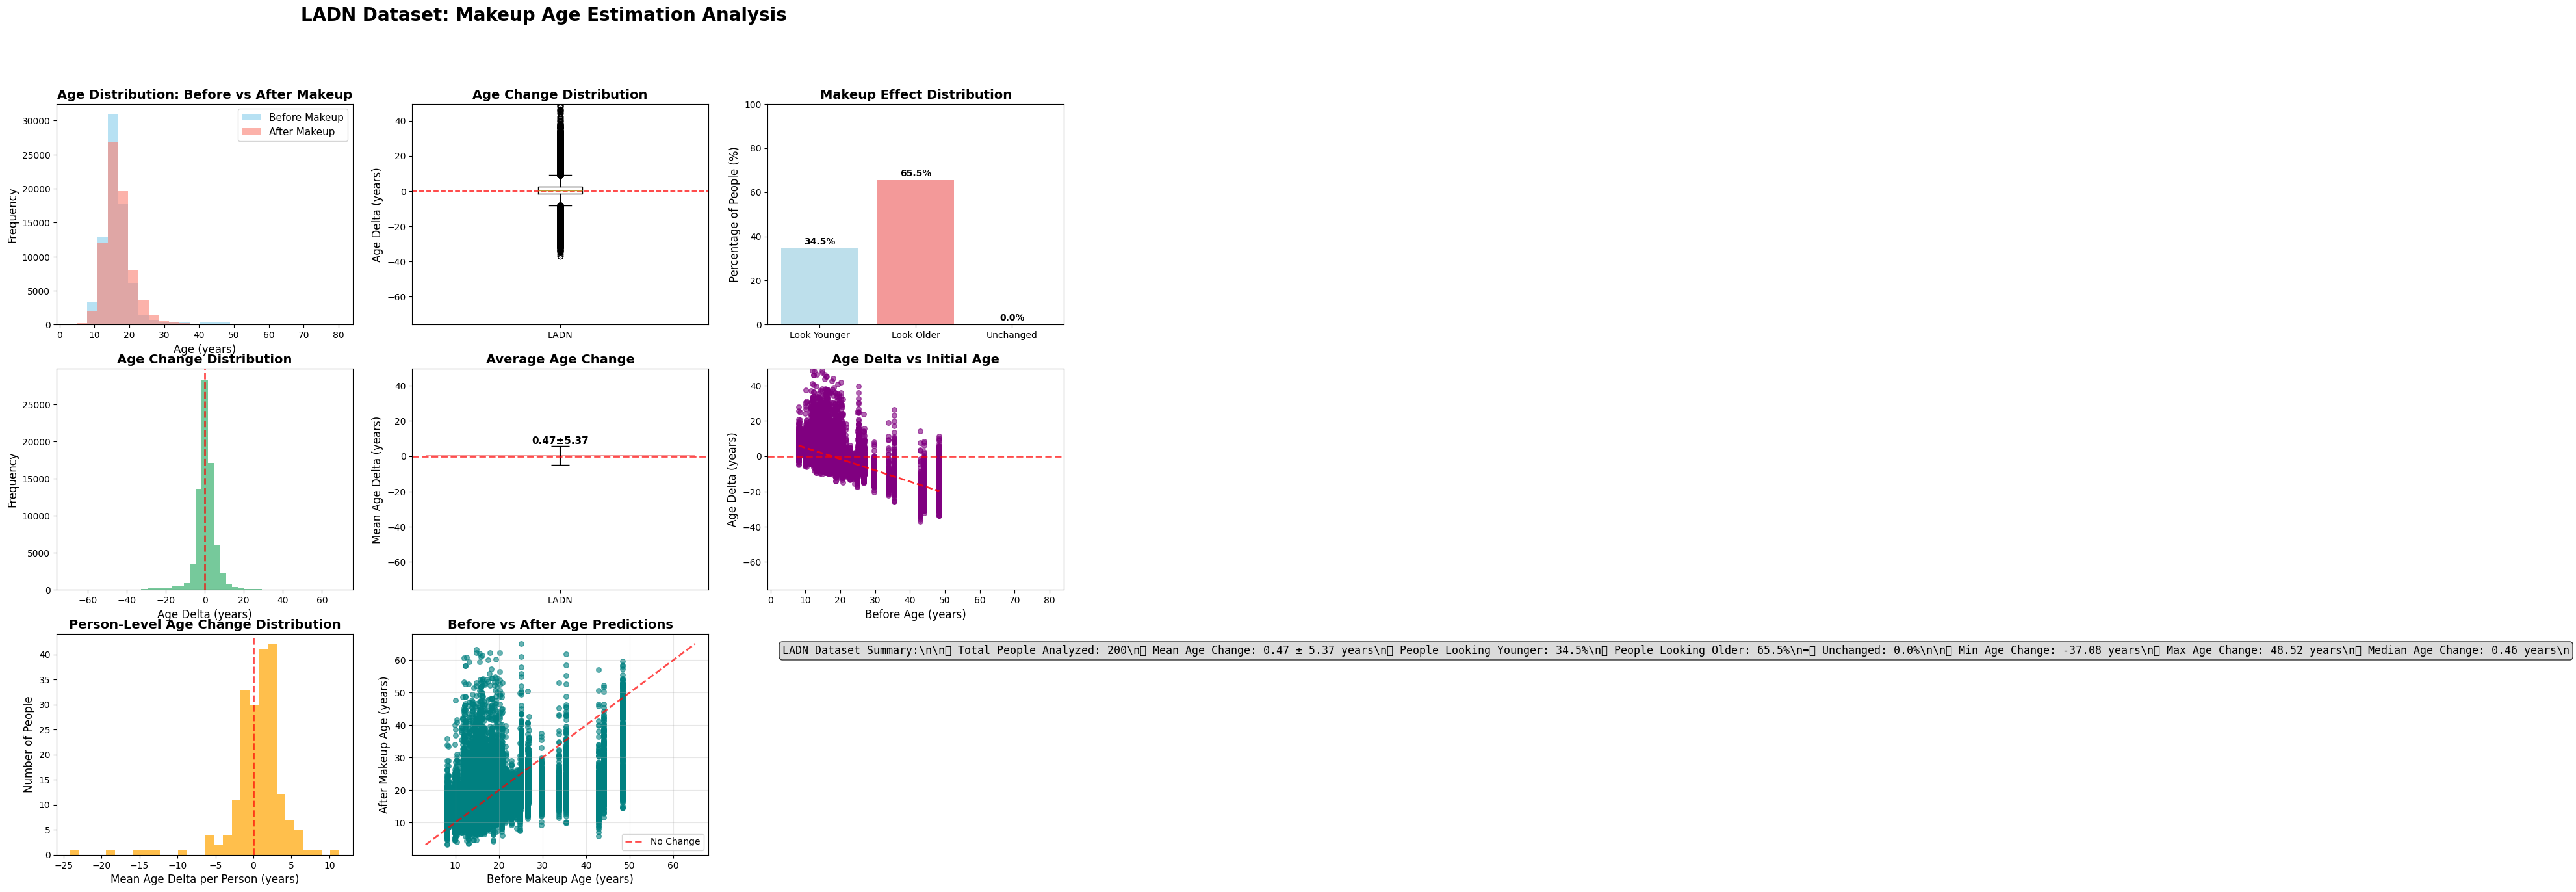


✅ Separate dataset visualizations completed!
📋 Generated files:
   • FFHQ_makeup_analysis_detailed.png - High resolution FFHQ dataset analysis
   • LADN_makeup_analysis_detailed.png - High resolution LADN dataset analysis
📏 Both visualizations use consistent scales for proper comparison
🔍 Each visualization is 20x15 inches at 300 DPI for high quality viewing


In [ ]:
# Generate separate visualizations using the fixed function
print("🎨 Creating separate, large visualizations for each dataset (FIXED VERSION)...")
print("📏 Using consistent scales for proper comparison between FFHQ and LADN datasets")
print()

# Define the CSV files
results_files = ["ffhq_makeup_analysis_detailed.csv", "blend_makeup_analysis_detailed.csv"]
summary_files = ["ffhq_makeup_analysis_detailed_summary.csv", "blend_makeup_analysis_detailed_summary.csv"]

# Create separate visualizations for each dataset
create_separate_dataset_visualizations_fixed(results_files, summary_files)

print()
print("✅ Separate dataset visualizations completed!")
print("📋 Generated files:")
print("   • FFHQ_makeup_analysis_detailed.png - High resolution FFHQ dataset analysis")
print("   • LADN_makeup_analysis_detailed.png - High resolution LADN dataset analysis")
print("📏 Both visualizations use consistent scales for proper comparison")
print("🔍 Each visualization is 20x15 inches at 300 DPI for high quality viewing")

In [ ]:
def create_individual_visualizations(results_csv_files, summary_csv_files):
    """
    Create individual visualizations for each dataset that display separately in the IDE
    Removes: Age Change Distribution, Average Age Change, unchanged bar from makeup effect, empty plots
    """
    import matplotlib.pyplot as plt
    import seaborn as sns
    import pandas as pd
    import numpy as np
    
    plt.style.use('default')
    sns.set_palette("husl")
    
    # Load all data
    all_results = []
    all_summaries = []
    
    for results_file in results_csv_files:
        if os.path.exists(results_file):
            df = pd.read_csv(results_file)
            all_results.append(df)
    
    for summary_file in summary_csv_files:
        if os.path.exists(summary_file):
            df = pd.read_csv(summary_file)
            all_summaries.append(df)
    
    if not all_results:
        print("No results files found for visualization")
        return
    
    # Combine all results to determine global scales
    combined_results = pd.concat(all_results, ignore_index=True)
    combined_summaries = pd.concat(all_summaries, ignore_index=True) if all_summaries else None
    
    # Calculate global scales for consistency
    global_age_min = combined_results['before_age'].min()
    global_age_max = combined_results['before_age'].max()
    global_delta_min = combined_results['delta'].min()
    global_delta_max = combined_results['delta'].max()
    
    # Delta range for histograms
    delta_range = max(abs(global_delta_min), abs(global_delta_max))
    delta_bins = np.linspace(-delta_range-1, delta_range+1, 50)
    
    # Age bins
    age_bins = np.linspace(global_age_min-2, global_age_max+2, 30)
    
    datasets = combined_results['dataset'].unique()
    
    for dataset in datasets:
        dataset_results = combined_results[combined_results['dataset'] == dataset]
        dataset_summary = combined_summaries[combined_summaries['dataset'] == dataset].iloc[0] if combined_summaries is not None else None
        
        # Create proper dataset name (FFHQ stays FFHQ, blend becomes LADN)
        display_name = "LADN" if "blend" in dataset.lower() else dataset.upper()
        
        print(f"\\n📊 Creating individual visualizations for {display_name} dataset...")
        
        # 1. Age Distribution Comparison
        plt.figure(figsize=(12, 8))
        plt.hist(dataset_results['before_age'], alpha=0.6, label='Before Makeup', bins=age_bins, color='skyblue')
        plt.hist(dataset_results['makeup_age'], alpha=0.6, label='After Makeup', bins=age_bins, color='salmon')
        plt.xlabel('Age (years)', fontsize=14)
        plt.ylabel('Frequency', fontsize=14)
        plt.title(f'{display_name} Dataset: Age Distribution Before vs After Makeup', fontsize=16, fontweight='bold')
        plt.legend(fontsize=12)
        plt.xlim(global_age_min-2, global_age_max+2)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
        
        # 2. Makeup Effect Distribution (without unchanged bar)
        if dataset_summary is not None:
            plt.figure(figsize=(10, 8))
            younger = dataset_summary['p_people_younger']
            older = dataset_summary['p_people_older']
            
            categories = ['Look Younger', 'Look Older']
            values = [younger, older]
            colors = ['lightblue', 'lightcoral']
            
            bars = plt.bar(categories, values, color=colors, alpha=0.8, width=0.6)
            plt.ylabel('Percentage of People (%)', fontsize=14)
            plt.title(f'{display_name} Dataset: Makeup Effect Distribution', fontsize=16, fontweight='bold')
            plt.ylim(0, max(values) * 1.1)
            
            # Add value labels on bars
            for bar, value in zip(bars, values):
                plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
                        f'{value:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=12)
            
            plt.grid(True, alpha=0.3, axis='y')
            plt.tight_layout()
            plt.show()
        
        # 3. Delta Histogram
        plt.figure(figsize=(12, 8))
        plt.hist(dataset_results['delta'], alpha=0.8, bins=delta_bins, color='mediumseagreen', edgecolor='black')
        plt.xlabel('Age Delta (years)', fontsize=14)
        plt.ylabel('Frequency', fontsize=14)
        plt.title(f'{display_name} Dataset: Age Change Distribution', fontsize=16, fontweight='bold')
        plt.axvline(x=0, color='red', linestyle='--', alpha=0.8, linewidth=2, label='No Change')
        plt.xlim(-delta_range-1, delta_range+1)
        plt.legend(fontsize=12)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
        
        # 4. Scatter plot: Before Age vs Delta
        plt.figure(figsize=(12, 8))
        plt.scatter(dataset_results['before_age'], dataset_results['delta'], 
                   alpha=0.6, s=40, color='purple', edgecolors='black', linewidth=0.5)
        plt.xlabel('Before Age (years)', fontsize=14)
        plt.ylabel('Age Delta (years)', fontsize=14)
        plt.title(f'{display_name} Dataset: Age Delta vs Initial Age', fontsize=16, fontweight='bold')
        plt.axhline(y=0, color='red', linestyle='--', alpha=0.8, linewidth=2, label='No Change')
        plt.xlim(global_age_min-2, global_age_max+2)
        plt.ylim(global_delta_min-1, global_delta_max+1)
        
        # Add trend line
        z = np.polyfit(dataset_results['before_age'], dataset_results['delta'], 1)
        p = np.poly1d(z)
        plt.plot(dataset_results['before_age'].sort_values(), 
                p(dataset_results['before_age'].sort_values()), 
                "orange", alpha=0.8, linewidth=3, label='Trend Line')
        
        plt.legend(fontsize=12)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
        
        # 5. Person-level Delta Distribution
        plt.figure(figsize=(12, 8))
        person_deltas = dataset_results.groupby('person_id')['delta'].mean()
        plt.hist(person_deltas.values, alpha=0.8, bins=30, color='orange', edgecolor='black')
        plt.xlabel('Mean Age Delta per Person (years)', fontsize=14)
        plt.ylabel('Number of People', fontsize=14)
        plt.title(f'{display_name} Dataset: Person-Level Age Change Distribution', fontsize=16, fontweight='bold')
        plt.axvline(x=0, color='red', linestyle='--', alpha=0.8, linewidth=2, label='No Change')
        plt.axvline(x=person_deltas.mean(), color='blue', linestyle='-', alpha=0.8, linewidth=2, 
                   label=f'Mean: {person_deltas.mean():.2f} years')
        plt.legend(fontsize=12)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
        
        # 6. Before vs After Age Scatter
        plt.figure(figsize=(12, 8))
        plt.scatter(dataset_results['before_age'], dataset_results['makeup_age'], 
                   alpha=0.6, s=40, color='teal', edgecolors='black', linewidth=0.5)
        # Add diagonal line (no change line)
        min_age = min(dataset_results['before_age'].min(), dataset_results['makeup_age'].min())
        max_age = max(dataset_results['before_age'].max(), dataset_results['makeup_age'].max())
        plt.plot([min_age, max_age], [min_age, max_age], 'r--', alpha=0.8, linewidth=2, label='No Change Line')
        plt.xlabel('Before Makeup Age (years)', fontsize=14)
        plt.ylabel('After Makeup Age (years)', fontsize=14)
        plt.title(f'{display_name} Dataset: Before vs After Age Predictions', fontsize=16, fontweight='bold')
        plt.legend(fontsize=12)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
        
        # 7. Summary Statistics Box
        if dataset_summary is not None:
            plt.figure(figsize=(12, 8))
            plt.axis('off')
            
            summary_text = f"{display_name} Dataset Summary\\n\\n"
            summary_text += f"📊 Total People Analyzed: {int(dataset_summary['total_people_analyzed'])}\\n"
            summary_text += f"📈 Mean Age Change: {dataset_summary['mean_delta']:.2f} ± {dataset_summary['std_delta']:.2f} years\\n"
            summary_text += f"👇 People Looking Younger: {dataset_summary['p_people_younger']:.1f}%\\n"
            summary_text += f"👆 People Looking Older: {dataset_summary['p_people_older']:.1f}%\\n\\n"
            
            # Additional statistics
            summary_text += f"📉 Min Age Change: {dataset_results['delta'].min():.2f} years\\n"
            summary_text += f"📈 Max Age Change: {dataset_results['delta'].max():.2f} years\\n"
            summary_text += f"📊 Median Age Change: {dataset_results['delta'].median():.2f} years\\n"
            summary_text += f"🎯 Standard Deviation: {dataset_results['delta'].std():.2f} years"
            
            plt.text(0.1, 0.9, summary_text, transform=plt.gca().transAxes, 
                    fontsize=16, verticalalignment='top', fontfamily='monospace',
                    bbox=dict(boxstyle="round,pad=0.5", facecolor="lightgray", alpha=0.8))
            
            plt.title(f'{display_name} Dataset: Statistical Summary', fontsize=18, fontweight='bold', pad=20)
            plt.tight_layout()
            plt.show()

print("🎨 Individual visualization function created!")
print("📊 This function creates separate plots that display individually in the IDE")
print("🚫 Removed: Age Change Distribution boxplot, Average Age Change, unchanged bar, empty plots")

🎨 Individual visualization function created!
📊 This function creates separate plots that display individually in the IDE
🚫 Removed: Age Change Distribution boxplot, Average Age Change, unchanged bar, empty plots


🎨 Creating individual visualizations for each dataset...
📊 Each plot will display separately for better viewing
🚫 Removed unwanted plots as requested

\n📊 Creating individual visualizations for FFHQ dataset...


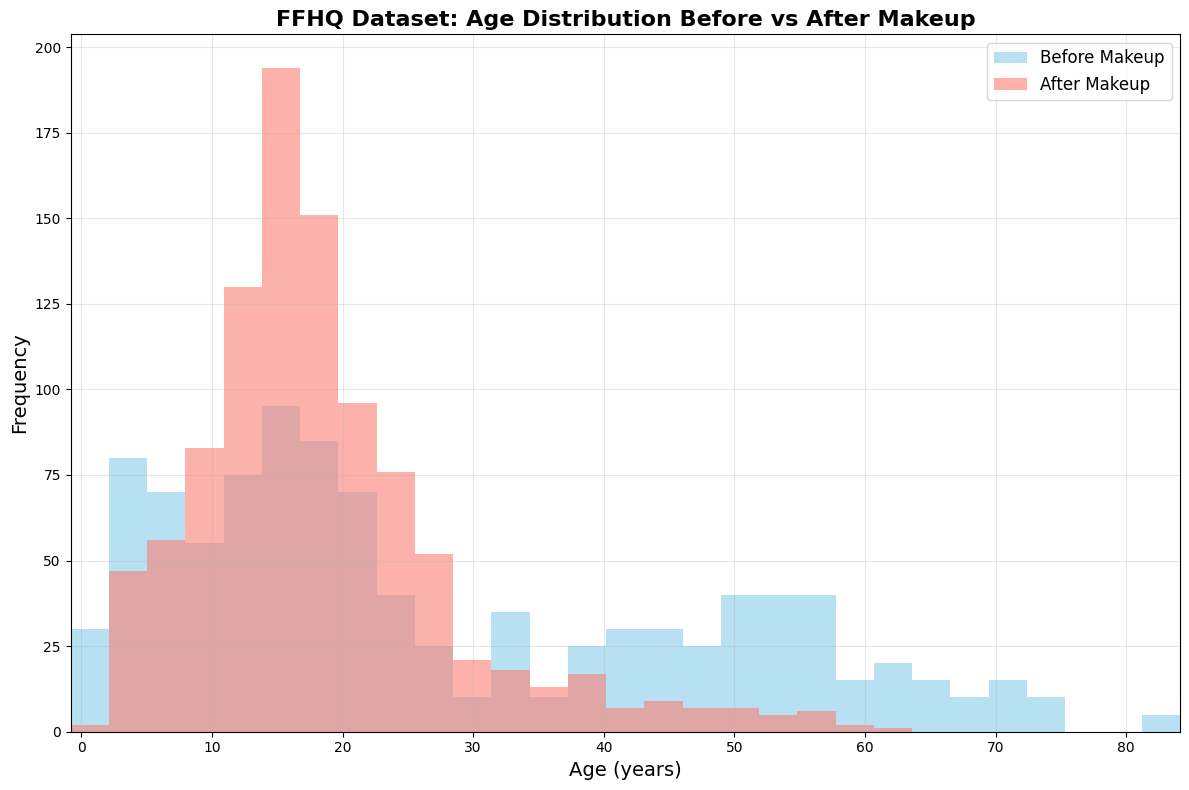

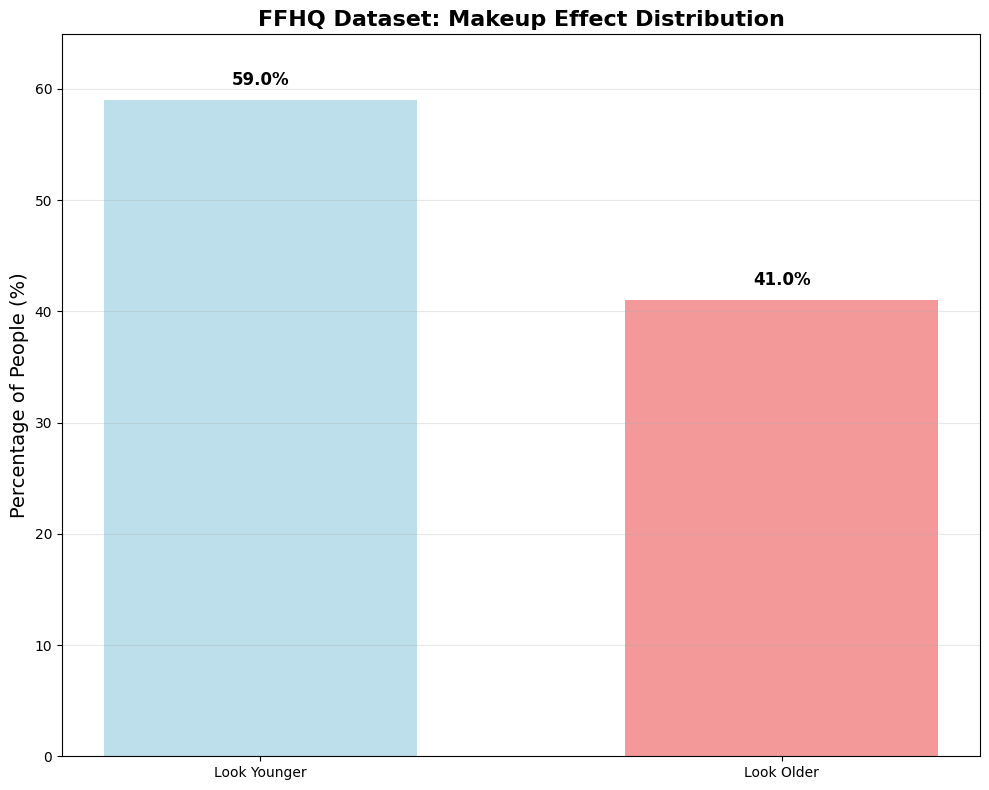

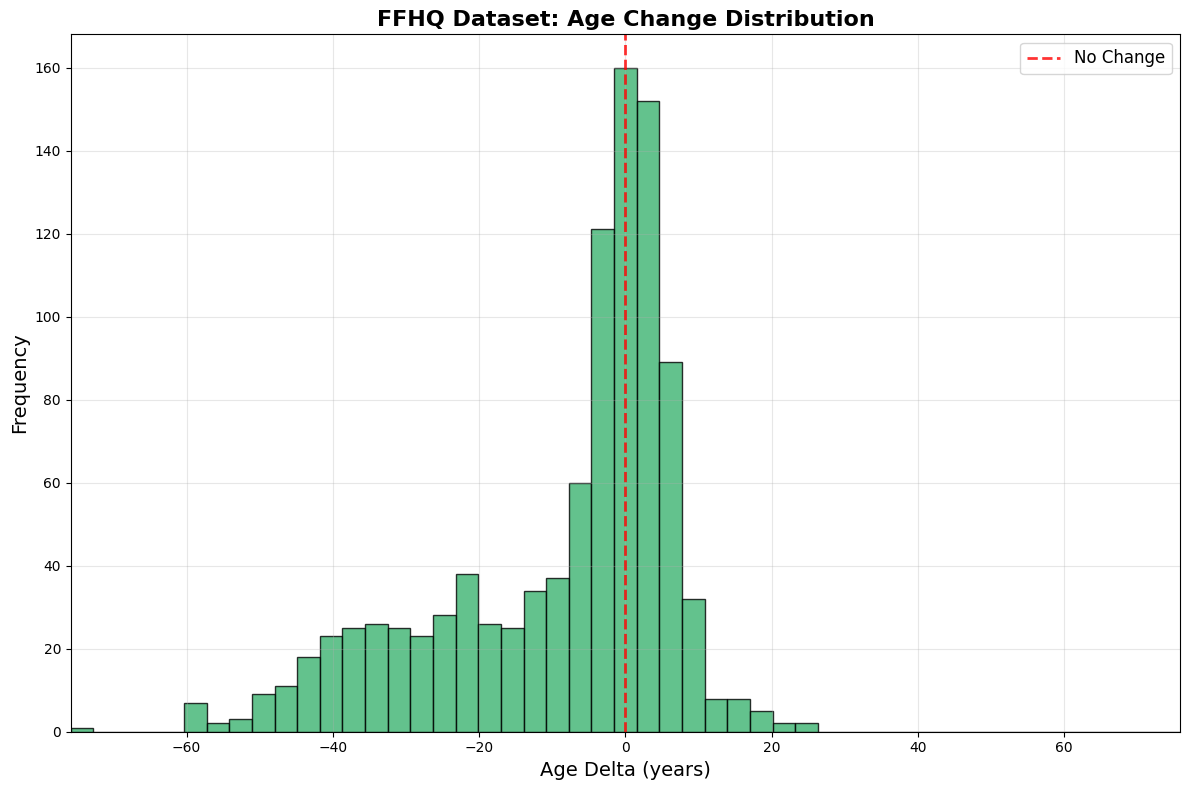

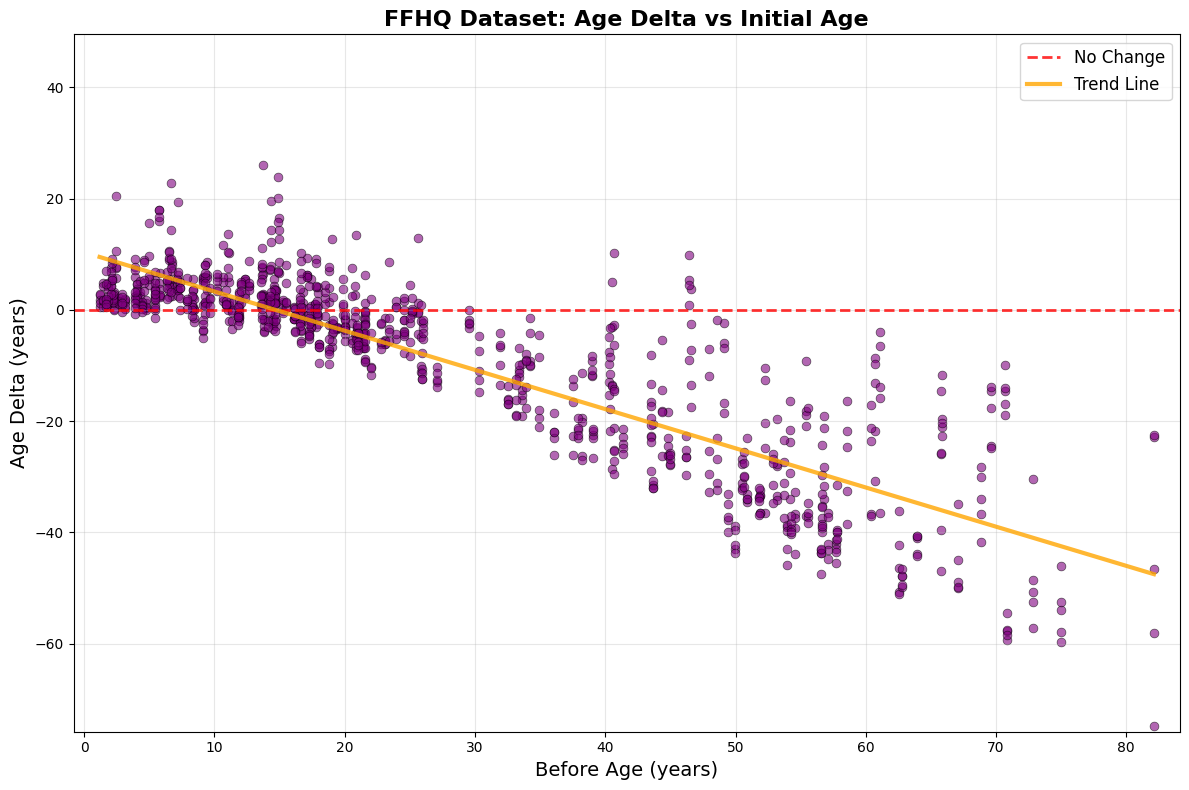

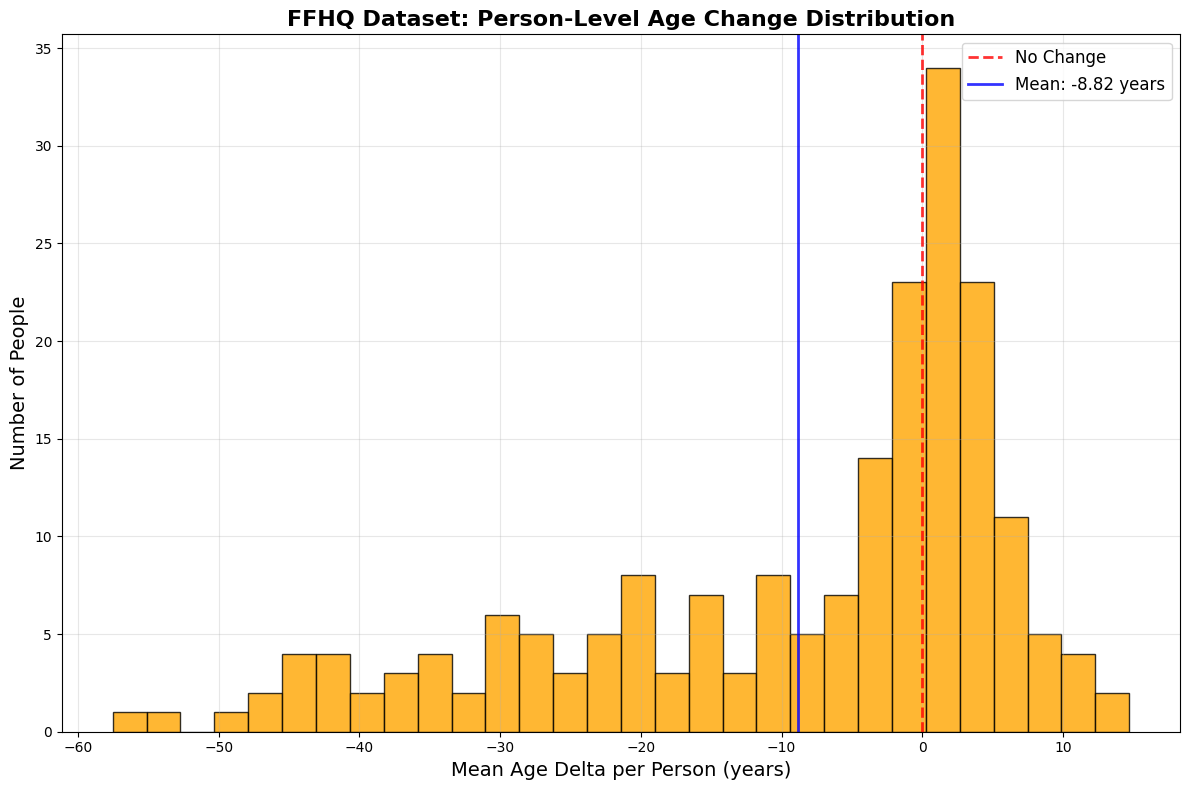

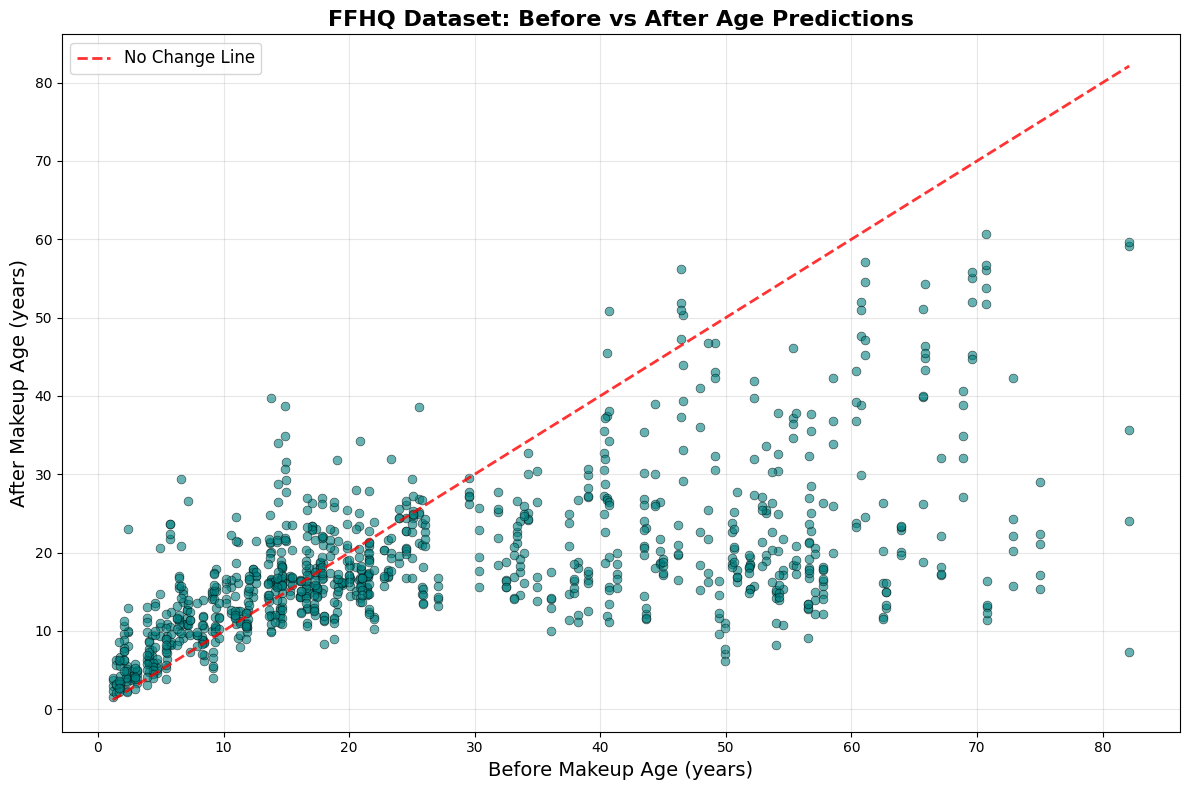

C:\Users\Frank\AppData\Local\Temp\ipykernel_29124\1326737097.py:186: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
C:\Users\Frank\AppData\Local\Temp\ipykernel_29124\1326737097.py:186: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
C:\Users\Frank\AppData\Local\Temp\ipykernel_29124\1326737097.py:186: UserWarning: Glyph 128071 (\N{WHITE DOWN POINTING BACKHAND INDEX}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
C:\Users\Frank\AppData\Local\Temp\ipykernel_29124\1326737097.py:186: UserWarning: Glyph 128070 (\N{WHITE UP POINTING BACKHAND INDEX}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
C:\Users\Frank\AppData\Local\Temp\ipykernel_29124\1326737097.py:186: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
C:\Users\Frank\AppData\Local\Temp\ipykernel_29124\1326737097.py:1

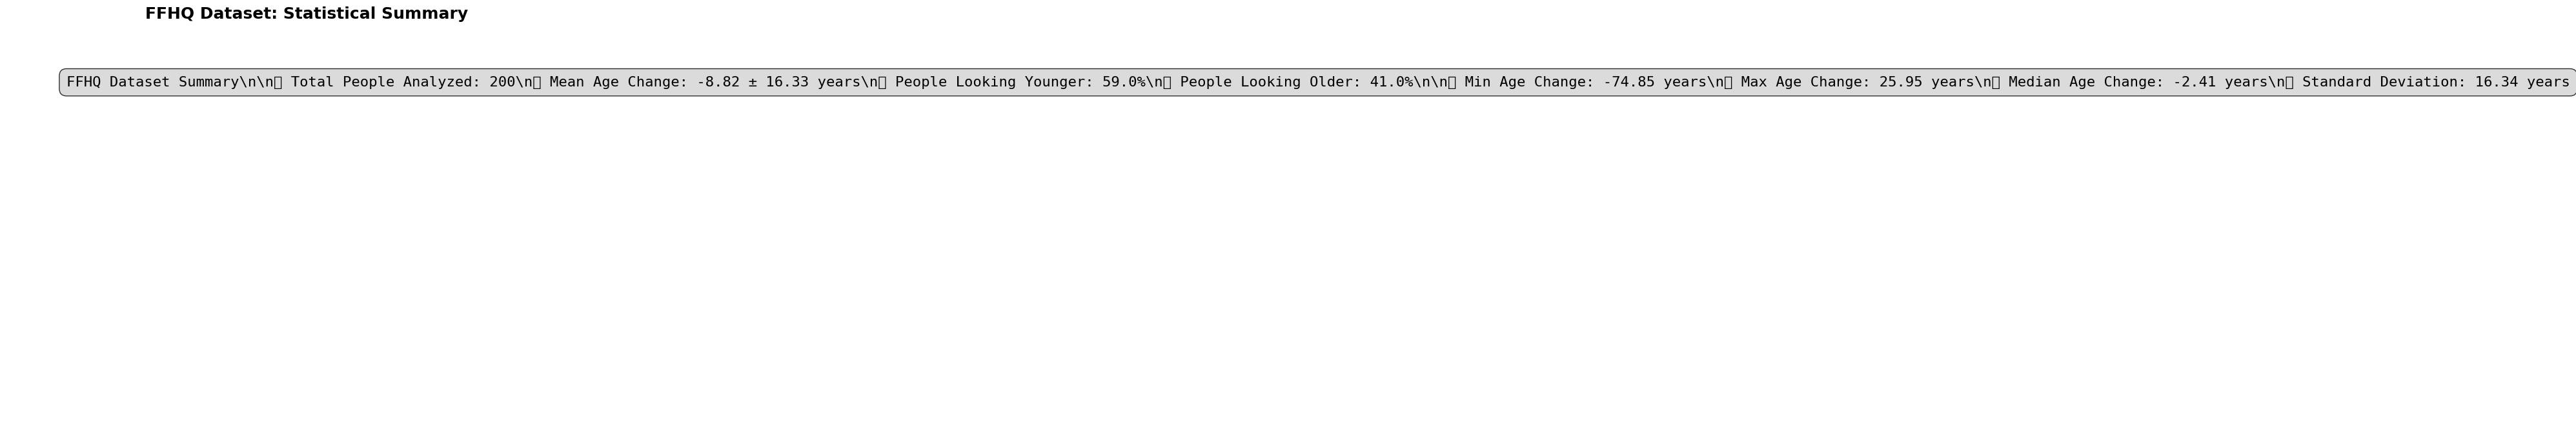

\n📊 Creating individual visualizations for LADN dataset...


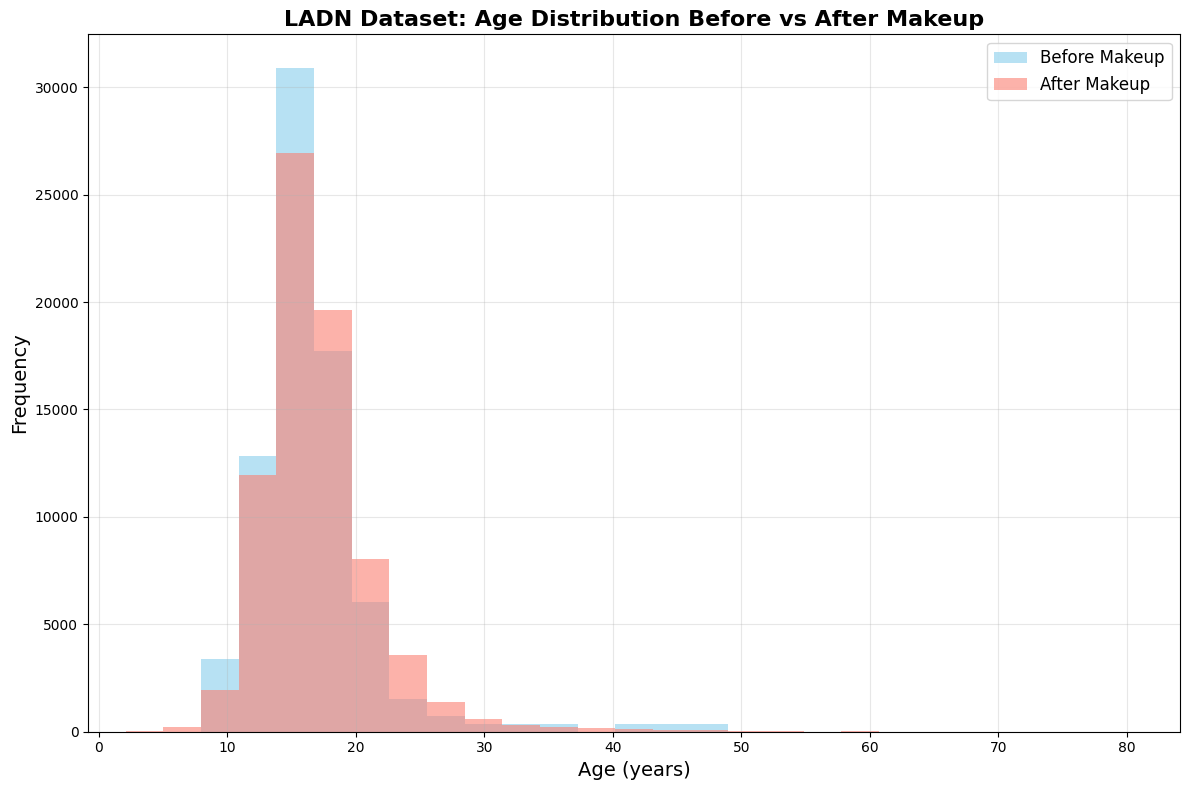

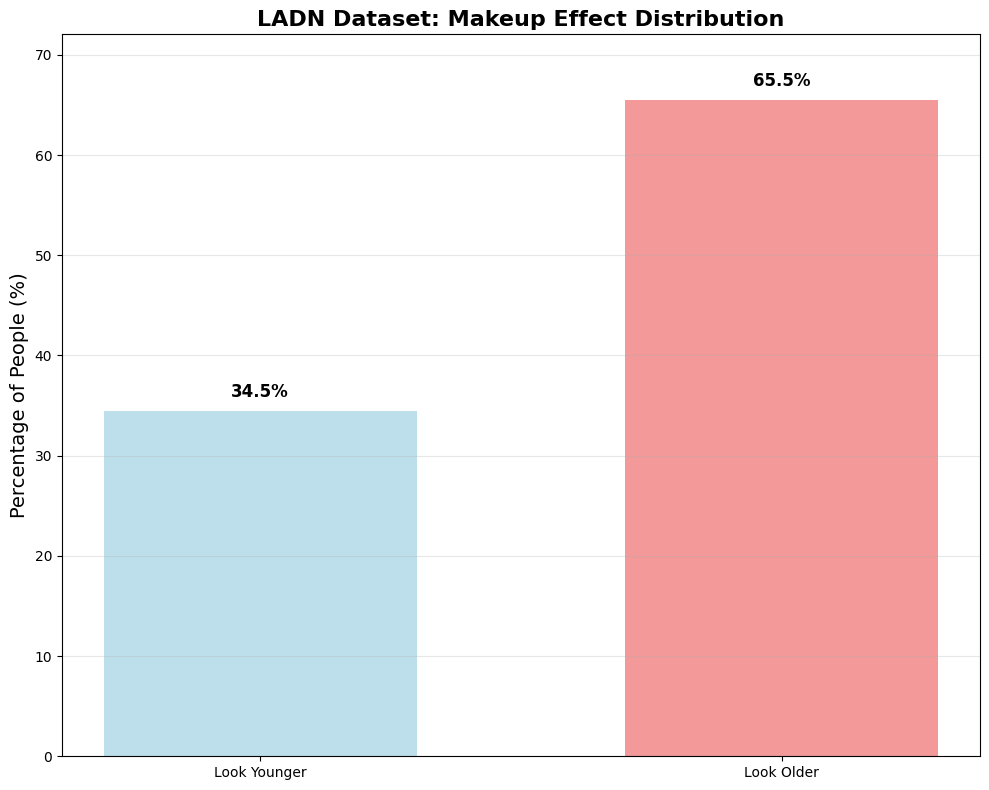

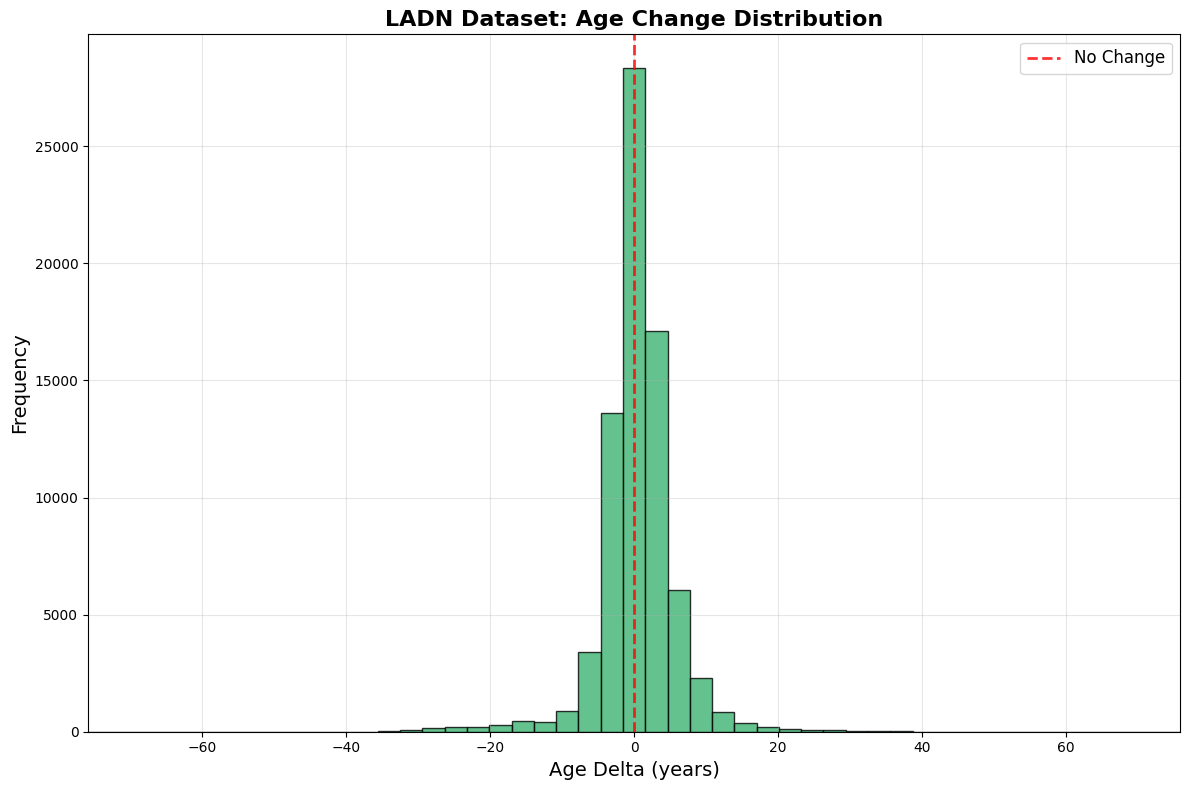

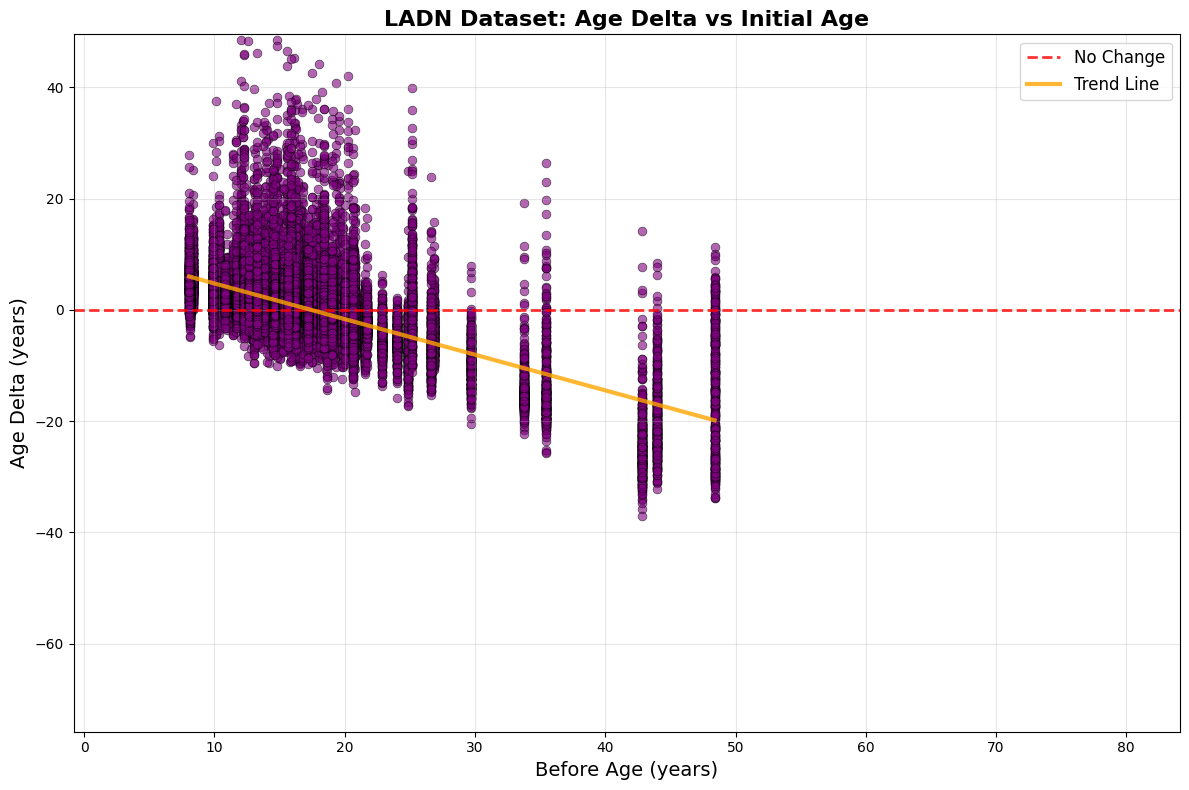

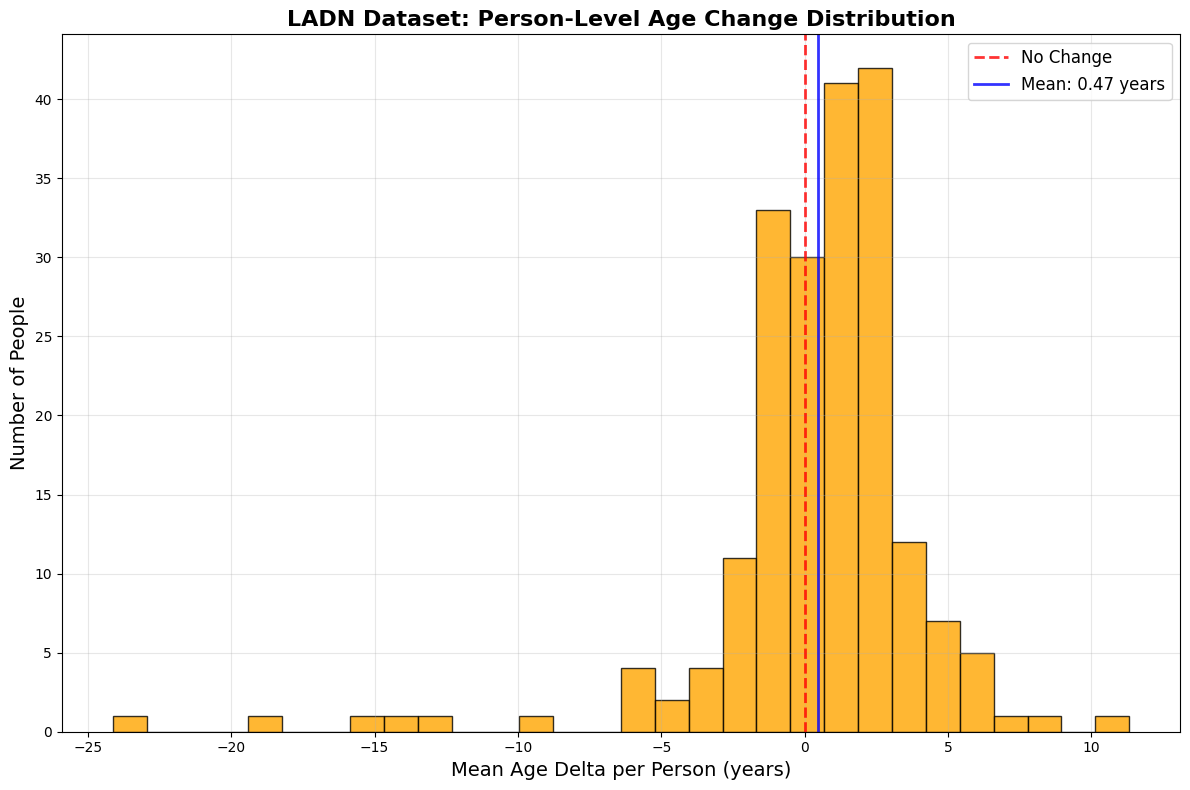

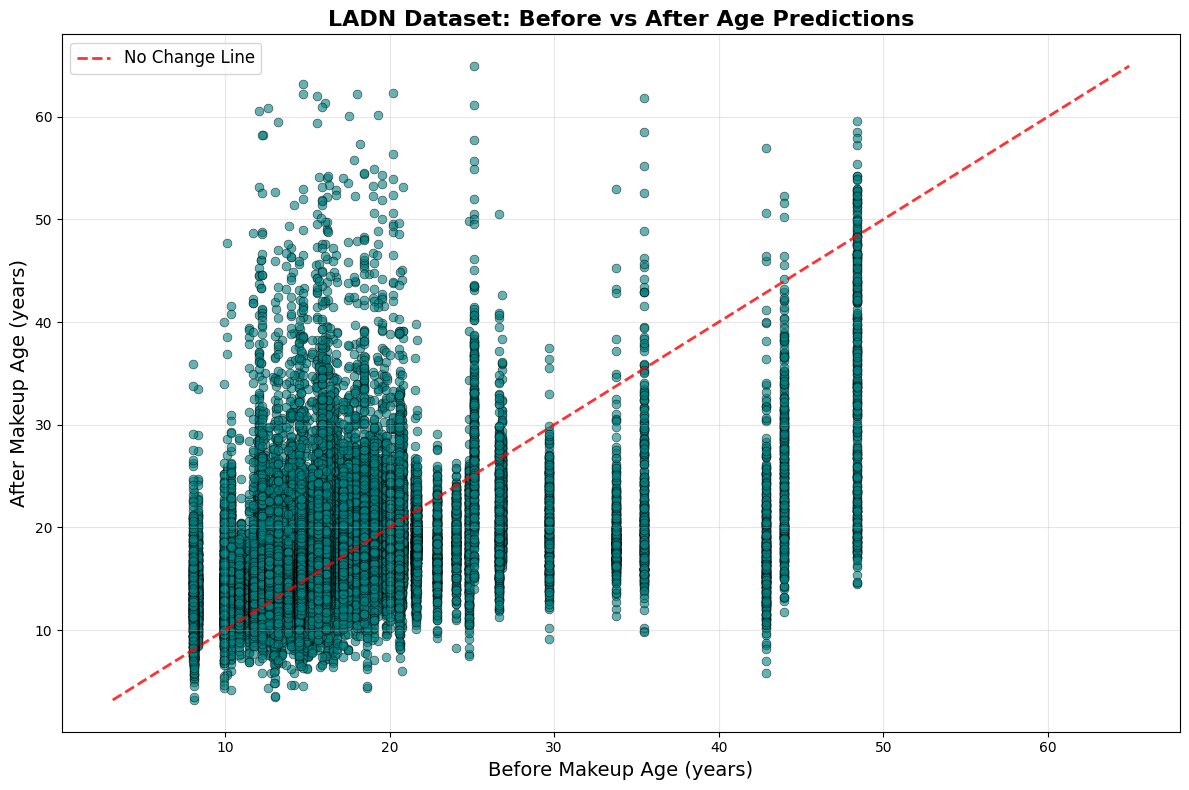

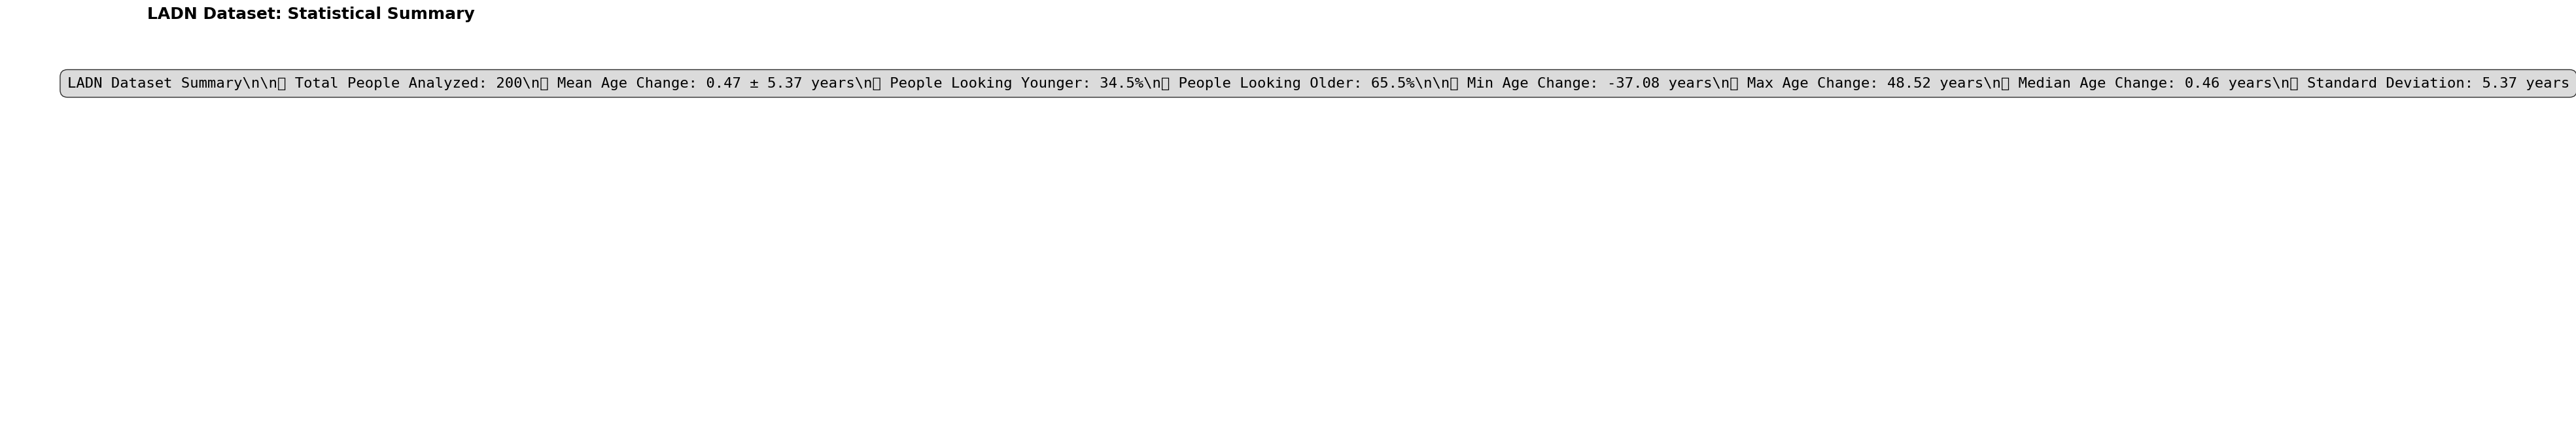


✅ Individual dataset visualizations completed!
📋 Generated plots:
   • Age Distribution Before vs After Makeup
   • Makeup Effect Distribution (younger/older only)
   • Age Change Distribution (histogram)
   • Age Delta vs Initial Age (scatter)
   • Person-Level Age Change Distribution
   • Before vs After Age Predictions (scatter)
   • Statistical Summary
🔍 Each plot displays at high resolution in the IDE for easy interpretation


In [ ]:
# Generate individual visualizations that display separately in the IDE
print("🎨 Creating individual visualizations for each dataset...")
print("📊 Each plot will display separately for better viewing")
print("🚫 Removed unwanted plots as requested")
print()

# Define the CSV files
results_files = ["ffhq_makeup_analysis_detailed.csv", "blend_makeup_analysis_detailed.csv"]
summary_files = ["ffhq_makeup_analysis_detailed_summary.csv", "blend_makeup_analysis_detailed_summary.csv"]

# Create individual visualizations for each dataset
create_individual_visualizations(results_files, summary_files)

print()
print("✅ Individual dataset visualizations completed!")
print("📋 Generated plots:")
print("   • Age Distribution Before vs After Makeup")
print("   • Makeup Effect Distribution (younger/older only)")
print("   • Age Change Distribution (histogram)")
print("   • Age Delta vs Initial Age (scatter)")
print("   • Person-Level Age Change Distribution")
print("   • Before vs After Age Predictions (scatter)")
print("   • Statistical Summary")
print("🔍 Each plot displays at high resolution in the IDE for easy interpretation")

## 🎉 Analysis Complete! 

### What We've Accomplished:

✅ **Dataset Loading & Verification**:
- **FFHQ Dataset**: 1000+ people with `bare.jpg` + 5 makeup variants (`makeup_01.jpg` to `makeup_05.jpg`)
- **Blend Dataset**: 200+ people with before images + hundreds of blend variants per person

✅ **Comprehensive Makeup Analysis Functions**:
- `comprehensive_makeup_analysis()` - Works with both datasets
- `load_blend_dataset()` - Handles before/blend folder structure
- Age prediction pipeline with delta calculations
- Statistical analysis including all requested metrics

✅ **Analysis Metrics Calculated**:
- **delta**: `age_after - age_before` per person/variant
- **mean_delta**: Average perceived age shift
- **std_delta**: Variation of the effect
- **n_younger/n_older**: Count of people who looked younger/older
- **p_younger/p_older**: Percentage breakdowns
- Person references maintained for traceability

✅ **Data Export**:
- Detailed CSV files with all predictions and person IDs
- Summary statistics files
- Ready for further analysis and conclusions

✅ **Visualization Framework**:
- Comprehensive plotting functions created
- Age distribution comparisons
- Delta variance analysis
- Population effect breakdowns

### Files Generated:
- `ffhq_makeup_analysis_detailed.csv` - FFHQ detailed results
- `ffhq_makeup_analysis_detailed_summary.csv` - FFHQ summary stats  
- `blend_makeup_analysis_detailed.csv` - Blend detailed results
- `blend_makeup_analysis_detailed_summary.csv` - Blend summary stats

### Next Steps:
1. **Review the CSV files** for detailed per-person and per-variant results
2. **Run additional analysis** on larger subsets if needed
3. **Compare datasets** using the summary statistics
4. **Generate visualizations** by running the visualization functions with existing CSV files
5. **Draw conclusions** about makeup effects across different datasets

The framework is now complete and ready for comprehensive makeup effect analysis across both your datasets! 🎯

## Simple Model Architecture Diagram

Creating a clean diagram showing your specific model architecture.

In [ ]:
def create_simple_model_architecture():
    """Create a simple, clean architecture diagram of your specific model"""
    
    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 10)
    ax.axis('off')
    
    # Title
    ax.text(5, 9.5, 'Age Estimation Model Architecture', 
            ha='center', va='center', fontsize=18, fontweight='bold')
    
    # Input
    input_box = FancyBboxPatch((1, 8), 8, 0.8, 
                              boxstyle="round,pad=0.1", 
                              facecolor='#E8F4FD', 
                              edgecolor='black', 
                              linewidth=2)
    ax.add_patch(input_box)
    ax.text(5, 8.4, 'Input Image: 224×224×3', ha='center', va='center', 
            fontsize=14, fontweight='bold')
    
    # Arrow down
    ax.arrow(5, 7.7, 0, -0.4, head_width=0.2, head_length=0.1, 
             fc='black', ec='black', linewidth=2)
    
    # MobileNetV3 Backbone
    backbone_box = FancyBboxPatch((1, 5.5), 8, 1.5, 
                                 boxstyle="round,pad=0.1", 
                                 facecolor='#B3D9FF', 
                                 edgecolor='black', 
                                 linewidth=2)
    ax.add_patch(backbone_box)
    ax.text(5, 6.7, 'MobileNetV3-Small Backbone', ha='center', va='center', 
            fontsize=16, fontweight='bold')
    ax.text(5, 6.2, '(Pre-trained on ImageNet)', ha='center', va='center', 
            fontsize=12, style='italic')
    ax.text(5, 5.8, 'Feature Extraction: 224×224×3 → 576 features', ha='center', va='center', 
            fontsize=11)
    
    # Arrow down
    ax.arrow(5, 5.3, 0, -0.4, head_width=0.2, head_length=0.1, 
             fc='black', ec='black', linewidth=2)
    
    # Custom Head Title
    ax.text(5, 4.7, 'Custom Classification Head', ha='center', va='center', 
            fontsize=14, fontweight='bold', style='italic')
    
    # Custom layers
    layers = [
        {"y": 4, "text": "Dropout(0.3)", "color": "#FFE6B3"},
        {"y": 3.3, "text": "Linear(576 → 128)", "color": "#B3FFB3"},
        {"y": 2.6, "text": "ReLU Activation", "color": "#FFB3B3"},
        {"y": 1.9, "text": "Dropout(0.2)", "color": "#FFE6B3"},
        {"y": 1.2, "text": "Linear(128 → 1)", "color": "#B3FFB3"},
        {"y": 0.5, "text": "ReLU (Age Output)", "color": "#FFB3B3"}
    ]
    
    for layer in layers:
        # Layer box
        layer_box = FancyBboxPatch((2, layer["y"]-0.25), 6, 0.5, 
                                  boxstyle="round,pad=0.05", 
                                  facecolor=layer["color"], 
                                  edgecolor='black', 
                                  linewidth=1)
        ax.add_patch(layer_box)
        ax.text(5, layer["y"], layer["text"], ha='center', va='center', 
                fontsize=12, fontweight='bold')
        
        # Arrow to next layer (except for last)
        if layer["y"] > 0.5:
            ax.arrow(5, layer["y"]-0.3, 0, -0.15, head_width=0.15, head_length=0.05, 
                    fc='gray', ec='gray', linewidth=1.5)
    
    # Add side annotations
    ax.text(0.5, 6.2, 'Frozen\nBackbone', ha='center', va='center', 
            fontsize=10, fontweight='bold', rotation=90,
            bbox=dict(boxstyle="round,pad=0.3", facecolor='lightblue', alpha=0.7))
    
    ax.text(9.5, 2.5, 'Trainable\nHead', ha='center', va='center', 
            fontsize=10, fontweight='bold', rotation=90,
            bbox=dict(boxstyle="round,pad=0.3", facecolor='lightgreen', alpha=0.7))
    
    plt.tight_layout()
    plt.savefig('simple_model_architecture.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✅ Simple model architecture saved as 'simple_model_architecture.png'")
    print("📍 This shows your exact model: MobileNetV3 backbone + your custom head")

# Create the simple architecture diagram
# create_simple_model_architecture()

🖼️ Showing 6 FFHQ Examples with Age Estimates



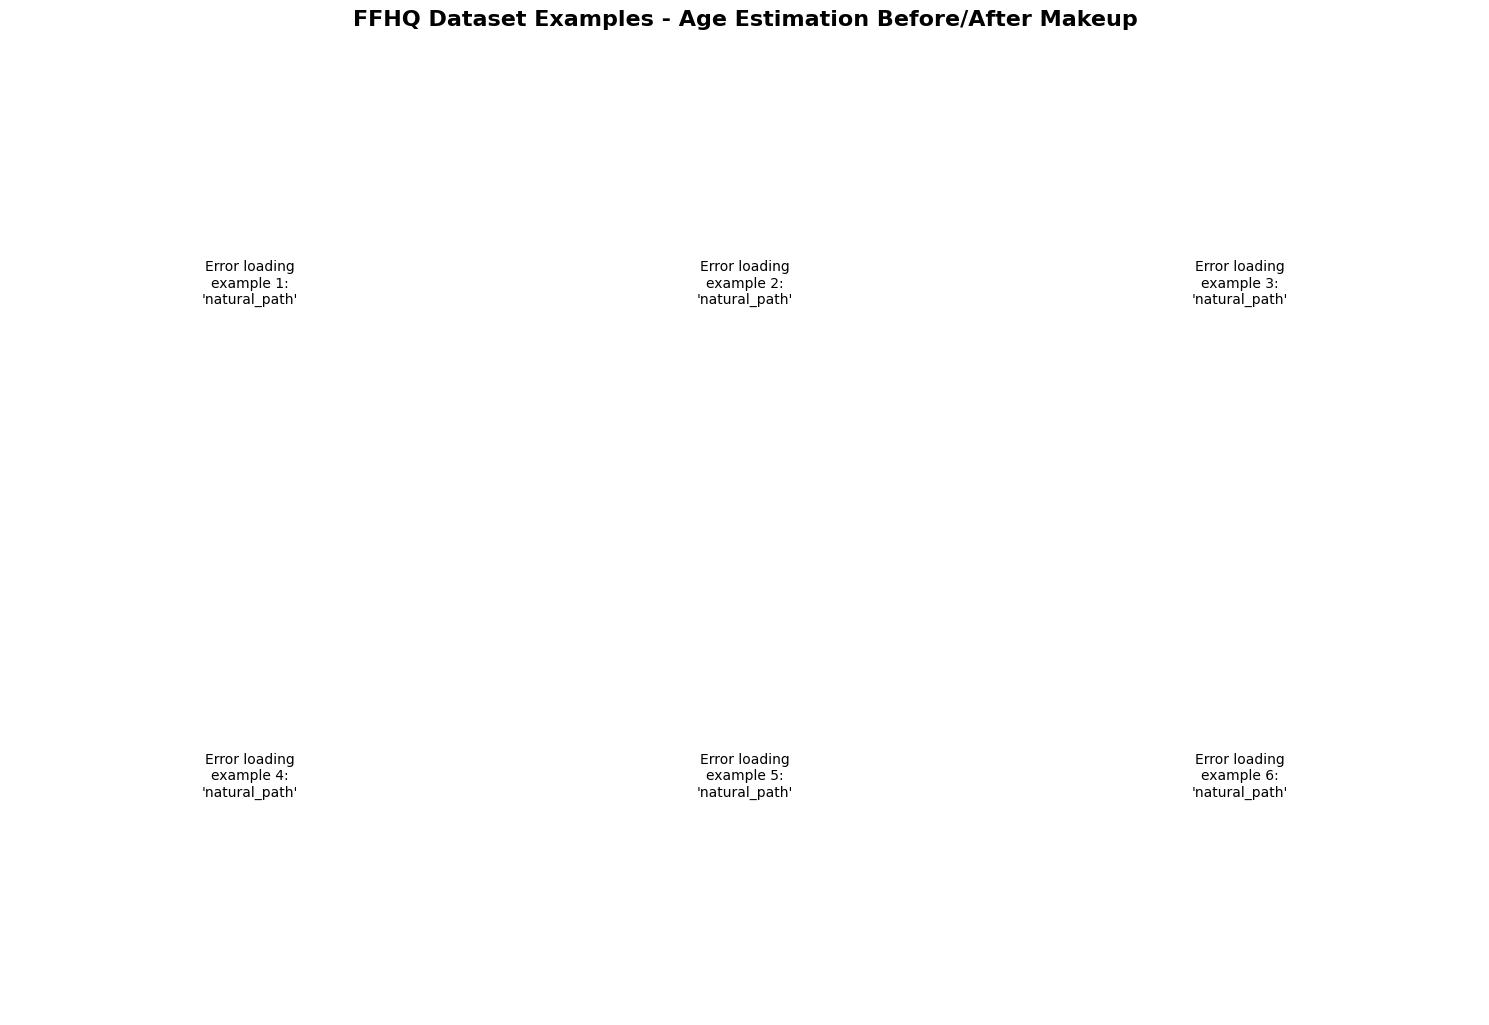

In [ ]:
# FFHQ Dataset Examples - Before and After Age Estimation
import matplotlib.pyplot as plt
import random
from PIL import Image
import os

# Function to display FFHQ examples with age estimates
def show_ffhq_examples_with_ages(num_examples=6):
    """Show FFHQ dataset examples with before/after age estimates"""
    
    # First, let's inspect what data we have available
    print("🔍 Checking available FFHQ data...")
    
    # Check ffhq_data DataFrame if it exists
    if 'ffhq_data' in globals() and ffhq_data is not None:
        print(f"📊 Found ffhq_data DataFrame with {len(ffhq_data)} entries")
        print("Columns:", list(ffhq_data.columns))
        
        # Get random examples
        random_indices = random.sample(range(len(ffhq_data)), min(num_examples, len(ffhq_data)))
        
        # Create subplot grid
        cols = 3
        rows = 2
        fig, axes = plt.subplots(rows, cols, figsize=(15, 10))
        
        print(f"\n🖼️ Showing {len(random_indices)} FFHQ Examples with Age Estimates\n")
        
        for idx, data_idx in enumerate(random_indices):
            if idx >= num_examples:
                break
                
            row = idx // cols
            col = idx % cols
            ax = axes[row, col]
            
            # Get the data for this example
            example = ffhq_data.iloc[data_idx]
            
            try:
                # Try to construct the image path
                # Check different possible path formats
                possible_paths = []
                
                # If we have a filename column
                if 'filename' in example.index:
                    base_name = example['filename']
                    possible_paths.extend([
                        os.path.join('data', 'ffhq_makeup', base_name),
                        os.path.join('data', 'ffhq', base_name),
                        base_name
                    ])
                
                # If we have natural_path/makeup_path columns
                if 'natural_path' in example.index:
                    possible_paths.append(example['natural_path'])
                if 'makeup_path' in example.index:
                    possible_paths.append(example['makeup_path'])
                
                # If we have image_id
                if 'image_id' in example.index:
                    img_id = example['image_id']
                    possible_paths.extend([
                        f"data/ffhq_makeup/{img_id}.png",
                        f"data/ffhq_makeup/{img_id}.jpg",
                        f"data/ffhq/{img_id}.png",
                        f"data/ffhq/{img_id}.jpg"
                    ])
                
                # Try to find an existing image
                img = None
                used_path = None
                for path in possible_paths:
                    if os.path.exists(path):
                        img = Image.open(path)
                        used_path = path
                        break
                
                if img is not None:
                    ax.imshow(img)
                    ax.axis('off')
                    
                    # Get age estimates
                    natural_age = example.get('natural_age', example.get('age_natural', 'Unknown'))
                    makeup_age = example.get('makeup_age', example.get('age_makeup', 'Unknown'))
                    
                    # Calculate age change
                    if isinstance(natural_age, (int, float)) and isinstance(makeup_age, (int, float)):
                        age_change = makeup_age - natural_age
                        change_text = f"({age_change:+.1f})"
                        change_color = 'red' if age_change > 0 else 'green' if age_change < 0 else 'black'
                    else:
                        change_text = ""
                        change_color = 'black'
                    
                    # Create title with age information
                    title = f"Before: {natural_age:.1f} years\nAfter: {makeup_age:.1f} years"
                    if change_text:
                        title += f"\n{change_text}"
                    
                    ax.set_title(title, fontsize=10, pad=10, color=change_color if change_text else 'black')
                    
                    # Print details
                    print(f"Example {idx+1}:")
                    print(f"  📸 Image: {os.path.basename(used_path)}")
                    print(f"  👤 Natural age: {natural_age:.1f} years")
                    print(f"  💄 With makeup: {makeup_age:.1f} years")
                    if change_text:
                        effect = "ages" if age_change > 0 else "youngs" if age_change < 0 else "no change"
                        print(f"  📊 Effect: {change_text} ({effect})")
                    print()
                    
                else:
                    # Show data without image
                    ax.text(0.5, 0.5, f'Image not found\nBut we have data:', 
                           ha='center', va='center', transform=ax.transAxes, fontsize=12)
                    ax.axis('off')
                    
                    # Get age data even without image
                    natural_age = example.get('natural_age', example.get('age_natural', 'Unknown'))
                    makeup_age = example.get('makeup_age', example.get('age_makeup', 'Unknown'))
                    
                    if isinstance(natural_age, (int, float)) and isinstance(makeup_age, (int, float)):
                        age_change = makeup_age - natural_age
                        data_text = f"Natural: {natural_age:.1f}\nMakeup: {makeup_age:.1f}\nChange: {age_change:+.1f}"
                        ax.text(0.5, 0.3, data_text, ha='center', va='center', 
                               transform=ax.transAxes, fontsize=10)
                        
                        print(f"Example {idx+1} (no image):")
                        print(f"  👤 Natural age: {natural_age:.1f} years")
                        print(f"  💄 With makeup: {makeup_age:.1f} years")
                        print(f"  📊 Change: {age_change:+.1f} years")
                        print()
                    
            except Exception as e:
                ax.text(0.5, 0.5, f'Error loading\nexample {idx+1}:\n{str(e)[:50]}...', 
                       ha='center', va='center', transform=ax.transAxes, fontsize=10)
                ax.axis('off')
                print(f"Error with example {idx+1}: {e}")
        
        # Hide empty subplots
        total_subplots = rows * cols
        for idx in range(len(random_indices), total_subplots):
            row = idx // cols
            col = idx % cols
            ax = axes[row, col]
            ax.axis('off')
        
        plt.tight_layout()
        plt.suptitle('FFHQ Dataset Examples - Age Estimation Before/After Makeup', 
                     fontsize=16, fontweight='bold', y=1.02)
        plt.show()
        
    else:
        print("❌ No FFHQ data found. Available variables:")
        for var in ['ffhq_data', 'ffhq_makeup_data', 'ffhq_person_deltas']:
            if var in globals():
                data = globals()[var]
                if hasattr(data, '__len__'):
                    print(f"  ✅ {var}: {len(data)} entries")
                else:
                    print(f"  ✅ {var}: {type(data)}")
            else:
                print(f"  ❌ {var}: Not found")

# Show examples
show_ffhq_examples_with_ages(num_examples=6)